# Итоговый проект первого года обучения

## Агенство недвижимости

### 1. Постановка задачи

Поводом к работе явилось обращение представителя крупного агентства недвижимости со следующей проблемой:

"Мои риелторы тратят катастрофически много времени на сортировку объявлений и поиск выгодных предложений. Поэтому их скорость реакции, да и, сказать по правде, качество анализа не дотягивают до уровня конкурентов. Это сказывается на наших финансовых показателях. Ваша задача — разработать модель, которая позволила бы обойти конкурентов по скорости и качеству совершения сделок"

### 2. Сбор и анализ данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from scipy import stats
from sklearn.model_selection import GridSearchCV
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn import feature_selection
from sklearn import metrics
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
import optuna
from xgboost import XGBClassifier
from catboost import CatBoostRegressor

C:\Users\Анечка\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.1 Посмотрим на выгруженные данные

Описание данных:
- 'status' — статус продажи;
- 'private pool' и 'PrivatePool' — наличие собственного бассейна;
- 'propertyType' — тип объекта недвижимости;
- 'street' — адрес объекта;
- 'baths' — количество ванных комнат;
- 'homeFacts' — сведения о строительстве объекта (содержит несколько типов сведений, влияющих на оценку объекта);
- 'fireplace' — наличие камина;
- 'city' — город;
- 'schools' — сведения о школах в районе;
- 'sqft' — площадь в футах;
- 'zipcode' — почтовый индекс;
- 'beds' — количество спален;
- 'state' — штат;
- 'stories' — количество этажей;
- 'mls-id' и 'MlsId' — идентификатор MLS (Multiple Listing Service, система мультилистинга);
- target' — цена объекта недвижимости (целевой признак, который необходимо спрогнозировать).

In [318]:
data = pd.read_csv('data\data.csv')
display(data.head(10))
data.info()

,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"
3,for sale,NaN,single-family home,4311 Livingston Ave,8 Baths,"{'atAGlanceFacts': [{'factValue': '2006', 'fac...",yes,Dallas,"[{'rating': ['9/10', '9/10', '10/10', '9/10'],...","6,457 sqft",75205,5 Beds,TX,3.0,NaN,NaN,14191809,"$2,395,000"
4,for sale,NaN,lot/land,1524 Kiscoe St,NaN,"{'atAGlanceFacts': [{'factValue': '', 'factLab...",NaN,Palm Bay,"[{'rating': ['4/10', '5/10', '5/10'], 'data': ...",NaN,32908,NaN,FL,NaN,NaN,NaN,861745,"$5,000"
5,for sale,NaN,townhouse,1624 S Newkirk St,NaN,"{'atAGlanceFacts': [{'factValue': '1920', 'fac...",NaN,Philadelphia,"[{'rating': [], 'data': {'Distance': [], 'Grad...",897 sqft,19145,2 Beds,PA,2.0,NaN,NaN,PAPH847006,"$209,000"
6,Active,NaN,Florida,552 Casanova Ct,NaN,"{'atAGlanceFacts': [{'factValue': '2006', 'fac...",NaN,POINCIANA,"[{'rating': ['3', '3', '1', 'NR'], 'data': {'D...","1,507",34759,NaN,FL,One,NaN,NaN,S5026943,"181,500"
7,Active,NaN,NaN,6094 Mingle Dr,NaN,"{'atAGlanceFacts': [{'factValue': '1976', 'fac...",NaN,Memphis,"[{'rating': ['4', '2', '2'], 'data': {'Distanc...",NaN,38115,NaN,TN,NaN,NaN,NaN,10063506,"68,000"
8,Active,NaN,Single Family Home,11182 Owl Ave,2,"{'atAGlanceFacts': [{'factValue': '1970', 'fac...",NaN,Mason City,"[{'rating': ['2', '2', '4', '7', '4', 'NR'], '...",3588,50401,3,IA,NaN,NaN,NaN,190988,"$244,900"
9,NaN,NaN,Single Family,8612 Cedar Plains Ln,3,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Houston,"[{'rating': ['4/10', '3/10', '2/10'], 'data': ...","1,930",77080,3,TX,2.0,NaN,NaN,73968331,"$311,995"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377185 entries, 0 to 377184
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   status        337267 non-null  object
 1   private pool  4181 non-null    object
 2   propertyType  342452 non-null  object
 3   street        377183 non-null  object
 4   baths         270847 non-null  object
 5   homeFacts     377185 non-null  object
 6   fireplace     103114 non-null  object
 7   city          377151 non-null  object
 8   schools       377185 non-null  object
 9   sqft          336608 non-null  object
 10  zipcode       377185 non-null  object
 11  beds          285903 non-null  object
 12  state         377185 non-null  object
 13  stories       226469 non-null  object
 14  mls-id        24942 non-null   object
 15  PrivatePool   40311 non-null   object
 16  MlsId         310305 non-null  object
 17  target        374704 non-null  object
dtypes: object(18)
memory usa

Исходный набор данных содержит 18 признаков и 377185 данных. 
Все признаки относятся к типу "object".

### 2.2 Анализ пропущенных значений

Пропущенные значения:
                Total    Percent
private pool  373004  98.891525
mls-id        352243  93.387330
PrivatePool   336874  89.312672
fireplace     274071  72.662221
stories       150716  39.958111
baths         106338  28.192532
beds           91282  24.200856
MlsId          66880  17.731352
sqft           40577  10.757851
status         39918  10.583136
propertyType   34733   9.208479
target          2481   0.657767
city              34   0.009014
street             2   0.000530
zipcode            0   0.000000
schools            0   0.000000
state              0   0.000000
homeFacts          0   0.000000


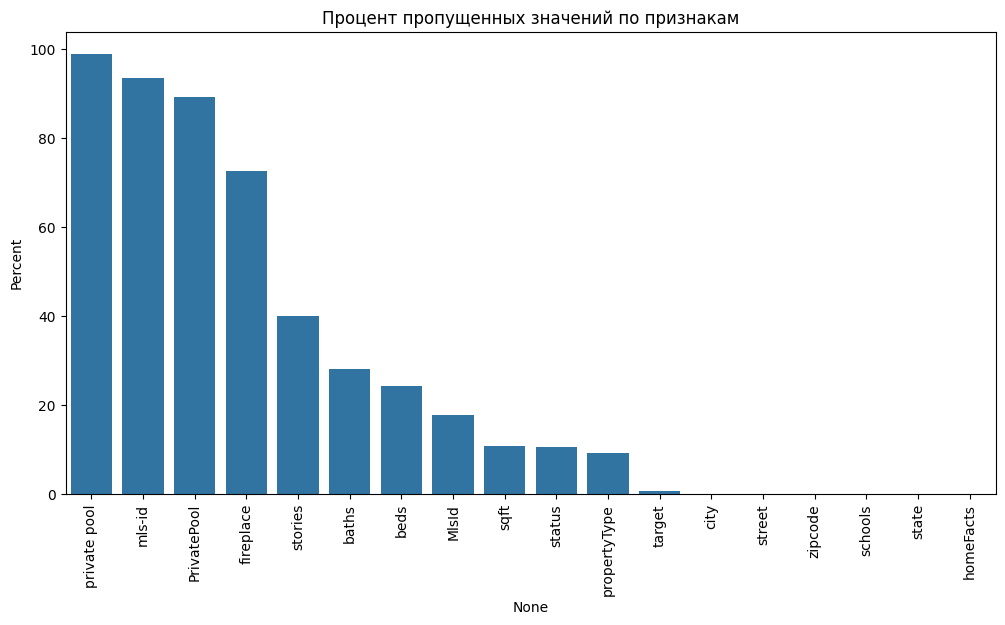

In [319]:
missing_values = data.isnull().sum().sort_values(ascending=False)
percent_missing = (missing_values / len(data)) * 100

missing_data = pd.concat([missing_values, percent_missing], axis=1, keys=['Total', 'Percent'])
print("Пропущенные значения:\n", missing_data)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_data.index, y=missing_data['Percent'])
plt.xticks(rotation=90)
plt.title('Процент пропущенных значений по признакам')
plt.show()

Вывод: Такие признаки как private pool, mls-id, PrivatePool, fireplace, stories имеют более 30% пропусков, что делает данные признаки малоинформативными для анализа, их следует удлаить.
Однако посмотрим отдельно на то, что содержится в private pool и PrivatePool:

In [320]:
print(data['private pool'].unique())
print(data['PrivatePool'].unique())

[nan 'Yes']
[nan 'yes' 'Yes']


'private pool' и 'PrivatePool' содержат дублирующую информацию, объеденим их, так же отметим, поскольку у нас всего 3 значения, то вероятнее всего пропуск свидетельствует об отсутствии бассейна. Закодируем его булевыми переменными, а так же удалим 'mls-id' и 'MlsId' поскольку это признаки существуют для идентификации объекта в общих базах риэлторов для наших задач он не требуется. Так же удалим признак 'zipcode'

In [321]:
# Объединяем столбцы
data['pool_encoded'] = data['private pool'].combine_first(data['PrivatePool'])
data_drop = data.copy()
# Удаляем столбец PrivatePool
data_drop = data_drop.drop(['PrivatePool', 'private pool', 'MlsId', 'mls-id','zipcode'], axis=1)
# Заменить NaN на False
data_drop['pool_encoded'] = data_drop['pool_encoded'].fillna(False)
# Заменить 'yes' и 'Yes' на True
data_drop['pool_encoded'] = data_drop['pool_encoded'].replace(['yes', 'Yes'], True)
# Выводим результат
print("Уникальные значения 'pool_encoded':", data_drop['pool_encoded'].unique())
display(data_drop.head())

Уникальные значения 'pool_encoded': [False  True]


,status,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,beds,state,stories,target,pool_encoded
0,Active,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,4,NC,NaN,"$418,000",False
1,for sale,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",3 Beds,WA,2.0,"$310,000",False
2,for sale,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",3 Beds,CA,1.0,"$2,895,000",True
3,for sale,single-family home,4311 Livingston Ave,8 Baths,"{'atAGlanceFacts': [{'factValue': '2006', 'fac...",yes,Dallas,"[{'rating': ['9/10', '9/10', '10/10', '9/10'],...","6,457 sqft",5 Beds,TX,3.0,"$2,395,000",False
4,for sale,lot/land,1524 Kiscoe St,NaN,"{'atAGlanceFacts': [{'factValue': '', 'factLab...",NaN,Palm Bay,"[{'rating': ['4/10', '5/10', '5/10'], 'data': ...",NaN,NaN,FL,NaN,"$5,000",False


Проверим, есть ли дубликаты

In [322]:
# сохраняем количество строк до удаления дубликатов
rows_before = data_drop.shape[0]
#удалим дубликаты
data_drop = data_drop.drop_duplicates(ignore_index=True)
# сохраняем количество строк после удаления дубликатов
rows_after = data_drop.shape[0]
# считаем количество удаленных дубликатов
duplicates_removed = rows_before - rows_after
print(f'Удалено {duplicates_removed} дубликатов')

Удалено 141 дубликатов


In [323]:
def handle_missing_values(data, threshold=0.3):

    # Вычисление процента пропущенных значений
    missing_percentage = (data.isnull().sum() / len(data)) * 100

    # Выбор столбцов для удаления
    columns_to_drop = missing_percentage[missing_percentage > threshold * 100].index

    # Удаление столбцов
    data_1 = data.drop(columns=columns_to_drop)

    return data_1, missing_percentage

data_1, missing_percentage = handle_missing_values(data_drop.copy()) # передаем копию, чтобы не менять исходный датафрейм

print("Процент пропущенных значений:\n", missing_percentage)
print("\nФорма исходного DataFrame:", data.shape)
print("Форма DataFrame после удаления столбцов:", data_1.shape)

Процент пропущенных значений:
 status          10.586563
propertyType     9.209800
street           0.000530
baths           28.182918
homeFacts        0.000000
fireplace       72.653059
city             0.008487
schools          0.000000
sqft            10.751000
beds            24.189485
state            0.000000
stories         39.938044
target           0.657748
pool_encoded     0.000000
dtype: float64

Форма исходного DataFrame: (377185, 19)
Форма DataFrame после удаления столбцов: (377044, 12)


### Обработаем признак status

In [324]:
missing_values_count = data_1.status.isna().sum()
total_count = len(data_1)
missing_values_percentage = (missing_values_count / total_count) * 100

print(f"Количество пропущенных значений: {missing_values_count}\n"
      f"Процент пропущенных значений: {missing_values_percentage:.2f}%\n"
      f"Количество уникальных значений: {data_1.status.nunique()}\n")


Количество пропущенных значений: 39916
Процент пропущенных значений: 10.59%
Количество уникальных значений: 159



В столбце содержится 159 уникальных значений и 39 916 пропущенных значений. Некоторые значения написаны по-разному, но означают одно и то же. Необходимо стандартизовать их, переведя все в нижний регистр и заполнив пропущенные значения наиболее распространенным вариантом.

Так же встречаются разные варианты написания одних и тех же фраз или фраз со схожим значением. Давайте стандартизируем их до общего формата, не теряя точности.

Наконец, сгруппируем статусы по связанным категориям. Некоторые редко используемые статусы и записи без статуса будут перемещены в категорию «Другое».

Сначала сгруппируем статусы по значению.

In [325]:
categories = {
    "For Sale": ["for sale", "For sale", 'Price Change','Listing Extended', 'For Sale'],
    "Active": ['Active','A Active', 'Active/Contingent', 'Active Under Contract', 'Active Contingency', 'Active With Contingencies', 'Active Option', 'Active Option Contract', 
               'Active - Auction', 'Active With Offer', 'Active Contingent', 'Active Backup', 'Active - Contingent', 'Active with Contract',
               ],
    'New construction': ['New construction','New'],
    "Pending": ['Pending', 'P', 'Pending Continue To Show', 'Pending Ab', 'Pending Inspection', 'Pending Continue To Show', 'Pending, Continue to Show', 'Pending - Taking Backups', 
                'Pending Offer Approval', 'Pending In', 'Pending W/Insp Finance', 'Pending (Do Not Show)', 'Pending W/ Cont.', 'Pending W/Escape Clause', 'Pending - Continue to Show',
                'Pending W/Backup Wanted', 'Pending Backups Wanted', 'Pending Fe', 'Pending Sale', 'Pending Take Backups', 'Pending - Backup Offer Requested', 'Pending Sh', 'P Pending Sale',
                'Pf', 'Pi', 'Pending Taking Backups', 'Pending Bring Backup', 'Pending Backups Wanted'
                ],
    "Contingent": ['Contingent', 'Contingent Show', 'Contingent Take Backup', 'Contingent Show', 'Contingent Release', 'Contingent Escape', 'Contingent Lien Holder Release', 
                            'Contingent No Show', 'Contingent Foreclosure', 'Conting Accpt Backups', 'Contingent - Sale of Home', 'Contingent Finance And Inspection', 
                            'Contingent Finance and Inspection', 'CT Insp - Inspection Contingency', 'Contract Contingent On Buyer Sale', 'Contingency Contract', 'Contingency 48 Hr (+/ )',
                            'Contingent - Financing', 'Re Activated', 'Reactivated', 'Uc Continue To Show', 'C', 'C Continue Show', 'C Continue Show', 'Ct'
                            ],
    "Under Contract": ['Under Contract', 'Under Contract Showing', 'Under Contract Backups', 'Under Contract Show', 'Under contract', 'U Under Contract', 'Under Contract - Show', 
                       'Under Contract - No Show', 'Under Contract Taking Back Up Offers', 'Contract', 'Contract P', 'Conditional Contract', 'Accepted Offer', 'Backup Contract',
                       'Under Contract W/ Bckp', 'Backup'
                       ],
    "For rent": ["for rent", "Apartment for rent", "Condo for rent",'Lease/Purchase Pending','Lease/Purchase'],
    "Auction": ['Pre-foreclosure / auction',' / auction', 'Auction','Auction - Active','Active - Auction'],
    "Closed": ["Closed","recently sold",'Foreclosed','Sold: $285,000', 'Sold: $15,000' ,'foreclosure','Foreclosure',],
    "Back on Market": ["Back on Market", "Back On Market"],
   
    "Coming Soon": [
        "Coming soon: Nov 21.", "Coming soon: Dec 4.", "Coming soon: Nov 23.", "Coming soon: Nov 29.",
        "Coming soon: Dec 2.", "Coming soon: Dec 10.", "Coming soon: Dec 24.", "Coming soon: Nov 14.",
        "Coming soon: Nov 22.", "Coming soon: Oct 21.", "Coming soon: Dec 14.", "Coming soon: Oct 24.",
        "Coming soon: Dec 18.", "Coming soon: Dec 16.", "Coming soon: Dec 3.", "Coming soon: Dec 25.",
        "Coming soon: Nov 11.", "Coming soon: Nov 28.", "Coming soon: Nov 17.", "Coming soon: Dec 6.",
        "Coming soon: Nov 27.", "Coming soon: Nov 26.", "Coming soon: Dec 7.", "Coming soon: Dec 27.",
        "Coming soon: Dec 11.", "Coming soon: Dec 5.", "Coming soon: Nov 13.", "Coming soon: Nov 19.",
        "Coming soon: Nov 8.", "Coming soon: Oct 29.", "Coming soon: Dec 15.", "Coming soon: Oct 30.",
        "Coming soon: Dec 9.", "Coming soon: Dec 20.", "Coming soon: Dec 13.", "Coming soon: Dec 23.",
        "Coming soon: Nov 30.", "Coming soon: Dec 1.", "Coming soon: Nov 5.", "Coming soon: Nov 12.",
        "Coming soon: Nov 25.", "Coming soon: Nov 9."
    ],
}

def categorize_status(status_value):
    for category, values in categories.items():
        if status_value in values:
            return category
    return "Other"

# заменим значения на категории
data_1['status'] = data_1['status'].apply(categorize_status)
data_1.head()

,status,propertyType,street,baths,homeFacts,city,schools,sqft,beds,state,target,pool_encoded
0,Active,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,4,NC,"$418,000",False
1,For Sale,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",3 Beds,WA,"$310,000",False
2,For Sale,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",3 Beds,CA,"$2,895,000",True
3,For Sale,single-family home,4311 Livingston Ave,8 Baths,"{'atAGlanceFacts': [{'factValue': '2006', 'fac...",Dallas,"[{'rating': ['9/10', '9/10', '10/10', '9/10'],...","6,457 sqft",5 Beds,TX,"$2,395,000",False
4,For Sale,lot/land,1524 Kiscoe St,NaN,"{'atAGlanceFacts': [{'factValue': '', 'factLab...",Palm Bay,"[{'rating': ['4/10', '5/10', '5/10'], 'data': ...",NaN,NaN,FL,"$5,000",False


(array([     0.,  25000.,  50000.,  75000., 100000., 125000., 150000.,
        175000., 200000., 225000.]),
 [Text(0, 0.0, '0'),
  Text(0, 25000.0, '25000'),
  Text(0, 50000.0, '50000'),
  Text(0, 75000.0, '75000'),
  Text(0, 100000.0, '100000'),
  Text(0, 125000.0, '125000'),
  Text(0, 150000.0, '150000'),
  Text(0, 175000.0, '175000'),
  Text(0, 200000.0, '200000'),
  Text(0, 225000.0, '225000')])

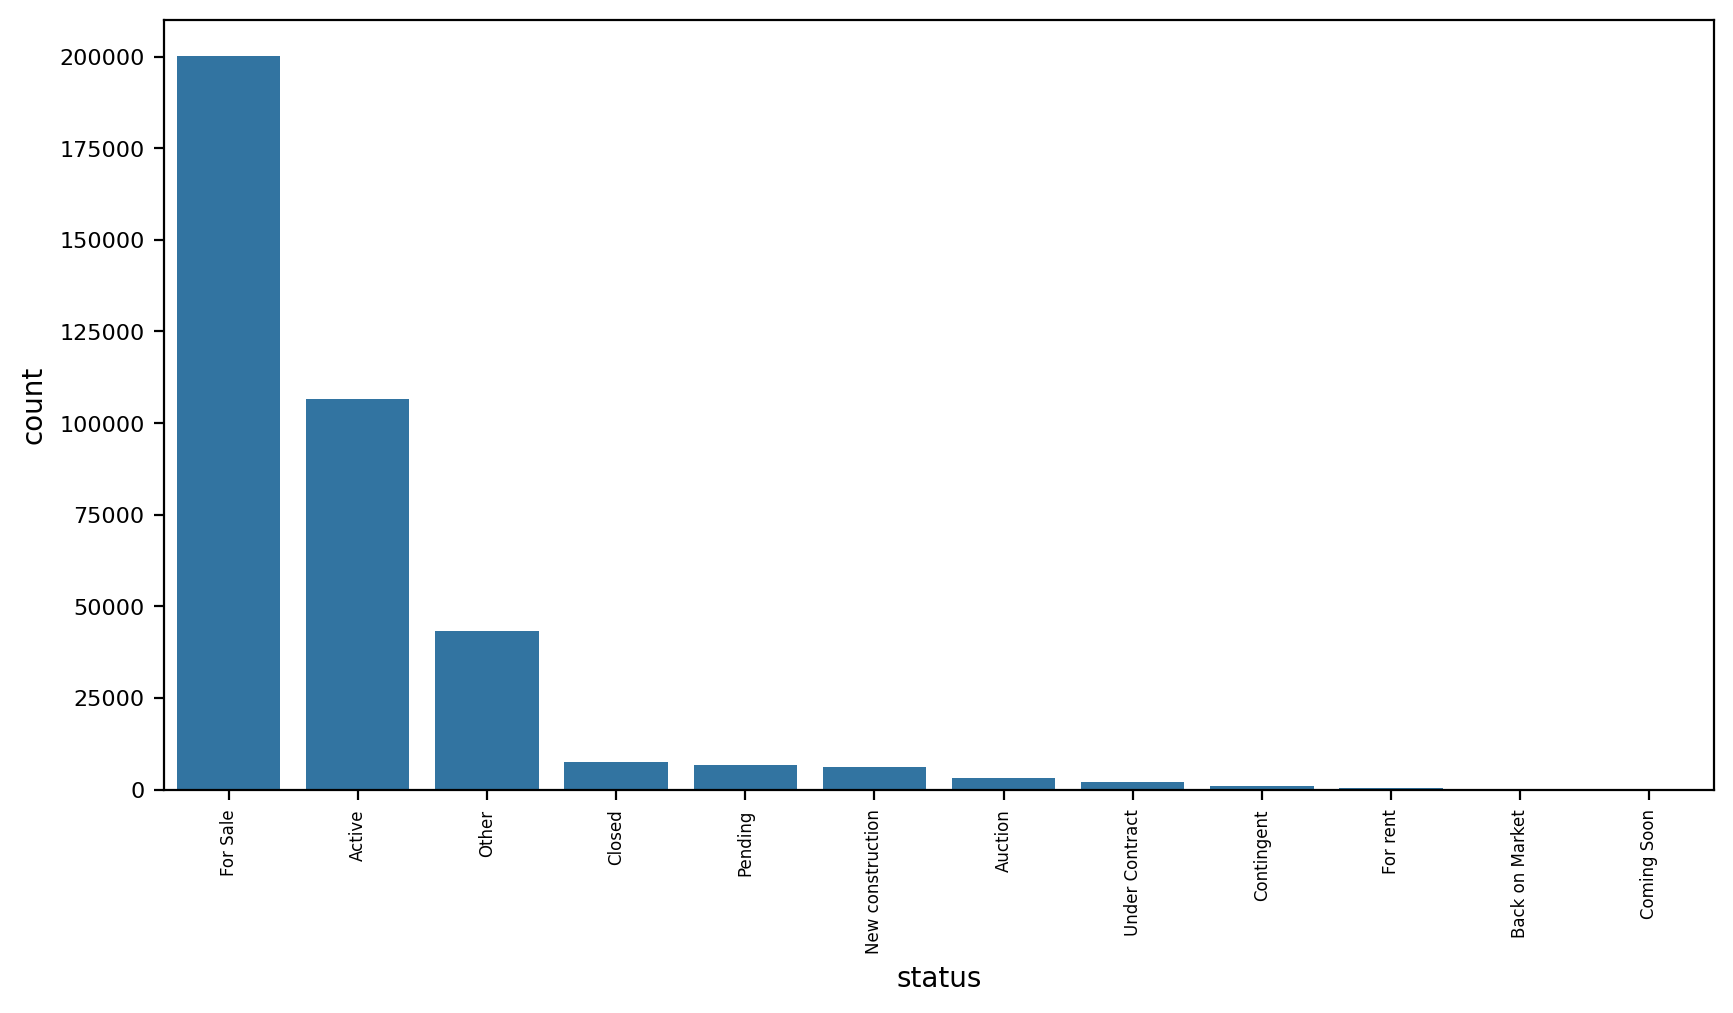

In [326]:
plt.figure(figsize=(10, 5), dpi=200)

sns.countplot(data=data_1, x='status', order=data_1['status'].value_counts(ascending=False).index )
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=8)

Из графика видно, что три категории значительно выделяются от остальных: For Sale, Active, and Other.

### Обработаем признак propertyType

In [327]:
missing_values_count = data_1.propertyType.isna().sum()
total_count = len(data_1)
missing_values_percentage = (missing_values_count / total_count) * 100

print(f"Количество пропущенных значений: {missing_values_count}\n"
      f"Процент пропущенных значений: {missing_values_percentage:.2f}%\n"
      f"Количество уникальных значений: {data_1.propertyType.nunique()}\n")
      

Количество пропущенных значений: 34725
Процент пропущенных значений: 9.21%
Количество уникальных значений: 1280



In [328]:
# переведем все в строчные
data_1.propertyType = data_1.propertyType.str.lower()
# приведем разное написание к едионму виду, заменим yes и unknown на Other
data_1.propertyType = data_1.propertyType \
.str.replace('single-family home','single family') \
.str.replace('single family home','single family') \
.str.replace('yes','Other') \
.str.replace('unknown','Other')
# Создадим признак Type и запишем в него объединенные по 1 слову данные 
data_1['Type'] = data_1['propertyType'].str.split(',').str[0]

In [329]:
top_30_property_types = data_1['Type'].value_counts().nlargest(30)

print(top_30_property_types)

Type
single family                    186757
condo                             42525
lot/land                          20520
townhouse                         18529
land                              10899
multi-family                       7921
condo/townhome/row home/co-op      7697
traditional                        6073
coop                               3265
single detached                    3065
multi family                       2793
detached                           2670
ranch                              2033
high rise                          1952
contemporary                       1815
1 story                            1810
mobile/manufactured                1618
multi-family home                  1501
2 stories                          1489
colonial                           1328
contemporary/modern                1328
mobile / manufactured              1066
apartment                           924
condo/townhome                      808
mfd/mobile home                    

Cгруппируем по значению.

In [330]:
synonyms_mapping = {
    'single_family_home': [
        'single family', '1 story', '2 story', 'detached', '1 story/ranch', '1 story traditional', 'single detached', 'singlefamilyresidence', 'single wide', 'single-wide mobile with land',
        'two story', 'one story', 'one level unit', 'rancher', '1 1/2 story', 'single wide mh', 'one story traditional'],
    'multi_family_home': [
        'multi-family', 'multi-family home', 'duplex', 'triplex', 'fourplex', 'multi_level', 'multi family', '2 unit condo', '2-story'],
    'condo': [
        'condo', 'coop', 'cooperative', 'condo/townhome/row home/co-op', 'condo/townhome', 'condominium', 'condo/unit', 'apartment/condo/townhouse', 'co-op', '2 story condo', 'high rise'],
    'townhouse': [
        'townhouse', 'townhome style', 'townhouse-interior', 'townhouse-end unit'],
    'apartment': [
        'apartment', 'condominium (single level)', 'high-rise', 'mid-rise', 'low-rise (1-3 stories)', 'Flats', 'studio'],
    'land': [
        'lot/land', 'land','land/lot','commercial/industrial', 'warehouse'],
    'mobile_home': [
        'mobile/manufactured', 'mobile / manufactured', 'manufactured house', 'mfd/mobile home', 'mobile home', 'manufactured home', 'manufactured double-wide', 'manufactured single-wide', 'mobile home 1 story', 'mobile manu - double wide'],
    'miscellaneous': [
        'miscellaneous'],
    'ranch': [
        'ranch', 'one story'],
    'modern': [
        'contemporary', 'contemporary/modern', "modern", 'mid-century modern', 'modern farmhouse', 'modernist'],
    'historical': [
        'historical', 'designated historical home', 'historical/conservation district', 'historic/older', 'historic vintage', 'historic'],
    'other': [
        'Other', 'english', 'urban contemporary', 'other style', 'florida', 'farms/ranches', 'carriage house', 'country english', 'straight thru', 'less than 4 floors', 'bungalow', 'custom', 'arts & crafts', 'tudor', 'new build 2019', 'split foyer', 'cottage', 'cottage/camp', 'garden home', 'farm/ranch', 'farm/ranch house', 'farm house', 'hi ranch', 'attached duplex', 'farmhouse', 'houseboat', 'ground floor', 'victorian', '3 story', '3+ stories', 'santa barbara/tuscan', 'old style', 'modular/prefab', 'post and beam', 'manuf/mobile', 'multiple occupancy', 'attached', 'hawaiian plantation', 'forest garden home', '1 1/2 story with basement', 'split-entry', 'texas hill country', 'lake house', '1 story with basement', 'hi-rise', 'coastal beach home', 'historical', 'key west/coastal', 'loft/balcony', 'english manor', 'mid-rise (4-7 stories)', 'mid-level', 'new englander', 'residential (<1 acre)', 'ranch','residential (1+ acre)', 'split', 'split level', 'split (4 level)', 'split (5+ level)', 'urban', 'patio', 'patio home', 'penthouse', 'manor', 'victorian/federal', 'coastal', 'coastal contemporary', 'coastal ii', 'coastal modern', 'coastal two story', 'mountain contemporary', 'key west', 'high ranch', 'end unit']
}


def replace_synonyms(value):
    for key, synonym_values in synonyms_mapping.items():
        if value in synonym_values:
            return key
    return "other"

# Замена синонимов
data_1['Type'] = data_1['Type'].apply(replace_synonyms)

(array([     0.,  25000.,  50000.,  75000., 100000., 125000., 150000.,
        175000., 200000., 225000.]),
 [Text(0, 0.0, '0'),
  Text(0, 25000.0, '25000'),
  Text(0, 50000.0, '50000'),
  Text(0, 75000.0, '75000'),
  Text(0, 100000.0, '100000'),
  Text(0, 125000.0, '125000'),
  Text(0, 150000.0, '150000'),
  Text(0, 175000.0, '175000'),
  Text(0, 200000.0, '200000'),
  Text(0, 225000.0, '225000')])

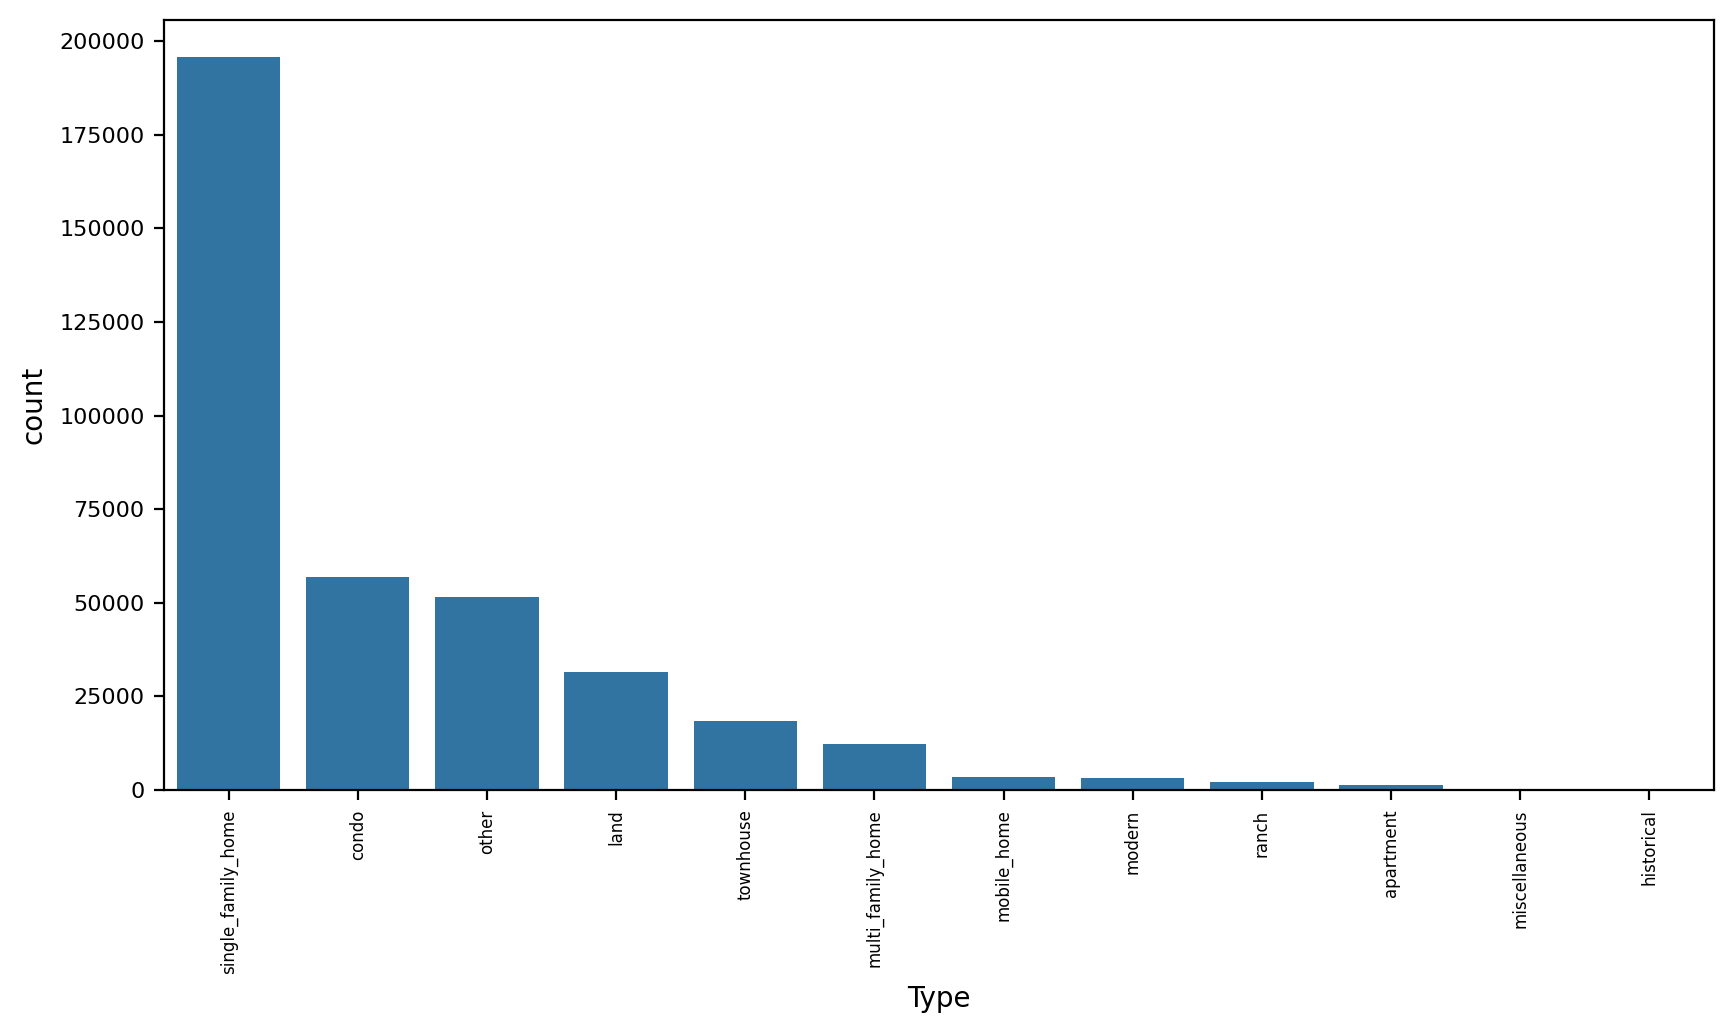

In [331]:
plt.figure(figsize=(10, 5), dpi=200)

sns.countplot(data=data_1, x='Type', order=data_1['Type'].value_counts(ascending=False).index )
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=8)

In [332]:
# теперь propertyType можно удалить
data_1.drop('propertyType', axis=1, inplace=True)

In [333]:
print(f"Количество уникальных значений: {data_1.Type.nunique()}\n")

Количество уникальных значений: 12



### Обработаем признак street

In [334]:
data_1['street'].value_counts()

street
Address Not Disclosed       672
Undisclosed Address         513
(undisclosed Address)       390
Address Not Available       174
Unknown Address              72
                           ... 
11630 Hardwood Ct #I          1
1369 N Downing St #3          1
100 Zambrano Rd               1
2846 Grasmere View Pkwy       1
5983 Midcrown Dr              1
Name: count, Length: 337076, dtype: int64

In [335]:
missing_values_count = data_1.street.isna().sum()
total_count = len(data_1)
missing_values_percentage = (missing_values_count / total_count) * 100

print(f"Количество пропущенных значений: {missing_values_count}\n"
      f"Процент пропущенных значений: {missing_values_percentage:.2f}%\n"
      f"Количество уникальных значений: {data_1.street.nunique()}")

Количество пропущенных значений: 2
Процент пропущенных значений: 0.00%
Количество уникальных значений: 337076


In [336]:
# удаляем строки, где есть пропуски в столбце street
data_1 = data_1.dropna(subset=['street'])

In [337]:
data_1['street'] = data_1['street'].replace(['Address Not Disclosed', 'Undisclosed Address', '(undisclosed Address)', 'Address Not Available', 'Unknown Address'], 'other')

In [338]:
data_1['street'].value_counts()

street
other                       1821
2103 E State Hwy 21           56
11305 Gulf Fwy                53
17030 Youngblood Rd.          38
9470 Lancaster Rd. SW         32
                            ... 
11630 Hardwood Ct #I           1
1369 N Downing St #3           1
100 Zambrano Rd                1
2846 Grasmere View Pkwy        1
5983 Midcrown Dr               1
Name: count, Length: 337072, dtype: int64

### Обработаем признак baths

In [339]:
missing_values_count = data_1.baths.isna().sum()
total_count = len(data_1)
missing_values_percentage = (missing_values_count / total_count) * 100

print(f"Количество пропущенных значений: {missing_values_count}\n"
      f"Процент пропущенных значений: {missing_values_percentage:.2f}%\n"
      f"Количество уникальных значений: {data_1.baths.nunique()}\n")

Количество пропущенных значений: 106260
Процент пропущенных значений: 28.18%
Количество уникальных значений: 229



In [340]:
data_1.baths.sort_values().unique()

array(['-- baths', '0', '0 / 0', '0.0', '0.00', '0.5 Baths', '0.75 Baths',
       '1', '1 / 1 / 1 / 1', '1 / 1-0 / 1-0 / 1-0', '1 ba', '1,000',
       '1,250', '1,500', '1,750', '1-0 / 1-0 / 1', '1-2 Baths', '1.0',
       '1.1 Baths', '1.25 Baths', '1.5', '1.5 Baths', '1.5 ba', '1.5+',
       '1.75 Baths', '1.75 ba', '1.8 Baths', '10', '10 Baths', '10 ba',
       '10.0', '10.5', '10.5 Baths', '10.5+', '11', '11 Baths', '11 ba',
       '11.0', '11.5 Baths', '11.5+', '116 / 116 / 116', '12', '12 Baths',
       '12 ba', '12.0', '12.5', '12.5+', '13', '13 Baths', '13 ba',
       '13.0', '14', '14 Baths', '14.0', '14.5+', '15', '15 Baths',
       '15.0', '16', '16 Baths', '16 ba', '16.0', '17', '17 Baths',
       '17.0', '18', '18 Baths', '18.0', '19 Baths', '2', '2 Baths',
       '2 ba', '2 baths', '2,000', '2,250', '2,500', '2,750',
       '2-1 / 2-1 / 1-1 / 1-1', '2.0', '2.1 Baths', '2.2 Baths',
       '2.25 Baths', '2.25 ba', '2.5', '2.5 Baths', '2.5 ba', '2.5+',
       '2.75 Baths', '2

In [341]:
# Удаляем все буквы и двоеточия
data_1.baths = data_1.baths.str.replace('[a-zA-Z:]','', regex=True)
# Удаляем все пробелы
data_1.baths = data_1.baths.str.replace(' ','', regex=True)

In [342]:
# сделаем копию что бы не перезапускать весь код в слкчае ошибок
df1=data_1.copy()

In [343]:
# поправим значения
df1['baths'] = df1['baths'].str.replace('[a-zA-Z+:]','', regex=True)
df1['baths'].replace(['nan','', '~', '..', '--', '—','0.0','0.00','0/0'], 0, inplace=True)
df1['baths'].replace(['1-2','1/1-0/1-0/1-0', '1/1/1/1','1-0/1-0/1', ], 1, inplace=True)
df1['baths'].replace(['2-1/2-1/1-1/1-1','3-1/2-2',], 2, inplace=True)
df1['baths'].replace(['116/116/116'], 116, inplace=True)
df1['baths'].replace(['7,500'], 7.5, inplace=True)
df1['baths'].replace(['5,000'], 5, inplace=True)
df1['baths'].replace(['3,500'], 3.5, inplace=True)
df1['baths'].replace(['2,750'], 2.75, inplace=True)
df1['baths'].replace(['2,250'], 2.25, inplace=True)
df1['baths'].replace(['1,250'], 1.25, inplace=True)
df1['baths'].replace(['1,500'], 1.5, inplace=True)
df1['baths'].replace(['4,000'], 4, inplace=True)
df1['baths'].replace(['2,000'], 2, inplace=True)
df1['baths'].replace(['3,000'], 3, inplace=True)
df1['baths'].replace(['2,500'], 2.5, inplace=True)
df1['baths'].replace(['1,000'], 1, inplace=True)
df1['baths'].replace(['1,750'], 1.75, inplace=True)


In [344]:
# переведем в числовой признак и округлим до целого числа
df1['baths'] = df1['baths'].astype(float).round()

(array([     0.,  20000.,  40000.,  60000.,  80000., 100000., 120000.,
        140000.]),
 [Text(0, 0.0, '0'),
  Text(0, 20000.0, '20000'),
  Text(0, 40000.0, '40000'),
  Text(0, 60000.0, '60000'),
  Text(0, 80000.0, '80000'),
  Text(0, 100000.0, '100000'),
  Text(0, 120000.0, '120000'),
  Text(0, 140000.0, '140000')])

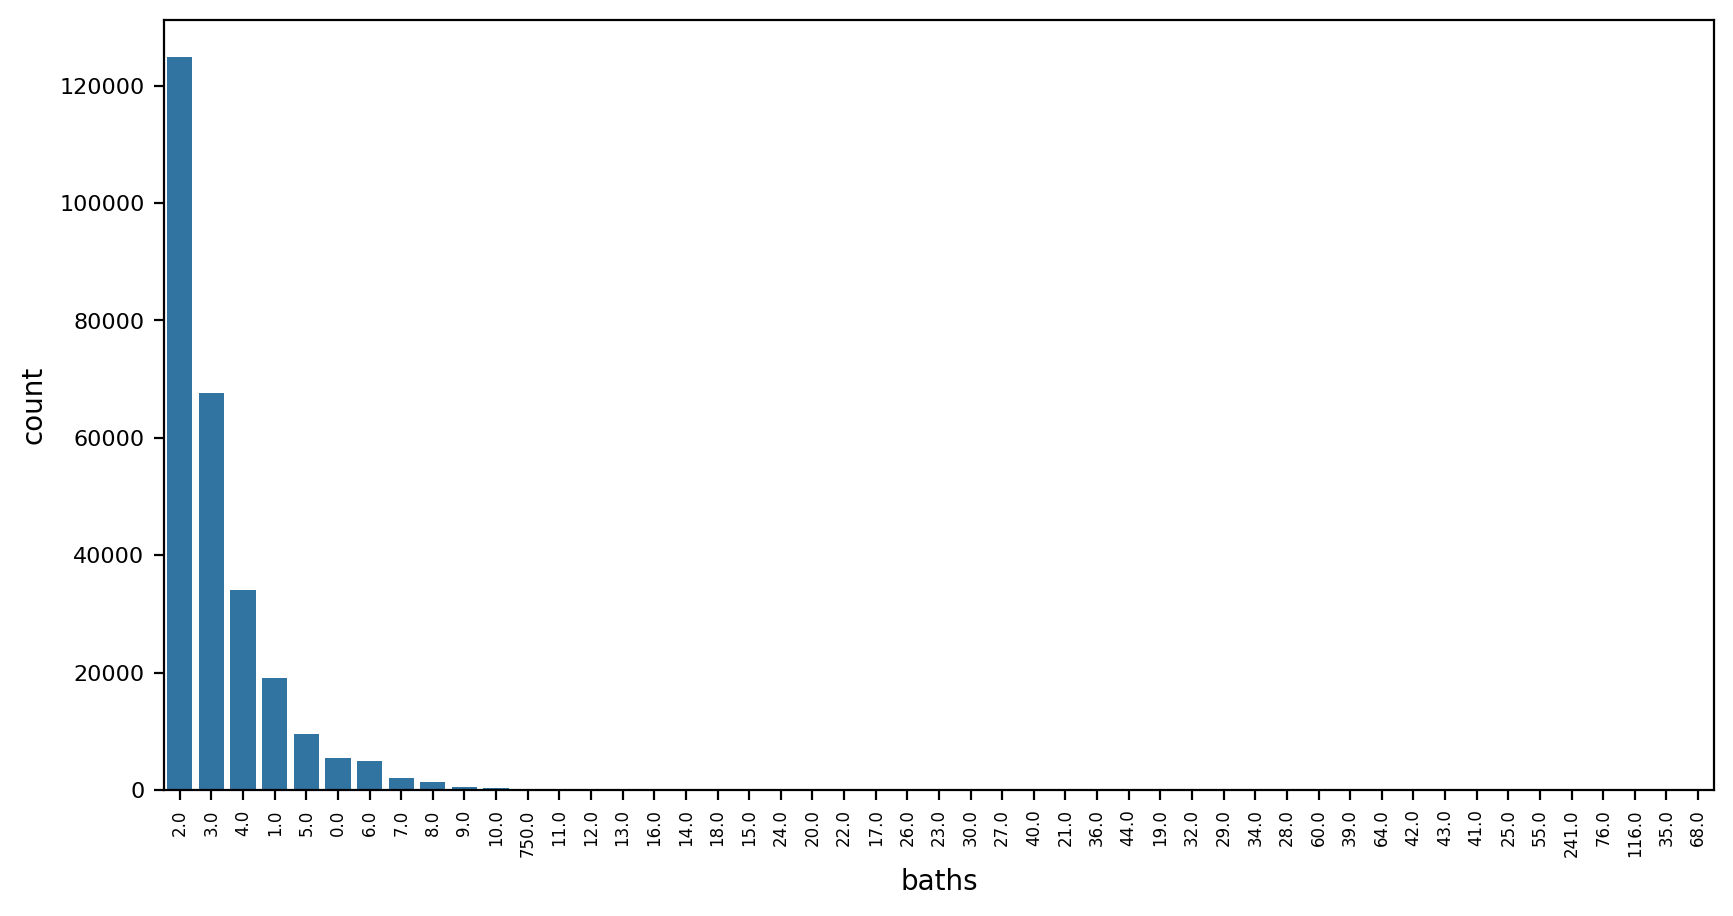

In [345]:
plt.figure(figsize=(10, 5), dpi=200)

sns.countplot(data=df1, x='baths', order=df1['baths'].value_counts(ascending=False).index )
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=8)

In [346]:
# пропуски заполним нулями так как большинство пропущенных значений соответствуют земле где нет здания
df1['baths'] = df1['baths'].fillna('no data')

Посмортим на записи, в которых указано нереальное число ванных комнат.

In [347]:
df1[df1['baths']==750]

,status,street,baths,homeFacts,city,schools,sqft,beds,state,target,pool_encoded,Type
1109,Active,3624 Douglas Ave,750.0,"{'atAGlanceFacts': [{'factValue': '1993', 'fac...",Dallas,"[{'rating': ['5', '5', '2', '10'], 'data': {'D...","1,758",Baths,TX,"499,000",False,other
2022,Active,920 I St NW #411,750.0,"{'atAGlanceFacts': [{'factValue': '2013', 'fac...",Washington,"[{'rating': ['8', '8', '3', '8'], 'data': {'Di...","1,367",NaN,DC,"1,499,000",False,other
3594,Active,601 W 11th Ave #409,750.0,"{'atAGlanceFacts': [{'factValue': '1981', 'fac...",DENVER,"[{'rating': ['5', 'NR', '5', '2'], 'data': {'D...",873,Baths,CO,"348,900",False,other
7564,Active,1260 Xavier St,750.0,"{'atAGlanceFacts': [{'factValue': '1936', 'fac...",DENVER,"[{'rating': ['2', '2', '2'], 'data': {'Distanc...","1,864",Baths,CO,"560,000",False,other
7693,Active,3314 Douglas Ave Unit 202D,750.0,"{'atAGlanceFacts': [{'factValue': '1984', 'fac...",Dallas,"[{'rating': ['4', '3', '2', '10'], 'data': {'D...","1,336",Baths,TX,"285,000",False,condo
...,...,...,...,...,...,...,...,...,...,...,...,...
372465,Active,601 Pennsylvania Ave NW #212,750.0,"{'atAGlanceFacts': [{'factValue': '1991', 'fac...",Washington,"[{'rating': ['8', '8', '3', '5'], 'data': {'Di...",801,NaN,DC,"449,000",False,other
375494,Active,3225 Turtle Creek Blvd #1646,750.0,"{'atAGlanceFacts': [{'factValue': '1998', 'fac...",Dallas,"[{'rating': ['5', '5', '2', '10'], 'data': {'D...",832,Baths,TX,"219,500",False,condo
375872,Active,2262 Alterbrook Ln,750.0,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Dallas,"[{'rating': ['4', '3', '2', '10'], 'data': {'D...","2,102",Baths,TX,"464,900",False,condo
376007,Active,3225 Turtle Creek Blvd #528,750.0,"{'atAGlanceFacts': [{'factValue': '1998', 'fac...",Dallas,"[{'rating': ['5', '5', '2', '10'], 'data': {'D...",837,Baths,TX,"240,000",False,condo


Возможно это ошибка, и должно быть 7.5 (7), заменим

In [348]:
df1.loc[df1['baths'] == 750.0, 'baths'] = 7

In [349]:
df1[df1['baths']==241]

,status,street,baths,homeFacts,city,schools,sqft,beds,state,target,pool_encoded,Type
11118,For Sale,1204 E Helena Ave,241.0,"{'atAGlanceFacts': [{'factValue': '2014', 'fac...",McAllen,"[{'rating': ['6/10', 'NA', '4/10'], 'data': {'...","Total interior livable area: 3,770 sqft",4 bd,TX,"$449,000",False,single_family_home


Всего одна запись с таким значением, можно заметить, что этот дом с 4 спальнями, следовательно ванных, можно предположить, будет 4. Заменим

In [350]:
df1.loc[df1['baths'] == 241, 'baths'] = 4

In [351]:
df1[df1['baths']==116.0]

,status,street,baths,homeFacts,city,schools,sqft,beds,state,target,pool_encoded,Type
63509,Active,321 Larkin Springs Rd,116.0,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Madison,"[{'rating': ['1', 'NR', '3', '1', '2', '1', 'N...",99999,NaN,TN,"$1,600,000",False,multi_family_home


Запись выглядит ошибочной, площадь здания 99999кв футов. Удалим ее.

In [352]:
df1 = df1[df1['baths'] != 116.0]

(array([     0.,  20000.,  40000.,  60000.,  80000., 100000., 120000.,
        140000.]),
 [Text(0, 0.0, '0'),
  Text(0, 20000.0, '20000'),
  Text(0, 40000.0, '40000'),
  Text(0, 60000.0, '60000'),
  Text(0, 80000.0, '80000'),
  Text(0, 100000.0, '100000'),
  Text(0, 120000.0, '120000'),
  Text(0, 140000.0, '140000')])

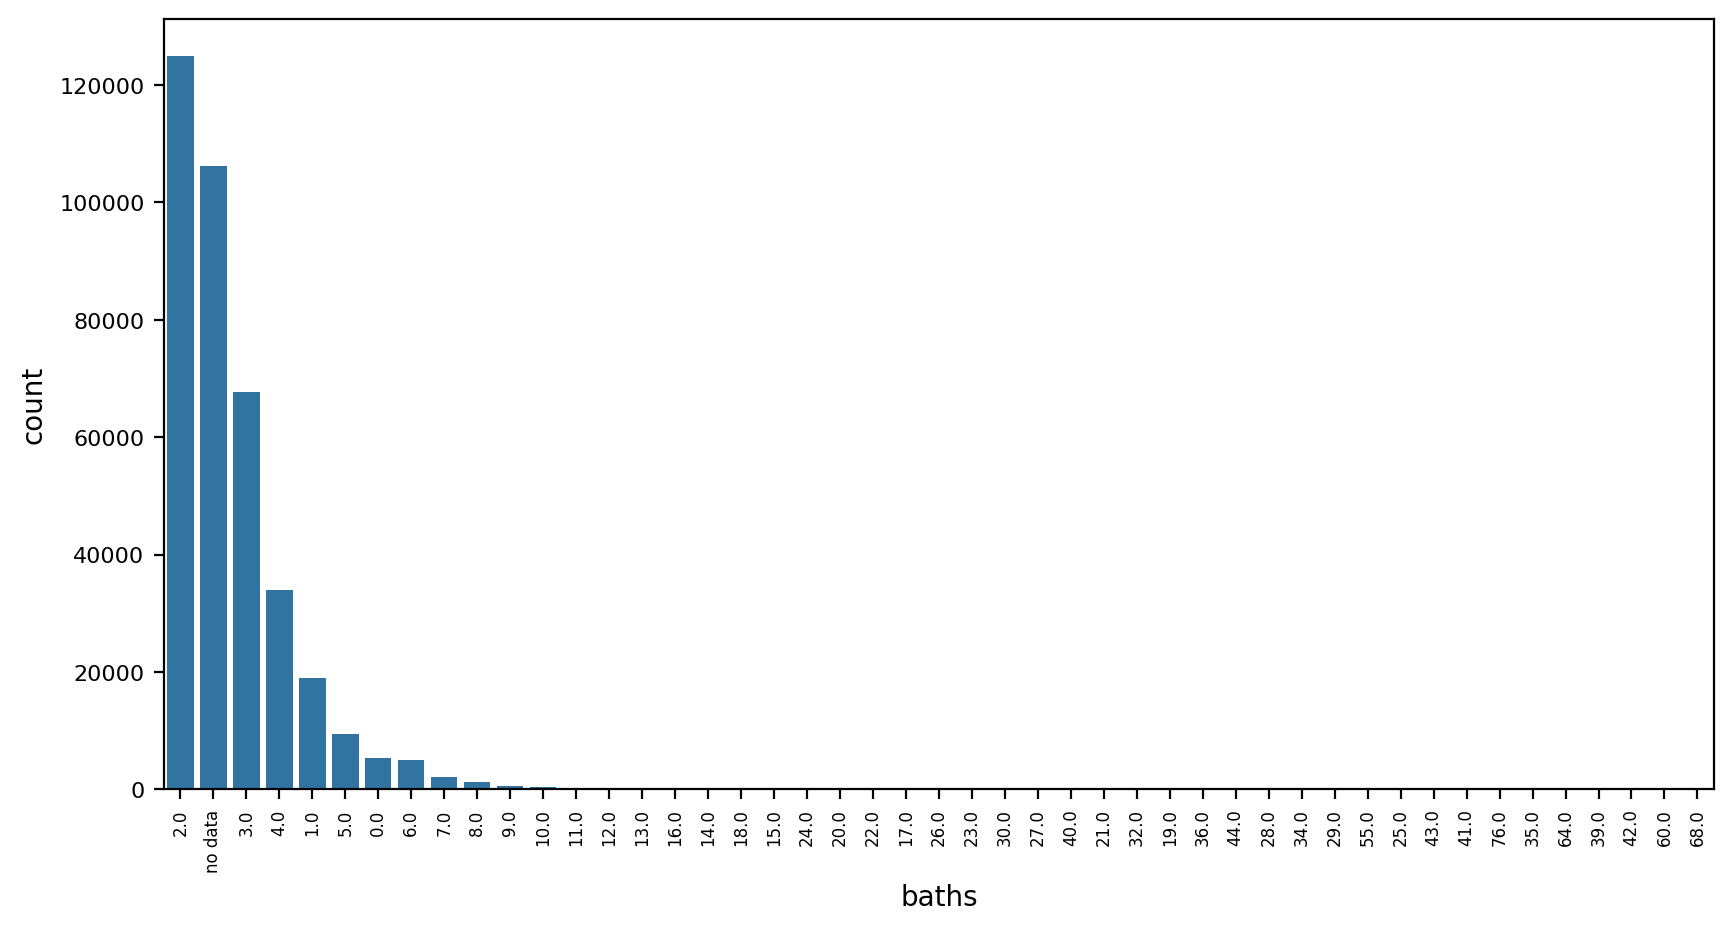

In [353]:
plt.figure(figsize=(10, 5), dpi=200)

sns.countplot(data=df1, x='baths', order=df1['baths'].value_counts(ascending=False).index )
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=8)

Возьмем первые 16 групп, остальные обозначим как other

In [354]:
def less_group_bath(group_name, index_list):
    if group_name not in index_list:
        return 'other'
    else:
        return group_name

index_list = df1.baths.value_counts().head(16).index.tolist()
df1.baths = df1.baths.apply(lambda x: less_group_bath(x,index_list))

### Обработаем признак beds

In [355]:
missing_values_count = df1.beds.isna().sum()
total_count = len(df1)
missing_values_percentage = (missing_values_count / total_count) * 100

print(f"Количество пропущенных значений: {missing_values_count}\n"
      f"Процент пропущенных значений: {missing_values_percentage:.2f}%\n"
      f"Количество уникальных значений: {df1.beds.nunique()}\n")

Количество пропущенных значений: 91203
Процент пропущенных значений: 24.19%
Количество уникальных значений: 1184



In [356]:
list(df1['beds'].sort_values().unique())

[' ',
 '# Bedrooms 1st Floor',
 '-- bd',
 '-- sqft',
 '0',
 '0.0',
 '0.25 acres',
 '0.26 acres',
 '0.27 acres',
 '0.28 acres',
 '0.29 acres',
 '0.3 acres',
 '0.31 acres',
 '0.32 acres',
 '0.33 acres',
 '0.34 acres',
 '0.35 acres',
 '0.36 acres',
 '0.37 acres',
 '0.38 acres',
 '0.39 acres',
 '0.4 acres',
 '0.41 acres',
 '0.42 acres',
 '0.43 acres',
 '0.44 acres',
 '0.45 acres',
 '0.46 acres',
 '0.47 acres',
 '0.48 acres',
 '0.49 acres',
 '0.5 acres',
 '0.51 acres',
 '0.52 acres',
 '0.53 acres',
 '0.54 acres',
 '0.55 acres',
 '0.56 acres',
 '0.57 acres',
 '0.58 acres',
 '0.59 acres',
 '0.6 acres',
 '0.61 acres',
 '0.62 acres',
 '0.63 acres',
 '0.64 acres',
 '0.65 acres',
 '0.66 acres',
 '0.67 acres',
 '0.68 acres',
 '0.69 acres',
 '0.7 acres',
 '0.71 acres',
 '0.72 acres',
 '0.73 acres',
 '0.74 acres',
 '0.75 acres',
 '0.76 acres',
 '0.77 acres',
 '0.78 acres',
 '0.79 acres',
 '0.8 acres',
 '0.81 acres',
 '0.82 acres',
 '0.83 acres',
 '0.84 acres',
 '0.85 acres',
 '0.86 acres',
 '0.87 ac

Данные вообще не понятнно как использовать, так как часть строк заполнена текстом, часть колличеством спален, а часть площадью.

In [357]:
df1['beds'] = df1['beds'].fillna('no data')

In [358]:
import re 

def clean_beds_data(beds):
    
    patterns = {
        'no data': [
            r'.*acre', r'.*sqft', r'Bath',r'.*--',r'^\s*$',r'Based on Redfin\'s Raleigh data, we estimate the home\'s value is \$708,248, which is 1.2\% more than its current list price.',
            r'Based on Redfin\'s St Johns data, we estimate the home\'s value is \$360,731, which is 2.2\% less than its current list price.',
        ],
        '0':[r'0.0'],
        '1':[r'1-2 Beds'],
        '2':[r'1 Bath, 2 Bedrooms, Cable TV Available, Dining Room, Eat-In Kitchen, Living Room',
             r'1 Bath, 2 Bedrooms, Eat-In Kitchen, Living Room, Range/Oven, Refrigerator',
             r'1 Bath, 2 Bedrooms, Living Room, Range/Oven, Refrigerator',
             r'1 Bath, 2 Bedrooms'],
        '3':[r'1 Bath, 3 or More Bedrooms, Cable TV Available, Dining Room, Eat-In Kitchen, Living Room, Range/Oven, Refrigerator',r'2 Baths, 3 or More Bedrooms',
             r'3 or More Bedrooms, Dining Room, Living Room, Range/Oven, Refrigerator',
             ]
    }

    for group, regex_patterns in patterns.items():
        for pattern in regex_patterns:
            if re.match(pattern, beds, re.IGNORECASE):
                return group

    return beds


def clean_beds_data_remove_words(beds):
    if beds == 'no data':
        return beds
    else:
        return float(re.sub(r'[^\d.,]', '', beds.replace(',','.')))

In [359]:
df1['bedsCleaned'] = df1['beds'].apply(clean_beds_data)
df1['bedsCleaned'] = df1['bedsCleaned'].apply(clean_beds_data_remove_words)

(array([     0.,  20000.,  40000.,  60000.,  80000., 100000., 120000.]),
 [Text(0, 0.0, '0'),
  Text(0, 20000.0, '20000'),
  Text(0, 40000.0, '40000'),
  Text(0, 60000.0, '60000'),
  Text(0, 80000.0, '80000'),
  Text(0, 100000.0, '100000'),
  Text(0, 120000.0, '120000')])

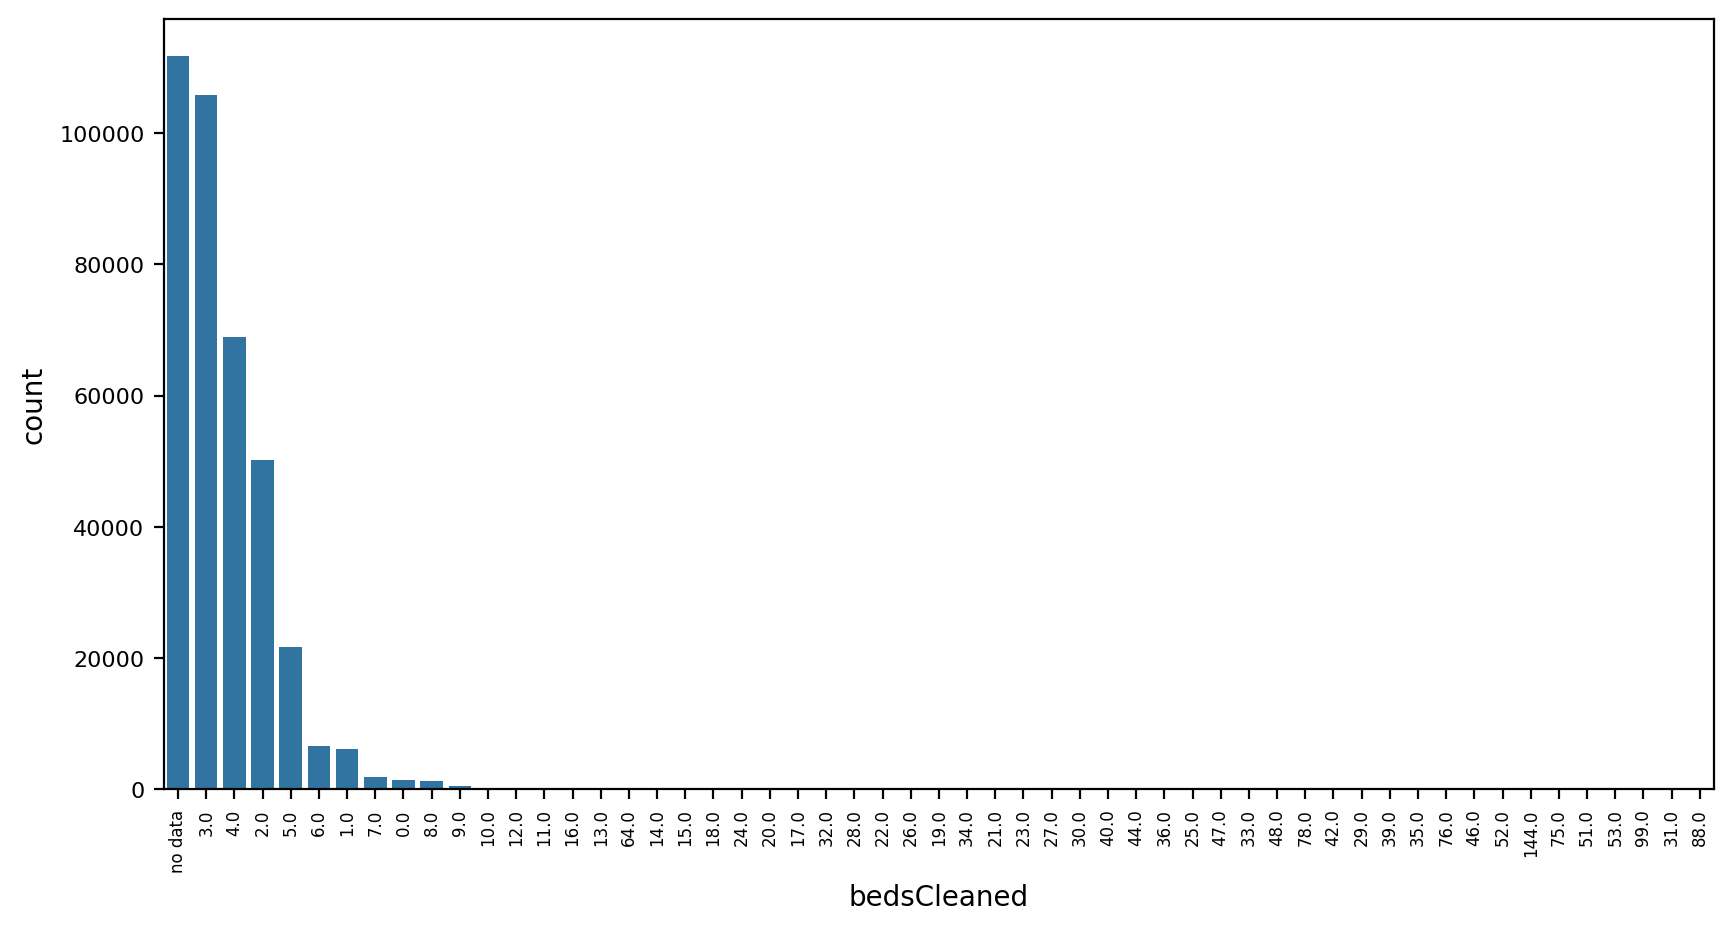

In [360]:
plt.figure(figsize=(10, 5), dpi=200)

sns.countplot(data=df1, x='bedsCleaned', order=df1['bedsCleaned'].value_counts(ascending=False).index )
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=8)

In [361]:
df1.drop(['beds'], axis=1, inplace=True)

### Обработаем признак 'homeFacts'

Признак 'homefacts' представлен в виде словаря. 

In [362]:
df1['homeFacts'][0]

"{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': 'Central A/C, Heat Pump', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': None, 'factLabel': 'lotsize'}, {'factValue': '$144', 'factLabel': 'Price/sqft'}]}"

In [363]:
import ast
# Функция для извлечения информации из homeFacts
def extract_home_facts(home_facts):
    # Преобразуем строку в словарь, если это необходимо
    if isinstance(home_facts, str):
        home_facts = ast.literal_eval(home_facts)
 
    facts = {fact['factLabel']: fact['factValue'] for fact in home_facts['atAGlanceFacts']}
    return pd.Series({
        'Year built': facts.get('Year built'),
        'Remodeled year': facts.get('Remodeled year'),
        'Heating': facts.get('Heating'),
        'Cooling': facts.get('Cooling'),
        'Parking': facts.get('Parking'),
        'lotsize': facts.get('lotsize'),
        'Price/sqft': facts.get('Price/sqft')
    })

# Применение функции к столбцу homeFacts
new_facts = df1['homeFacts'].apply(extract_home_facts)

# Создание нового датафрейма с новыми признаками
df2 = pd.concat([df1.reset_index(drop=True), new_facts.reset_index(drop=True)], axis=1)

In [364]:
df2.head()

,status,street,baths,homeFacts,city,schools,sqft,state,target,pool_encoded,Type,bedsCleaned,Year built,Remodeled year,Heating,Cooling,Parking,lotsize,Price/sqft
0,Active,240 Heather Ln,4.0,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,NC,"$418,000",False,single_family_home,4.0,2019,,"Central A/C, Heat Pump",,,None,$144
1,For Sale,12911 E Heroy Ave,3.0,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",WA,"$310,000",False,single_family_home,3.0,2019,,,,,5828 sqft,$159/sqft
2,For Sale,2005 Westridge Rd,2.0,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",CA,"$2,895,000",True,single_family_home,3.0,1961,1967,Forced Air,Central,Attached Garage,"8,626 sqft",$965/sqft
3,For Sale,4311 Livingston Ave,8.0,"{'atAGlanceFacts': [{'factValue': '2006', 'fac...",Dallas,"[{'rating': ['9/10', '9/10', '10/10', '9/10'],...","6,457 sqft",TX,"$2,395,000",False,single_family_home,5.0,2006,2006,Forced Air,Central,Detached Garage,"8,220 sqft",$371/sqft
4,For Sale,1524 Kiscoe St,no data,"{'atAGlanceFacts': [{'factValue': '', 'factLab...",Palm Bay,"[{'rating': ['4/10', '5/10', '5/10'], 'data': ...",NaN,FL,"$5,000",False,land,no data,,,,,,"10,019 sqft",None


### Обработаем признак Year built

In [365]:
missing_values_count = df2['Year built'].isna().sum()
total_count = len(df2)
missing_values_percentage = (missing_values_count / total_count) * 100

print(f"Количество пропущенных значений: {missing_values_count}\n"
      f"Процент пропущенных значений: {missing_values_percentage:.2f}%\n"
      f"Количество уникальных значений: {df2['Year built'].nunique()}\n")

Количество пропущенных значений: 3613
Процент пропущенных значений: 0.96%
Количество уникальных значений: 230



In [366]:
df2['Year built'].unique()

array(['2019', '1961', '2006', '', '1920', '1976', '1970', '1965', '2015',
       '1996', '1982', '1905', '2008', '1899', '2016', '1954', '1989',
       '2014', '1915', '1994', '1910', '1923', '1960', '1977', '1972',
       '1963', '1981', '1949', '1930', '1991', '1958', '2005', '2017',
       '2018', '1983', '1928', '1998', '1997', '1964', '1974', '1940',
       '1973', '1968', '1999', '1918', '2007', '1984', '1946', '2003',
       '2000', '2004', '1969', '2002', '1952', '1947', '1957', '1978',
       '1956', '1967', '1975', '1988', '1955', '1950', '1959', '2012',
       '1924', '1966', '1992', '2001', '1995', '1985', '2010', '1971',
       '1909', '1953', '1993', '1990', '1980', '1951', '1907', '1885',
       '1941', '1927', '1929', '1901', None, '1922', '1906', '1945',
       '1979', '2009', '1962', '1913', '2011', '1897', '1987', '2020',
       '1926', '1939', '1925', '2013', '1986', 'No Data', '1943', '1935',
       '1890', '1900', '1895', '1911', '1948', '1942', '1916', '1931',
 

In [367]:
df2 = df2.drop(df2[(df2['Year built'] == '559990649990')].index)
df2.reset_index(inplace = True, drop = True)

In [368]:
df2['Year built'] = df2['Year built'].apply(lambda x: None if (x == '') | (x == 'No Data') else x)
df2['Year built'].unique()

array(['2019', '1961', '2006', None, '1920', '1976', '1970', '1965',
       '2015', '1996', '1982', '1905', '2008', '1899', '2016', '1954',
       '1989', '2014', '1915', '1994', '1910', '1923', '1960', '1977',
       '1972', '1963', '1981', '1949', '1930', '1991', '1958', '2005',
       '2017', '2018', '1983', '1928', '1998', '1997', '1964', '1974',
       '1940', '1973', '1968', '1999', '1918', '2007', '1984', '1946',
       '2003', '2000', '2004', '1969', '2002', '1952', '1947', '1957',
       '1978', '1956', '1967', '1975', '1988', '1955', '1950', '1959',
       '2012', '1924', '1966', '1992', '2001', '1995', '1985', '2010',
       '1971', '1909', '1953', '1993', '1990', '1980', '1951', '1907',
       '1885', '1941', '1927', '1929', '1901', '1922', '1906', '1945',
       '1979', '2009', '1962', '1913', '2011', '1897', '1987', '2020',
       '1926', '1939', '1925', '2013', '1986', '1943', '1935', '1890',
       '1900', '1895', '1911', '1948', '1942', '1916', '1931', '1944',
       '

(array([    0.,  5000., 10000., 15000., 20000., 25000., 30000., 35000.]),
 [Text(0, 0.0, '0'),
  Text(0, 5000.0, '5000'),
  Text(0, 10000.0, '10000'),
  Text(0, 15000.0, '15000'),
  Text(0, 20000.0, '20000'),
  Text(0, 25000.0, '25000'),
  Text(0, 30000.0, '30000'),
  Text(0, 35000.0, '35000')])

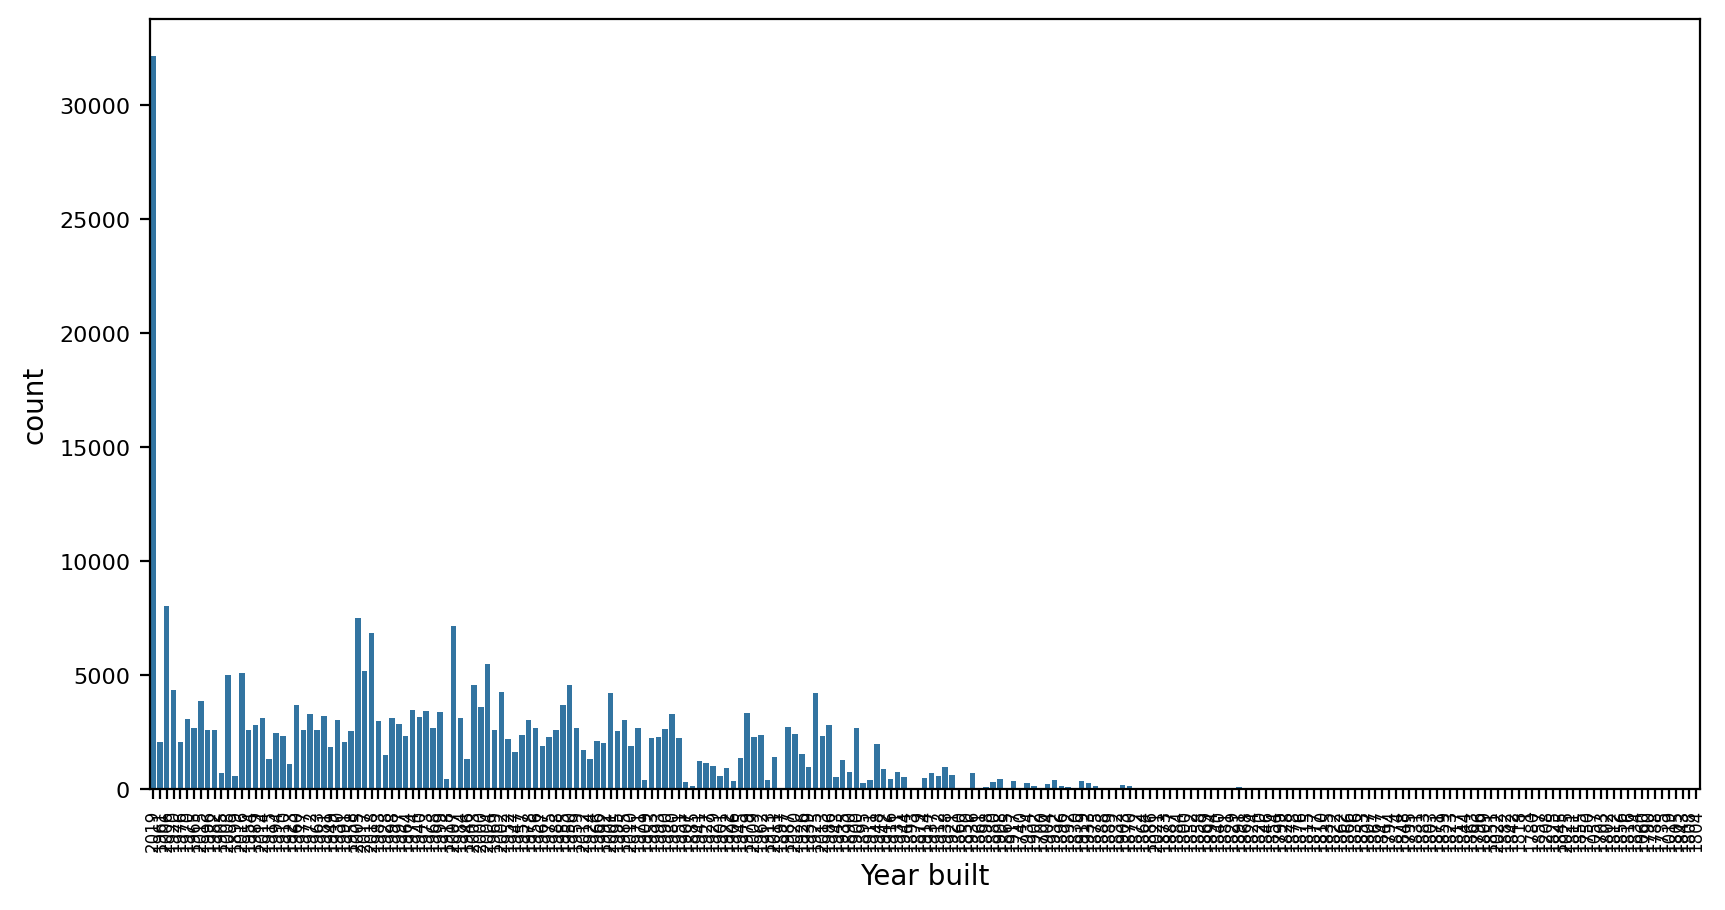

In [369]:
plt.figure(figsize=(10, 5), dpi=200)

sns.countplot(data=df2, x='Year built' )
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=8)

In [370]:
df2['Year built'].describe()

count     313563
unique       227
top         2019
freq       32165
Name: Year built, dtype: object

In [371]:
#Избавляемся от выбросов
df2 = df2.drop(df2[(df2['Year built']<'1800')].index)
df2.reset_index(inplace = True, drop = True)

In [372]:
missing_values_count = df2['Year built'].isna().sum()
total_count = len(df2)
missing_values_percentage = (missing_values_count / total_count) * 100

print(f"Количество пропущенных значений: {missing_values_count}\n"
      f"Процент пропущенных значений: {missing_values_percentage:.2f}%\n"
      f"Количество уникальных значений: {df2['Year built'].nunique()}\n")

Количество пропущенных значений: 63476
Процент пропущенных значений: 16.84%
Количество уникальных значений: 210



(array([    0.,  5000., 10000., 15000., 20000., 25000., 30000., 35000.]),
 [Text(0, 0.0, '0'),
  Text(0, 5000.0, '5000'),
  Text(0, 10000.0, '10000'),
  Text(0, 15000.0, '15000'),
  Text(0, 20000.0, '20000'),
  Text(0, 25000.0, '25000'),
  Text(0, 30000.0, '30000'),
  Text(0, 35000.0, '35000')])

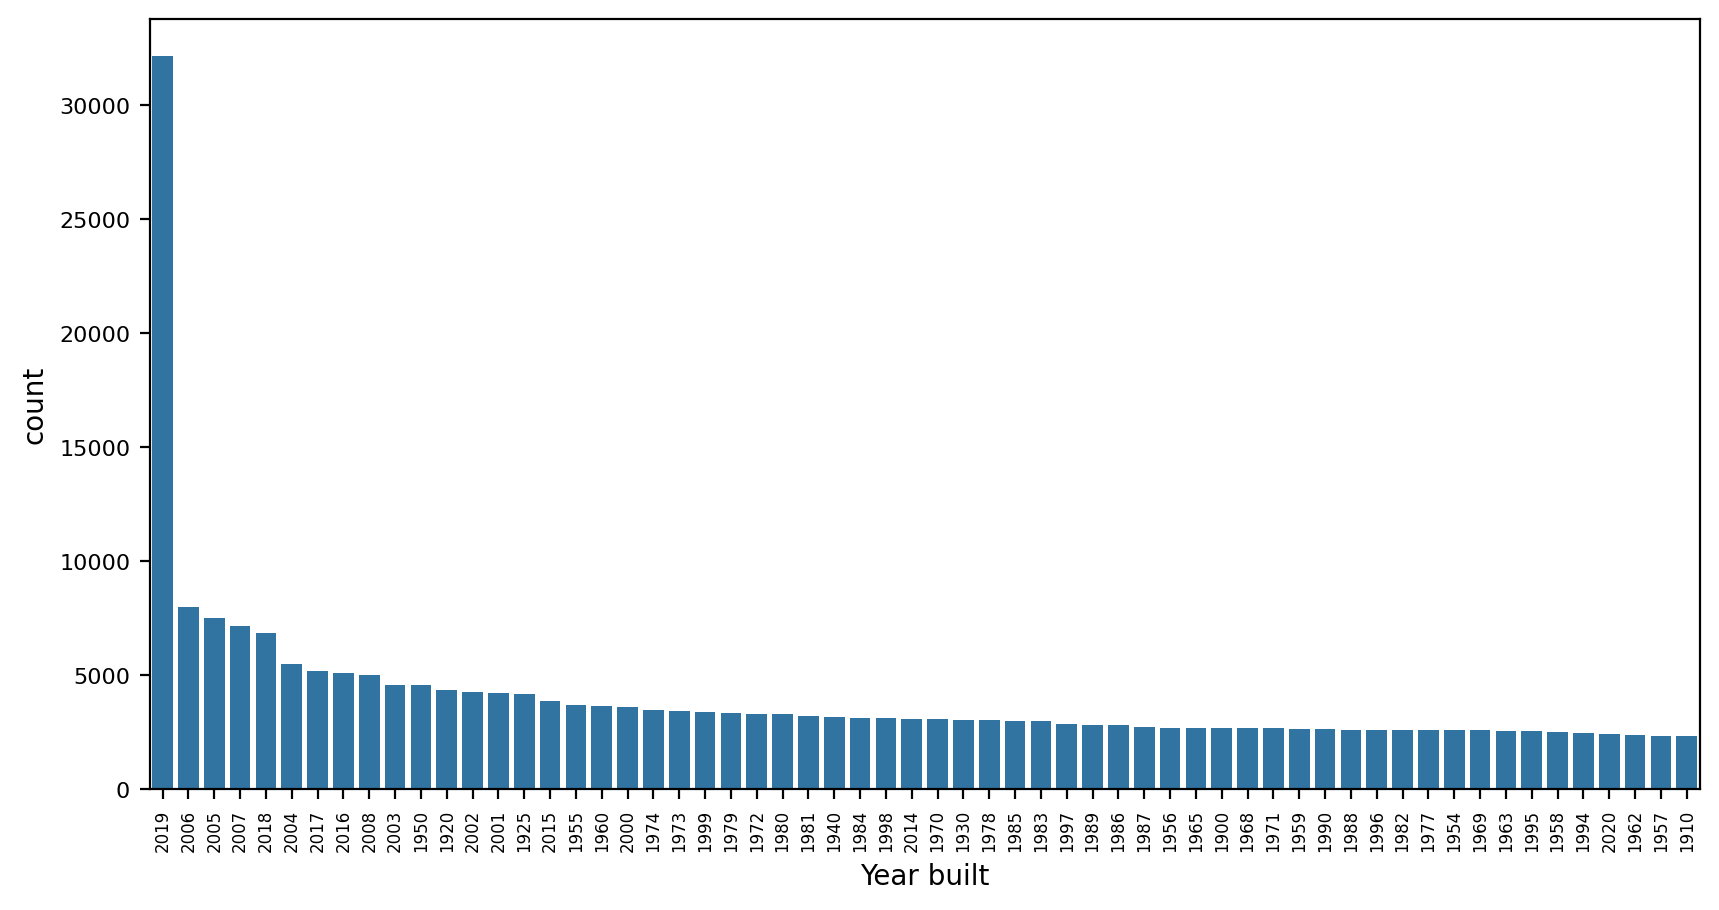

In [373]:
plt.figure(figsize=(10, 5), dpi=200)
top_60_values = df2['Year built'].value_counts().index[:60]
    
sns.countplot(data=df2, x='Year built', order=top_60_values)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=8)
   
    

Заполнить рандомно год постройки мы не можем, оставим пока как есть

### Обработаем признак Remodeled Year (год реконструкции)

In [374]:
print(format(df2['Remodeled year'].unique()))

['' '1967' '2006' None '2015' '1997' '2019' '1982' '1905' '2009' '2007'
 '1996' '1995' '1988' '1972' '1949' '1954' '1930' '2003' '2000' '1994'
 '2005' '1983' '1965' '1968' '1993' '1999' '2014' '2008' '2010' '2004'
 '2002' '1984' '1952' '1978' '1975' '1971' '1947' '1957' '1950' '2012'
 '1973' '1970' '2016' '1989' '1998' '1980' '1986' '1955' '1991' '2011'
 '2017' '1941' '2001' '1990' '1979' '1901' '1918' '1977' '1962' '1956'
 '2013' '1960' '1981' '1969' '1987' '1958' '1910' '1925' '1964' '1966'
 '1992' '1943' '1961' '1948' '1931' '1976' '1974' '1935' '1940' '2018'
 '1916' '1914' '1963' '1985' '1951' '1944' '1942' '1959' '1927' '1946'
 '1945' '1920' '1938' '1936' '0' '1939' '1915' '1928' '1923' '1929' '1898'
 '1899' '1934' '1953' '1926' '1937' '1912' '1917' '1906' '1932' '1919'
 '1921' '1924' '1907' '1911' '1900' '1889' '1913' '1895' '1908' '1903'
 '1904' '1933' '1894' '1892' '1922' '1909' '1880' '1902' '1877' '2020'
 '1893' '1890' '1891' '2021' '1869' '1884' '1897' '1886' '1883' '1846'
 

Половина записей не имеет никакого значения. Возможно, это означает, что задачи по реконструкции не были выполнены. В этом случае закодируем эту характеристику двумя возможными значениями: нет (No) (не были) и да (Yes) (были выполнены).

In [375]:
df2['Remodeled year'] = df2['Remodeled year'].apply(lambda x: 'no' if pd.isnull(x) or x in ['', 0] else 'yes')

(array([     0.,  50000., 100000., 150000., 200000., 250000.]),
 [Text(0, 0.0, '0'),
  Text(0, 50000.0, '50000'),
  Text(0, 100000.0, '100000'),
  Text(0, 150000.0, '150000'),
  Text(0, 200000.0, '200000'),
  Text(0, 250000.0, '250000')])

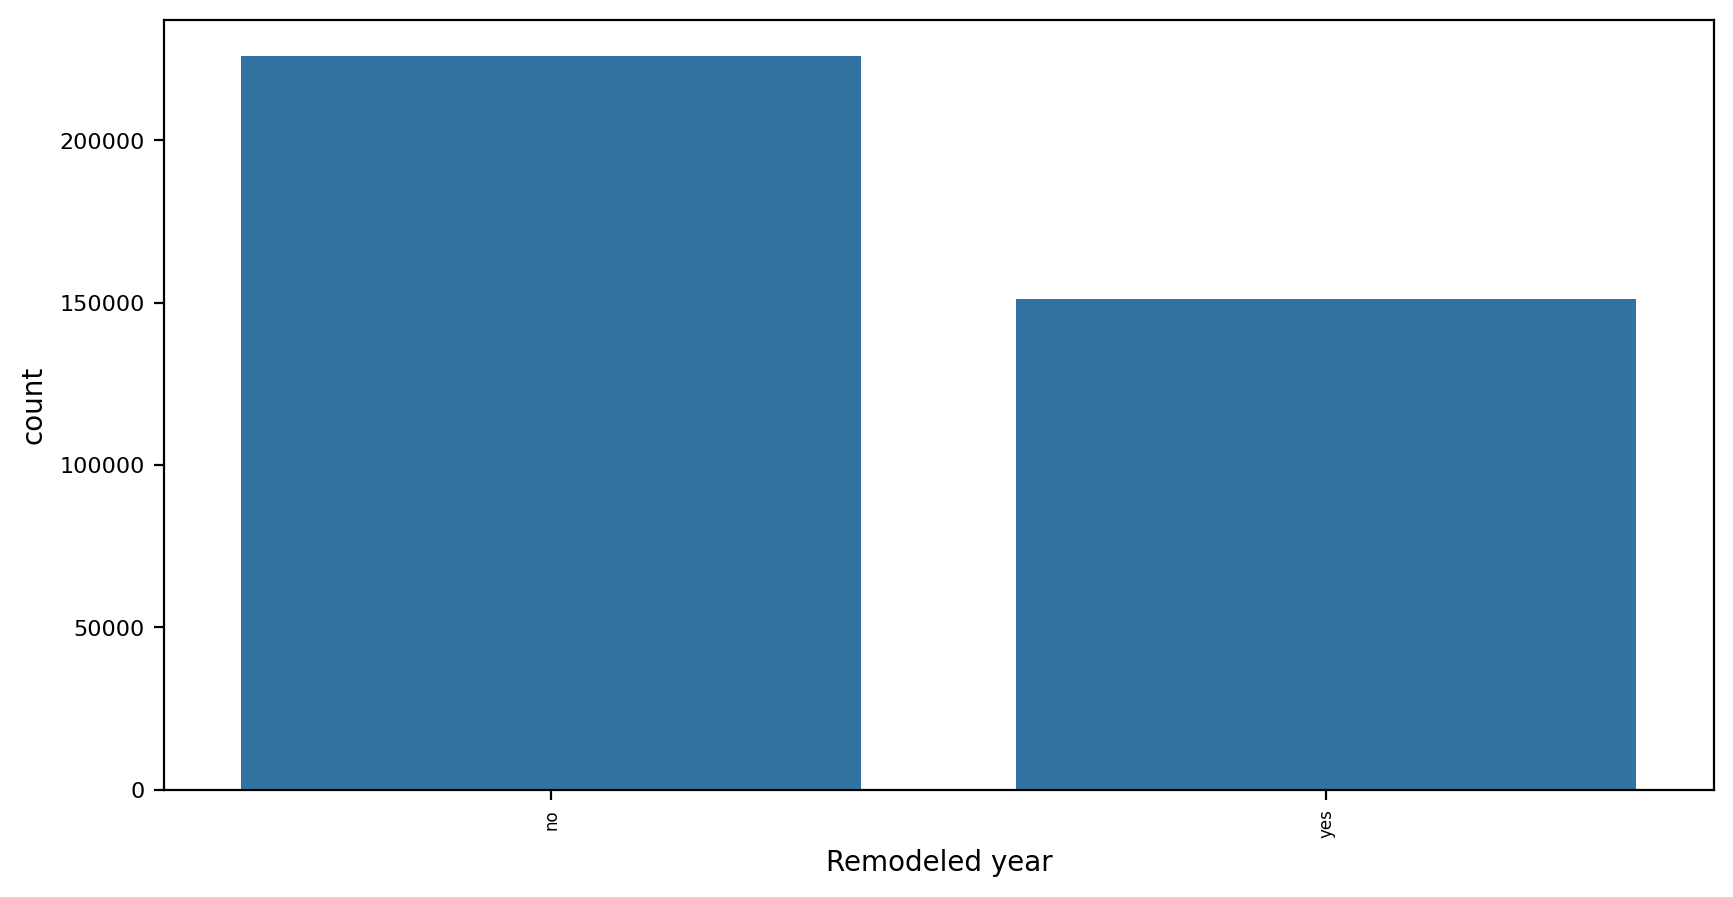

In [376]:
plt.figure(figsize=(10, 5), dpi=200)

sns.countplot(data=df2, x='Remodeled year' )
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=8)

### Обработаем признак heating information (информация об отоплении)

In [377]:
missing_values_count = df2['Heating'].isna().sum()
total_count = len(df2)
missing_values_percentage = (missing_values_count / total_count) * 100

print(f"Количество пропущенных значений: {missing_values_count}\n"
      f"Процент пропущенных значений: {missing_values_percentage:.2f}%\n"
      f"Количество уникальных значений: {df2['Heating'].nunique()}\n")

Количество пропущенных значений: 3533
Процент пропущенных значений: 0.94%
Количество уникальных значений: 1981



In [378]:
df2['Heating'].unique()

array(['Central A/C, Heat Pump', '', 'Forced Air', ...,
       'Electric Furnace, Electric Heat Pump',
       'Floor Furnace, Wall Electric, Wall Gas',
       'Baseboard, Hot Water, Programmable Thermostat, Radiant Floor'],
      dtype=object)

In [379]:
df2['Heating'] = df2['Heating'].fillna('no data')
df2['Heating'] = df2['Heating'].apply(lambda x: 'no data' if x == '' else x)

In [380]:
display(df2['Heating'].str.lower().value_counts().head(10))

Heating
forced air           134301
no data              117802
other                 29620
electric              10216
gas                    9295
heat pump              8851
central air            7814
central electric       7111
central                6247
central, electric      4253
Name: count, dtype: int64

Имеет смысл разделить системы отопления на основные группы, такие как принудительная вентиляция, газовое отопление, тепловые насосы, центральное отопление и электрическое отопление, поскольку стоимость этих видов отопления может значительно различаться.

In [381]:
# Создадим словарь ключевых слов
heating_key_words = ['forced', 'electric', 'gas', 'pump', 'central', 'baseboard', 'radiant']

In [382]:
def replace_heating_status(status):
    for keyword in heating_key_words:
        if keyword in status:
            return keyword
    return 'other'

df2['Heating'] = df2['Heating'].apply(replace_heating_status)

In [383]:
# Посмотрим топ 30 уникальных значений
top_30_Heating = df2['Heating'].value_counts().nlargest(30)

print(top_30_Heating)

Heating
other       372219
pump          4727
electric        44
gas             21
central          1
Name: count, dtype: int64


###  Обработаем признак Cooling

In [384]:
missing_values_count = df2['Cooling'].isna().sum()
total_count = len(df2)
missing_values_percentage = (missing_values_count / total_count) * 100

print(f"Количество пропущенных значений: {missing_values_count}\n"
      f"Процент пропущенных значений: {missing_values_percentage:.2f}%\n"
      f"Количество уникальных значений: {df2['Cooling'].nunique()}\n")

Количество пропущенных значений: 3533
Процент пропущенных значений: 0.94%
Количество уникальных значений: 1445



In [385]:
df2['Cooling'].value_counts().nlargest(30)

Cooling
Central                                            158736
                                                   120291
Central Air                                         14384
No Data                                             10615
Has Cooling                                          9730
None                                                 7389
Central Electric                                     6153
Wall                                                 4016
Central Gas                                          3573
Central Heating                                      2807
Cooling System                                       2699
Central A/C                                          2049
Other                                                1840
Central A/C (Electric), Central Heat (Gas)           1646
Central A/C (Electric), Central Heat (Electric)      1429
Refrigeration                                        1075
Central, Electric                                    1060
Electr

При выводе топ 30 уникальных значений признака 'Cooling' видно, что есть пустое значение признака, но как пропуск это значение не читается. Судя по выводу, статус с частотой 120289 представлен пробелами.

In [386]:
df2['Cooling'] = df2['Cooling'].replace('', 'no data')
df2['Cooling'] = df2['Cooling'].fillna('no data')  # заполняем пропуски

In [387]:
cooling_counts = df2['Cooling'].value_counts()
print(cooling_counts)

Cooling
Central                                                                158736
no data                                                                123824
Central Air                                                             14384
No Data                                                                 10615
Has Cooling                                                              9730
                                                                        ...  
Central Gas, Propane, Zoned                                                 1
Other (See Remarks), Panel/Floor/Wall, Window Unit                          1
Multi Units, Zoned Cooling                                                  1
Central Air, g-Energy Star HVAC, Gas Hot Air/Furnace, Multizone A/C         1
Central A/C (Gas), Central Heat (Gas), Heat Pump                            1
Name: count, Length: 1445, dtype: int64


In [388]:
df2['Cooling'] = df2['Cooling'].str.lower() # Приводим к нижнему регистру

In [389]:
# Удаляем знаки препинания
df2['Cooling'] = df2['Cooling'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

In [390]:
def clean_cooling_data(cooling):
    # определим группы
    patterns = {
        'gas': [
            r'.*\bgas.*\b',
        ],
        'air': [
            r'.*\bair.*\b',
        ],
        'central': [
            r'.*\bcentral.*\b',
        ],
        'no data': [
            r'.*\bno data.*\b',
        ],
    }

    for group, regex_patterns in patterns.items():
        for pattern in regex_patterns:
            if re.match(pattern, cooling, re.IGNORECASE):
                return group

    return 'other'

In [391]:
df2['cooling_info_cleaned'] = df2['Cooling'].apply(clean_cooling_data)

In [392]:
print(format(df2.cooling_info_cleaned.value_counts().head()))

cooling_info_cleaned
central    178098
no data    134439
other       36224
air         17815
gas         10436
Name: count, dtype: int64


(array([     0.,  25000.,  50000.,  75000., 100000., 125000., 150000.,
        175000., 200000.]),
 [Text(0, 0.0, '0'),
  Text(0, 25000.0, '25000'),
  Text(0, 50000.0, '50000'),
  Text(0, 75000.0, '75000'),
  Text(0, 100000.0, '100000'),
  Text(0, 125000.0, '125000'),
  Text(0, 150000.0, '150000'),
  Text(0, 175000.0, '175000'),
  Text(0, 200000.0, '200000')])

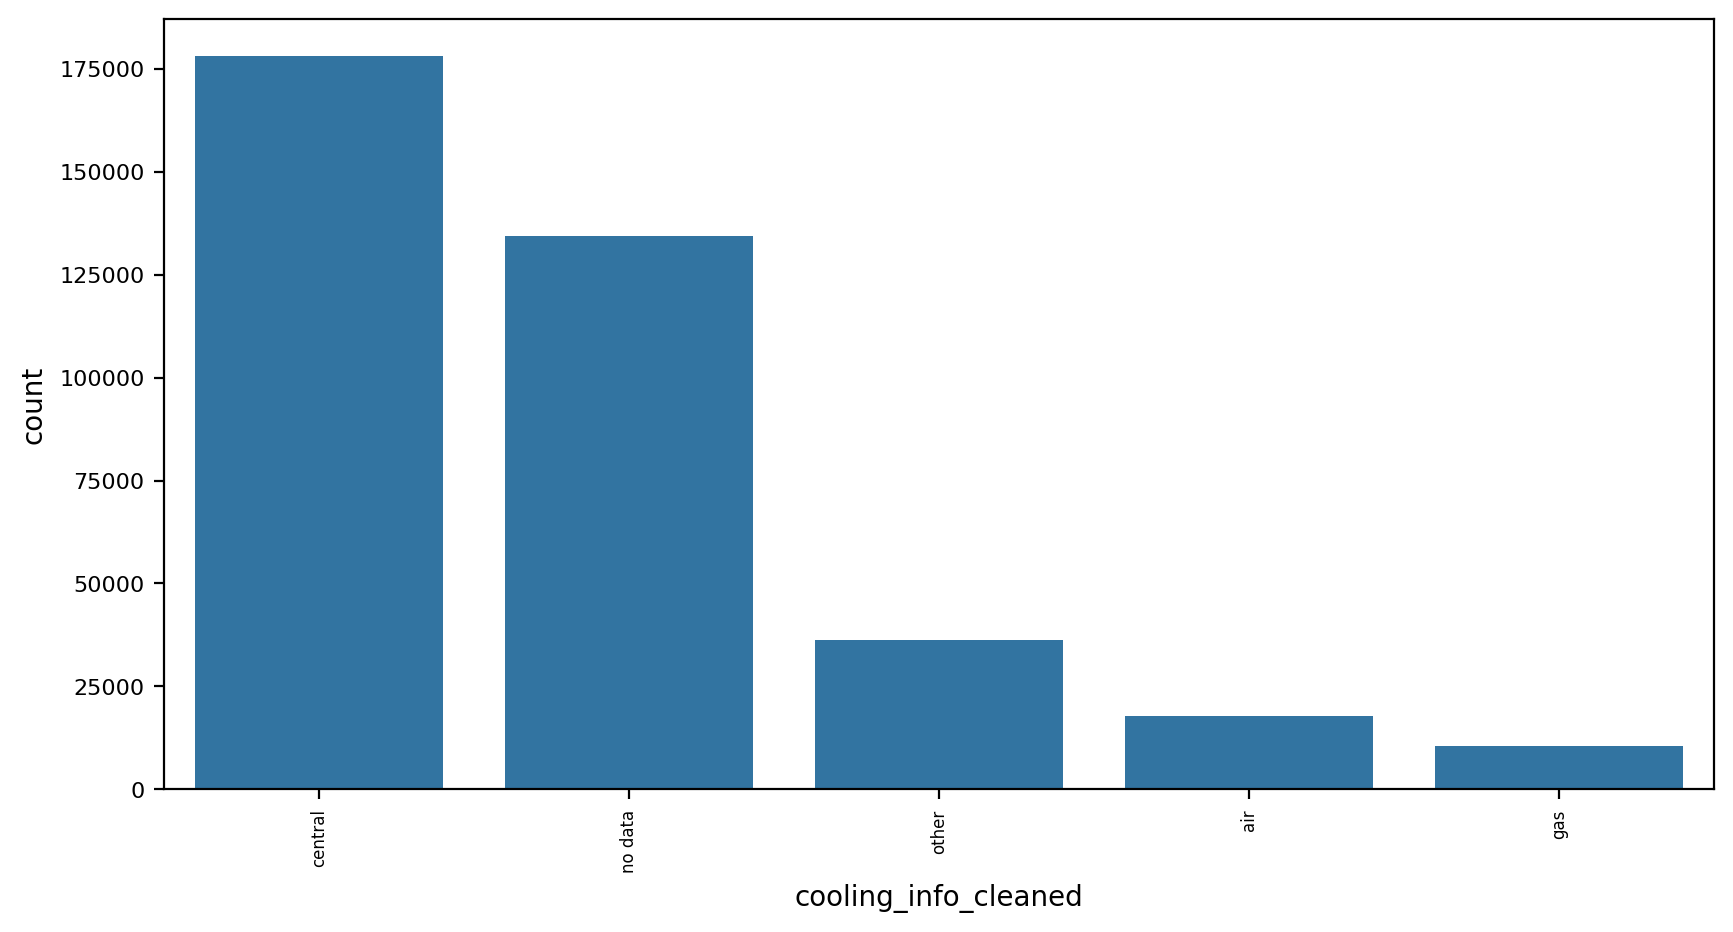

In [393]:
plt.figure(figsize=(10, 5), dpi=200)

sns.countplot(data=df2, x='cooling_info_cleaned',order=df2['cooling_info_cleaned'].value_counts(ascending=False).index )
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=8)

In [394]:
df2.drop(['Cooling'], axis=1, inplace=True)

###  Обработаем признак Parking

In [395]:
missing_values_count = df2['Parking'].isna().sum()
total_count = len(df2)
missing_values_percentage = (missing_values_count / total_count) * 100

print(f"Количество пропущенных значений: {missing_values_count}\n"
      f"Процент пропущенных значений: {missing_values_percentage:.2f}%\n"
      f"Количество уникальных значений: {df2['Parking'].nunique()}\n")

Количество пропущенных значений: 3533
Процент пропущенных значений: 0.94%
Количество уникальных значений: 3345



In [396]:
df2['Parking'] = df2['Parking'].fillna('other') # Заполняем пропуски
df2['Parking'] = df2['Parking'].str.lower() # Приводим к нижнему регистру

# Удаляем знаки препинания
df2['Parking'] = df2['Parking'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

In [397]:
# Посмотрим топ 30 уникальных значений
top_30_parking = df2['Parking'].value_counts().nlargest(30)

print(top_30_parking)

Parking
                                   171739
attached garage                     70747
2 spaces                            28079
1 space                             14252
no data                             13331
detached garage                     13199
carport                              7743
off street                           5279
3 spaces                             4724
other                                3534
carport attached garage              3025
1                                    2936
4 spaces                             2916
2                                    2756
none                                 2368
on street                            1706
attached garage detached garage      1354
0                                    1114
attached garage carport               993
parking desc                          900
6 spaces                              755
detached garage attached garage       726
driveway                              693
5 spaces                  

При выводе топ 30 уникальных значений признака 'Parking' видно, что есть пустое значение признака, но как пропуск это значение не читается. Судя по выводу, статус с частотой 171737 представлен пробелами.

In [398]:
# Заменяем пустые строки на 'other'
df2['Parking'] = df2['Parking'].replace('', 'other')

In [399]:
# Посмотрим топ 30 уникальных значений
top_30_parking = df2['Parking'].value_counts().nlargest(30)

print(top_30_parking)

Parking
other                              175273
attached garage                     70747
2 spaces                            28079
1 space                             14252
no data                             13331
detached garage                     13199
carport                              7743
off street                           5279
3 spaces                             4724
carport attached garage              3025
1                                    2936
4 spaces                             2916
2                                    2756
none                                 2368
on street                            1706
attached garage detached garage      1354
0                                    1114
attached garage carport               993
parking desc                          900
6 spaces                              755
detached garage attached garage       726
driveway                              693
5 spaces                              655
4                         

In [400]:
# Создадим словарь ключевых слов
parking_key_words = ['garage', '1', '2', '3', '4', '5', '6', 'carport', 'off', 'on', 'parking', 'driveway']

In [401]:
def replace_parking_status(status):
    for keyword in parking_key_words:
        if keyword in status:
            return keyword
    return 'other'

df2['Parking'] = df2['Parking'].apply(replace_parking_status)

In [402]:
# Посмотрим топ 30 уникальных значений
top_30_parking = df2['Parking'].value_counts().nlargest(30)

print(top_30_parking)

Parking
other       192866
garage       99395
2            31387
1            17902
carport       8493
off           6808
on            5475
3             5284
4             3615
parking       3074
6              967
driveway       937
5              809
Name: count, dtype: int64


### Обработаем признак lotsize (информация о размере участка)

In [403]:
missing_values_count = df2['lotsize'].isna().sum()
total_count = len(df2)
missing_values_percentage = (missing_values_count / total_count) * 100

print(f"Количество пропущенных значений: {missing_values_count}\n"
      f"Процент пропущенных значений: {missing_values_percentage:.2f}%\n"
      f"Количество уникальных значений: {df2['lotsize'].nunique()}\n")

Количество пропущенных значений: 28342
Процент пропущенных значений: 7.52%
Количество уникальных значений: 37389



In [404]:
df2['lotsize'].str.lower().value_counts().head(10)

lotsize
               33054
—              25246
no data         5329
-- sqft lot     3819
0.26 acres      3140
0.25 acres      2722
0.28 acres      2614
0.27 acres      2473
0.29 acres      2351
0.34 acres      1953
Name: count, dtype: int64

Реально пропусков более 48%. Лучше этот признак удалить, во первых, это площадь участка на котором расположен дом, а во вторых, этот признак числовой и заполнить его адекватно мы не можем.

In [405]:
# удалим признак 'lotsize'
df2 = df2.drop('lotsize', axis=1)

Признак Price/sqft напрямую зависит от целевого признака. Поэтому оставлять его нельзя, иначе будет утечка данных.

In [406]:
# удалим признак 'Price/sqft'
df2= df2.drop('Price/sqft', axis=1)

###  Обработаем признак city

In [407]:
# Приведем названия к единому виду
df2['city'] = df2['city'].str.title()

missing_values_count = df2['city'].isna().sum()
total_count = len(df2)
missing_values_percentage = (missing_values_count / total_count) * 100

print(f"Количество пропущенных значений: {missing_values_count}\n"
      f"Процент пропущенных значений: {missing_values_percentage:.2f}%\n"
      f"Количество уникальных значений: {df2['city'].nunique()}\n")

Количество пропущенных значений: 32
Процент пропущенных значений: 0.01%
Количество уникальных значений: 1909



In [408]:
df2['city'].str.lower().value_counts().sort_index().head(10)


city
             25
--            9
abilene     134
abingdon    115
accokeek      3
adams         5
addison      25
adel         13
adelphi       6
advance       3
Name: count, dtype: int64

In [409]:
initial_row_count = df2.shape[0]
#удаляем строки, содержащие ' ', '--' или NaN в столбце 'city'
df2 = df2[~df2['city'].isin([' ', '--', np.nan])]

#подсчитываем количество удаленных строк
removed_row_count = initial_row_count - df2.shape[0]

print(f"Количество удаленных строк: {removed_row_count}")

Количество удаленных строк: 66


In [410]:
df2.drop('homeFacts', axis = 1, inplace = True)

(array([    0.,  5000., 10000., 15000., 20000., 25000., 30000.]),
 [Text(0, 0.0, '0'),
  Text(0, 5000.0, '5000'),
  Text(0, 10000.0, '10000'),
  Text(0, 15000.0, '15000'),
  Text(0, 20000.0, '20000'),
  Text(0, 25000.0, '25000'),
  Text(0, 30000.0, '30000')])

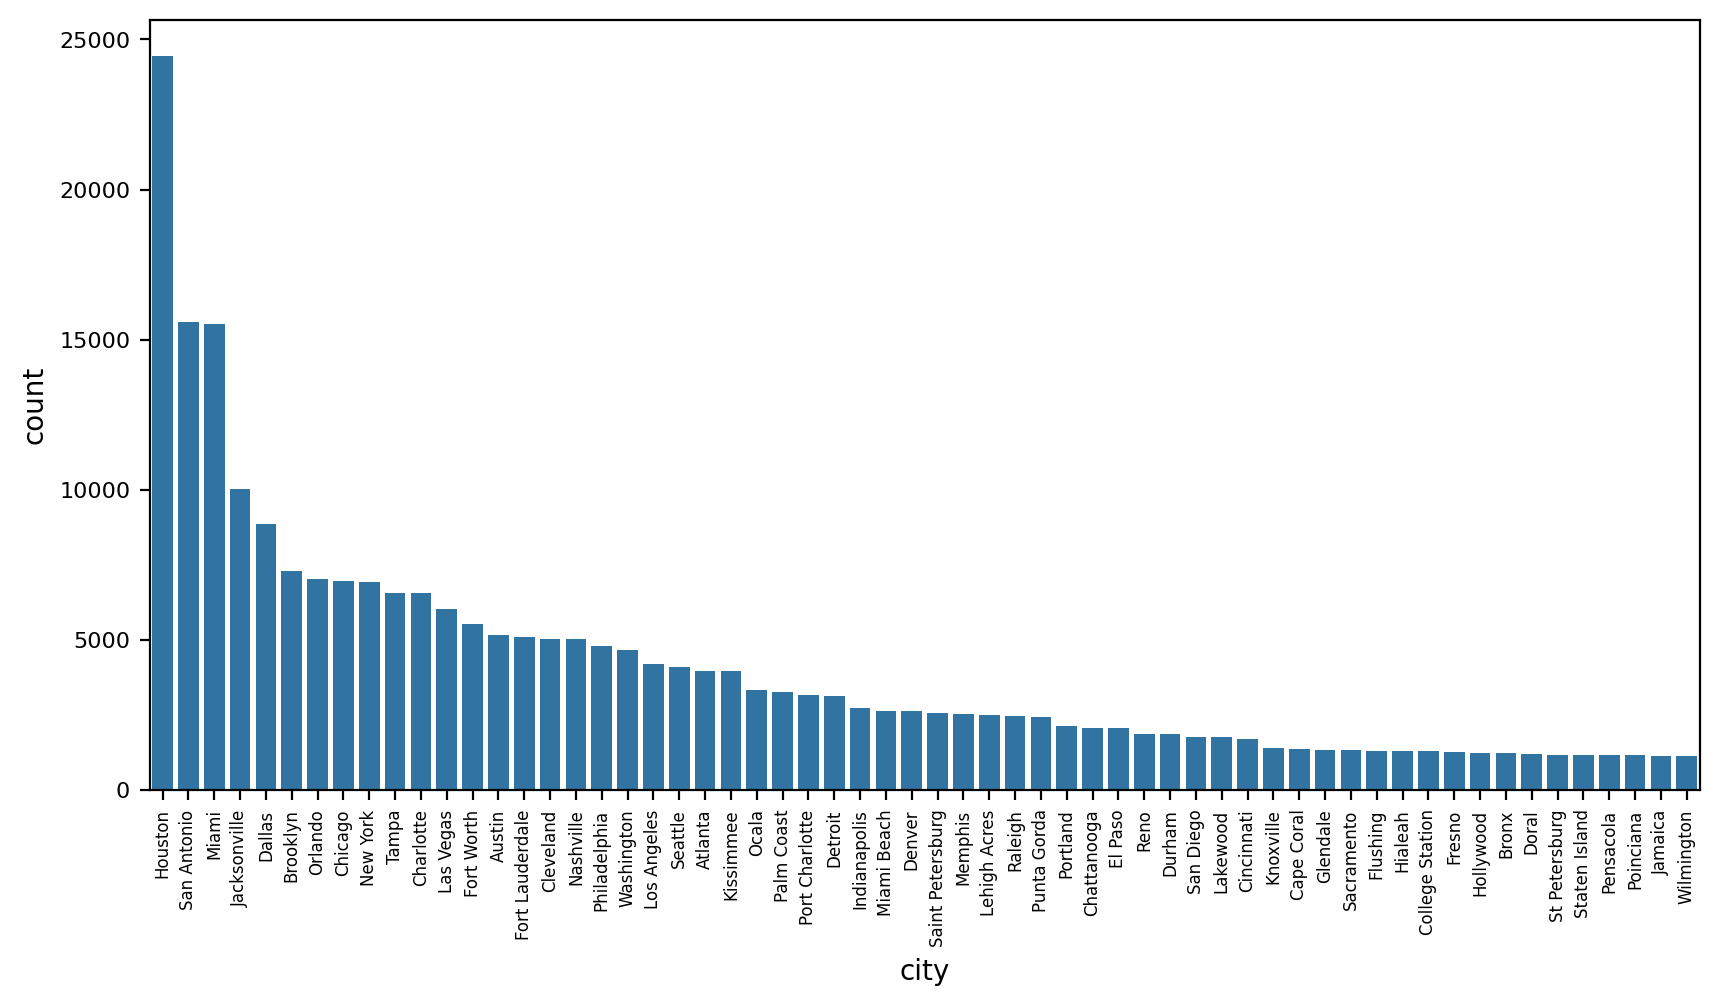

In [411]:
plt.figure(figsize=(10, 5), dpi=200)
top_60_values = df2['city'].value_counts().index[:60]
sns.countplot(data=df2, x='city',order=top_60_values)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=8)

### Обработаем признак Schools

In [412]:
df2['schools']

0         [{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...
1         [{'rating': ['4/10', 'None/10', '4/10'], 'data...
2         [{'rating': ['8/10', '4/10', '8/10'], 'data': ...
3         [{'rating': ['9/10', '9/10', '10/10', '9/10'],...
4         [{'rating': ['4/10', '5/10', '5/10'], 'data': ...
                                ...                        
377007    [{'rating': ['10/10', '5/10'], 'data': {'Dista...
377008    [{'rating': ['1/10', '5/10', '7/10'], 'data': ...
377009    [{'rating': ['5/10', '4/10'], 'data': {'Distan...
377010    [{'rating': ['NA', 'NA', 'NA'], 'data': {'Dist...
377011    [{'rating': ['5/10', '4/10', '3/10'], 'data': ...
Name: schools, Length: 376946, dtype: object

Если посмотреть на данные, то в них есть рейтинги школ, расстояние, уровень образования и расстояние до каждой школы.

Этот фактор довольно специфичен и может быть как плюсом, если молодая пара ищет жилье, так и минусом, если дом предназначен для пожилой пары.

Фактор сложен для интерпретации, попробуем его удалить.

In [413]:
df2.drop('schools', axis = 1, inplace = True)

### Обработаем признак sqft- площадь

In [414]:
missing_values_count = df2['sqft'].isna().sum()
total_count = len(df2)
missing_values_percentage = (missing_values_count / total_count) * 100

print(f"Количество пропущенных значений: {missing_values_count}\n"
      f"Процент пропущенных значений: {missing_values_percentage:.2f}%\n"
      f"Количество уникальных значений: {df2['sqft'].nunique()}\n")

Количество пропущенных значений: 40516
Процент пропущенных значений: 10.75%
Количество уникальных значений: 25395



In [415]:
df2['sqft'].value_counts().head(10)

sqft
0             11790
1,200 sqft      839
1,000 sqft      654
1,100 sqft      573
1,800 sqft      563
1,500 sqft      547
--              534
2,000 sqft      523
1,400 sqft      517
1,600 sqft      455
Name: count, dtype: int64

In [416]:
def sqft_preprocessing(x):
    #Избавляемся от ненужных символов
    x = str(x)
    x = x.replace(',', '')
    #Достаем нужное значение
    x = re.search(r'\d*', x).group(0)
    if x:
        return float(x)
    else:
        return None
    
df2['sqft'] = df2['sqft'].apply(sqft_preprocessing)

print('Процент пропусков в признаке sqft: {}'.format(round(df2['sqft'].isnull().mean() * 100, 2)))

df2['sqft'].describe()

Процент пропусков в признаке sqft: 17.25


count    3.119380e+05
mean     6.956822e+03
std      1.643234e+06
min      0.000000e+00
25%      1.235000e+03
50%      1.799000e+03
75%      2.589000e+03
max      7.959794e+08
Name: sqft, dtype: float64

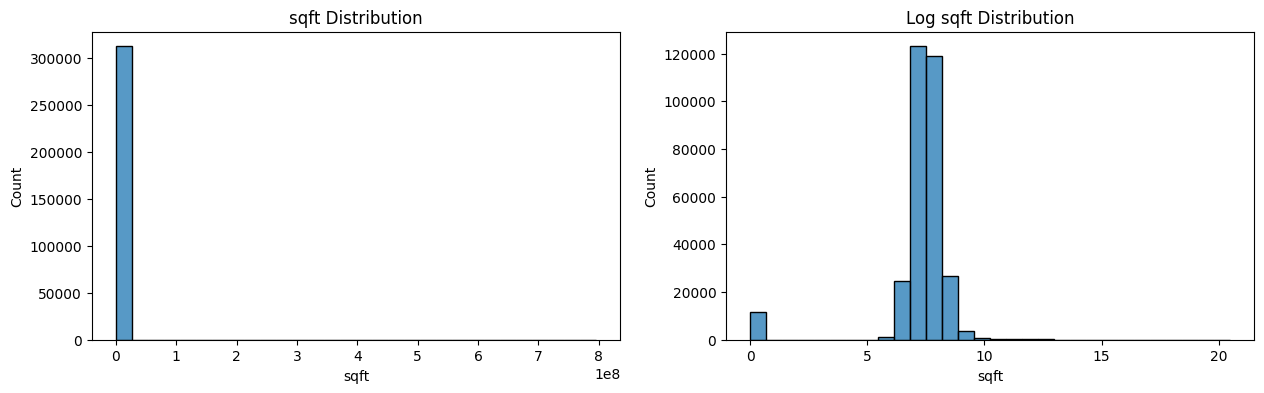

In [417]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

#гистограмма исходного признака
histplot = sns.histplot(df2['sqft'], bins=30, ax=axes[0])
histplot.set_title('sqft Distribution');

#гистограмма в логарифмическом масштабе
log_sqft= np.log(df2['sqft'] + 1)
histplot = sns.histplot(log_sqft , bins=30, ax=axes[1])
histplot.set_title('Log sqft Distribution');

График показывает, что у нас нет нормального распределения, и разброс данных очень велик, что может существенно повлиять на модель. Необходимо преобразовать данные в более нормальное распределение и удалить выбросы.

Странным является то, что площадь может быть нулевой, давайте посмотрим, сколько таких наблюдений.

In [418]:
df2[df2['sqft'] == 0]['sqft'].count()

11790

In [419]:
df3 = df2.copy()

In [420]:
def tukey_method(data, feature, right=1.5, left=1.5, log_scale=False):
    """Функция для удаления выбросов с помощью метода Тьюки

    Args:
        data (pandas.core.frame.DataFrame): Датафрейм с нашими данными
        feature (str): Признак, который мы хотим очистить
        right (float, optional): Для усов в право. Defaults to 1.5.
        left (float, optional): Длина усов в лево. Defaults to 1.5.
        log_scale (bool, optional): Индикатор, который отвечает за логарифмирование данных. Defaults to False.
    """
    if log_scale: #Логарифмируем данные, если требуется
        X = np.log(data[feature] + 1)
    else:
        X = data[feature]
    #Рассчитываем квантили
    quantile_1 = X.quantile(0.25)
    quantile_2 = X.quantile(0.75)
    #Считаем межквартильный размах
    iqr = quantile_2 - quantile_1
    #Находим верхнюю и нижнюю границы
    lower_bound = quantile_1 - left * iqr
    upper_bound = quantile_2 + right * iqr
    #Очищаем данные
    outliers = data[(X < lower_bound) | (X > upper_bound)]
    data_cleaned = data[(X >= lower_bound) & (X <= upper_bound)]
    return  outliers, data_cleaned

In [421]:
def outliers_z_score(data, feature, log_scale=True, left=3, right=3.5):
    # функция z_score
    if log_scale:
        x = np.log(data[feature]+1)
    else:
        x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - 3 * sigma
    upper_bound = mu + 3 * sigma
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

In [422]:
outliers, data_cleaned = tukey_method(df3, 'sqft', log_scale=True)
print(f'Число выбросов по методу Тьюки: {outliers.shape[0]}')
#print(f'Результирующее число записей: {cleaned.shape[0]}')

Число выбросов по методу Тьюки: 17182


Text(0.5, 1.0, 'sqft Тьюки')

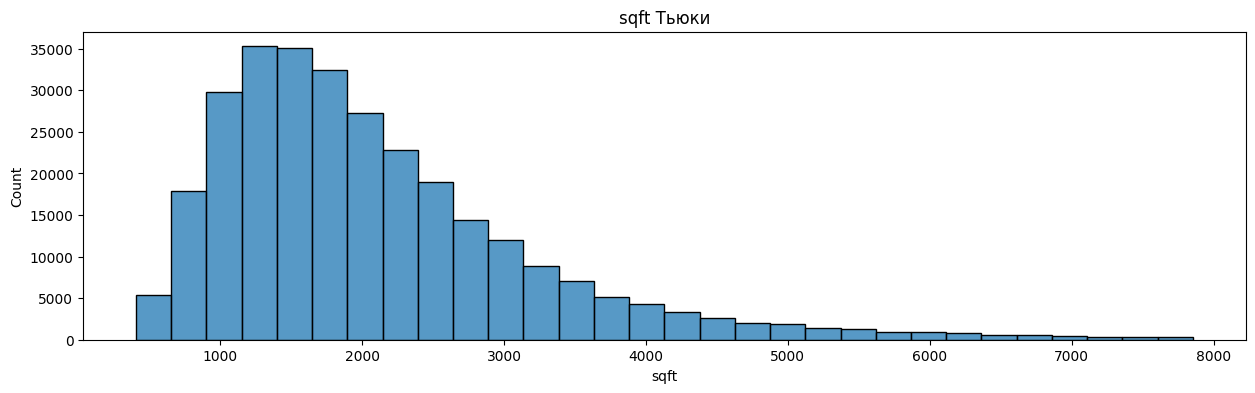

In [423]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
#гистограмма Тьюки
histplot = sns.histplot(data_cleaned['sqft'], bins=30)
histplot.set_title('sqft Тьюки')


In [424]:
data_cleaned['sqft'] = data_cleaned.groupby(['baths', 'bedsCleaned', 'Type'])['sqft'].transform(lambda x: x.fillna(x.median()))
data_cleaned['sqft'] = data_cleaned['sqft'].round()
data_cleaned['sqft'].isnull().sum()

C:\Users\Анечка\AppData\Local\Temp\ipykernel_31136\1712725127.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['sqft'] = data_cleaned.groupby(['baths', 'bedsCleaned', 'Type'])['sqft'].transform(lambda x: x.fillna(x.median()))
C:\Users\Анечка\AppData\Local\Temp\ipykernel_31136\1712725127.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['sqft'] = data_cleaned['sqft'].round()


0

### Обработаем признак state

In [425]:
print(f"Количество пропущенных значений: {data_cleaned.state.isna().sum()}\n"
      f"Количество уникальных значений: {data_cleaned.state.nunique()}\n"
      f"Уникальные значения: {list(data_cleaned.state.unique()[:10])}")

Количество пропущенных значений: 0
Количество уникальных значений: 36
Уникальные значения: ['NC', 'WA', 'CA', 'TX', 'PA', 'FL', 'IA', 'NY', 'DC', 'NV']


In [426]:
data_cleaned

,status,street,baths,city,sqft,state,target,pool_encoded,Type,bedsCleaned,Year built,Remodeled year,Heating,Parking,cooling_info_cleaned
0,Active,240 Heather Ln,4.0,Southern Pines,2900.0,NC,"$418,000",False,single_family_home,4.0,2019,no,other,other,no data
1,For Sale,12911 E Heroy Ave,3.0,Spokane Valley,1947.0,WA,"$310,000",False,single_family_home,3.0,2019,no,other,other,no data
2,For Sale,2005 Westridge Rd,2.0,Los Angeles,3000.0,CA,"$2,895,000",True,single_family_home,3.0,1961,yes,other,garage,central
3,For Sale,4311 Livingston Ave,8.0,Dallas,6457.0,TX,"$2,395,000",False,single_family_home,5.0,2006,yes,other,garage,central
5,For Sale,1624 S Newkirk St,no data,Philadelphia,897.0,PA,"$209,000",False,townhouse,2.0,1920,no,other,other,central
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377006,For Sale,2238 11th St NW APT 2,3.0,Washington,1417.0,DC,"$799,000",False,condo,2.0,2010,no,other,1,central
377007,Other,20800 NE 23rd Ave,6.0,Miami,4017.0,FL,"$1,249,000",True,single_family_home,5.0,1990,yes,other,2,central
377008,For Sale,3530 N Lake Shore Dr #4B,3.0,Chicago,2000.0,IL,"$674,999",False,condo,3.0,1924,no,other,on,no data
377009,For Sale,15509 Linden Blvd,3.0,Jamaica,1152.0,NY,"$528,000",False,single_family_home,3.0,1950,yes,other,2,no data


Заполним пропущенные данные о годе постройки мединнным значением года постройки домов, объединенных по городу и штату

In [427]:
data_cleaned['Year built'] = pd.to_numeric(data_cleaned['Year built'], errors='coerce')
data_cleaned['Year built'] = data_cleaned.groupby(['city', 'state'])['Year built'].transform(lambda x: x.fillna(x.median()))
data_cleaned['Year built'].isnull().sum()
# оставшиеся пропуски заменим мединным значением
data_cleaned['Year built'] = data_cleaned['Year built'].fillna(data_cleaned['Year built'].median())
data_cleaned['Year built'] = data_cleaned['Year built'].round()
data_cleaned['Year built'].isnull().sum()

C:\Users\Анечка\AppData\Local\Temp\ipykernel_31136\418864607.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Year built'] = pd.to_numeric(data_cleaned['Year built'], errors='coerce')
C:\Users\Анечка\AppData\Roaming\Python\Python310\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\Анечка\AppData\Roaming\Python\Python310\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\Анечка\AppData\Roaming\Python\Python310\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=k

0

(array([    0.,  5000., 10000., 15000., 20000., 25000., 30000., 35000.]),
 [Text(0, 0.0, '0'),
  Text(0, 5000.0, '5000'),
  Text(0, 10000.0, '10000'),
  Text(0, 15000.0, '15000'),
  Text(0, 20000.0, '20000'),
  Text(0, 25000.0, '25000'),
  Text(0, 30000.0, '30000'),
  Text(0, 35000.0, '35000')])

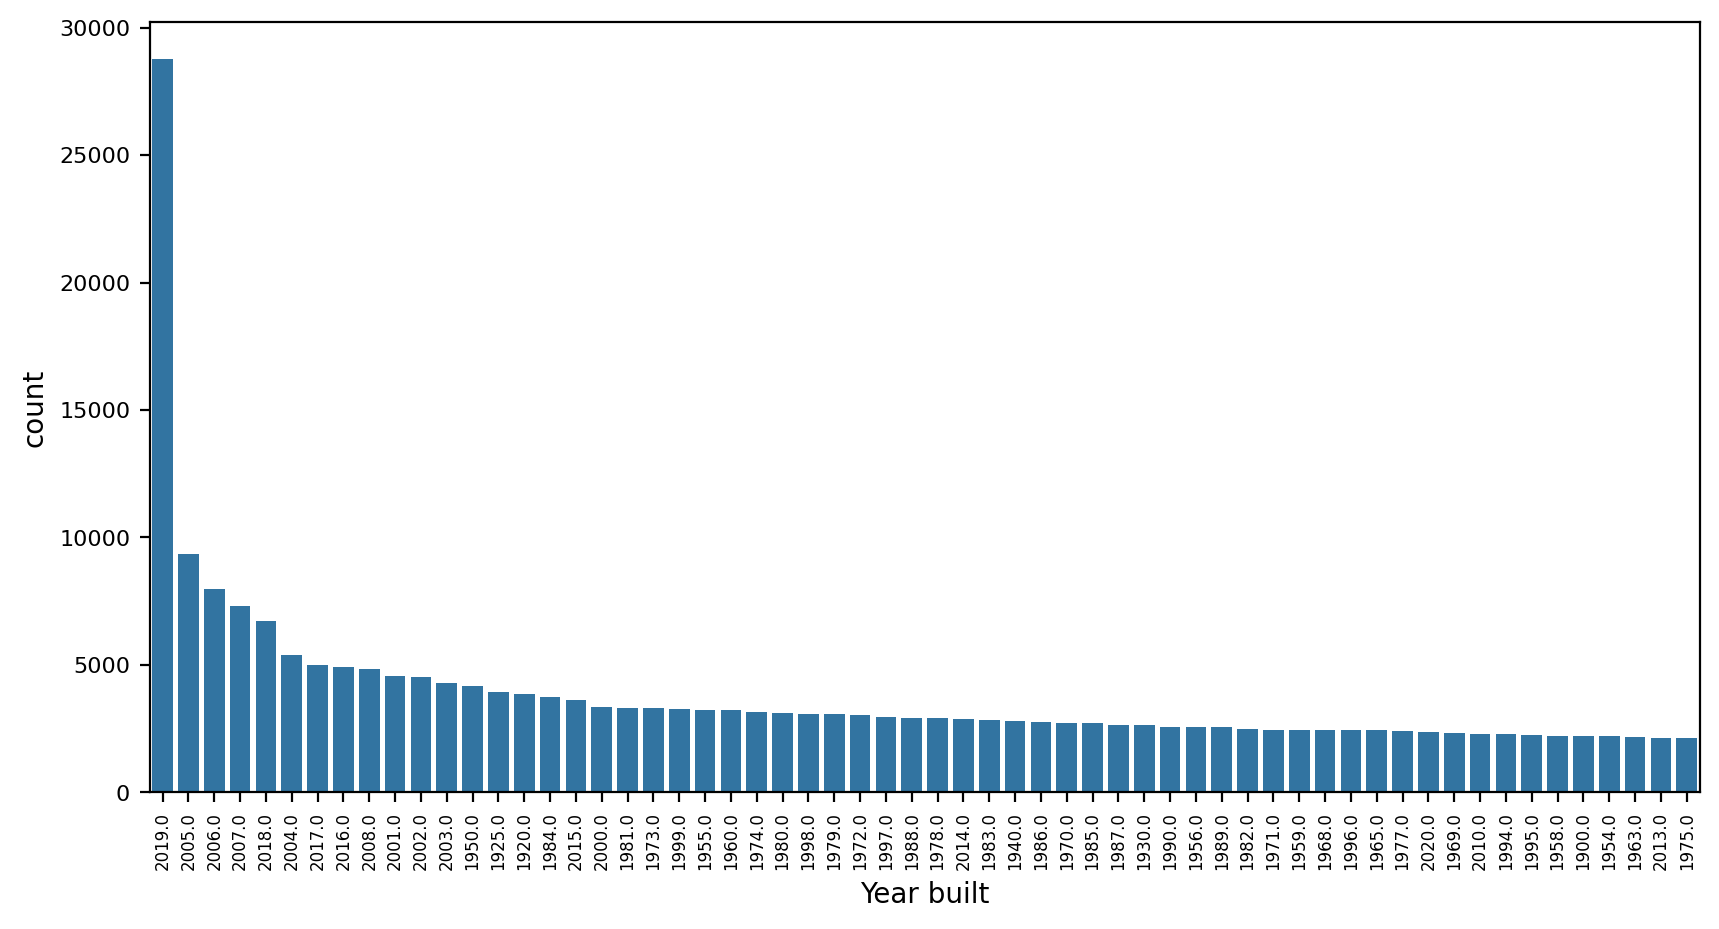

In [428]:
plt.figure(figsize=(10, 5), dpi=200)
top_60_values = data_cleaned['Year built'].value_counts().index[:60]
    
sns.countplot(data=data_cleaned, x='Year built', order=top_60_values)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=8)
   

так же поступим с площадью здания, объединив по количеству ванн и спален.


In [429]:
# data_cleaned['sqft'] = data_cleaned.groupby(['baths', 'bedsCleaned', 'Type'])['sqft'].transform(lambda x: x.fillna(x.median()))
# data_cleaned['sqft'] = data_cleaned['sqft'].round()
# data_cleaned['sqft'].isnull().sum()

### Теперь посмотрим целевой признак target

In [430]:
# выполним проверку
missing_values_count = data_cleaned['target'].isna().sum()
total_count = len(data_cleaned)
missing_values_percentage = (missing_values_count / total_count) * 100

print(f"Количество пропущенных значений: {missing_values_count}\n"
f"Процент пропущенных значений: {missing_values_percentage:.2f}%\n"
f"Количество уникальных значений: {df2['target'].nunique()}\n"
f"Уникальные значения: {list(df2['target'].unique()[:10])}")

Количество пропущенных значений: 1656
Процент пропущенных значений: 0.56%
Количество уникальных значений: 43935
Уникальные значения: ['$418,000', '$310,000', '$2,895,000', '$2,395,000', '$5,000', '$209,000', '181,500', '68,000', '$244,900', '$311,995']


In [431]:
list(data_cleaned['target'])

['$418,000',
 '$310,000',
 '$2,895,000',
 '$2,395,000',
 '$209,000',
 '181,500',
 '$244,900',
 '$311,995',
 '$669,000',
 '260,000',
 '$525,000',
 '$168,800',
 '335,000',
 '2,650,000',
 '$365,000',
 '$626,000',
 '$375,000',
 '579,000',
 '$499,007',
 '$182,000',
 '$3,749,000',
 '$499,900',
 '$559,000',
 '$830,000',
 '$1,195,000',
 '$204,800',
 '$179,000',
 '$105,000',
 '$260,000',
 '$284,900',
 '$495,000',
 '$385,000',
 '$620,000',
 '$125,000',
 '$499,000',
 '$233,990+',
 '$598,000',
 '$1,780,000',
 '$490,000',
 '$175,000',
 '$2,785,000',
 '$259,658',
 '$799,000',
 '$244,990',
 '$333,543',
 nan,
 '$369,900',
 '$409,069',
 '$149,999',
 '$220,000',
 '$749,000',
 '$255,000',
 '$269,000',
 '$475,000',
 '219,900',
 '$1,785,000',
 '$414,900',
 '$1,795,000',
 '$339,000',
 '$916,900',
 '650,000',
 '$399,000',
 '$289,000',
 '$299,999',
 '$439,000',
 '$304,900',
 '$160,000',
 '$259,900',
 '$715,000',
 '$235,900',
 '$189,900',
 '138,500',
 '$229,000',
 '$493,999',
 '$331,990+',
 '800,000',
 '$74,90

In [432]:
# Удалим строки с пропусками 
data_cleaned = data_cleaned.dropna(subset=['target'])

In [433]:
data_cleaned['target'].isna().sum()

0

In [434]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 293100 entries, 0 to 377011
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   status                293100 non-null  object 
 1   street                293100 non-null  object 
 2   baths                 293100 non-null  object 
 3   city                  293100 non-null  object 
 4   sqft                  293100 non-null  float64
 5   state                 293100 non-null  object 
 6   target                293100 non-null  object 
 7   pool_encoded          293100 non-null  bool   
 8   Type                  293100 non-null  object 
 9   bedsCleaned           293100 non-null  object 
 10  Year built            293100 non-null  float64
 11  Remodeled year        293100 non-null  object 
 12  Heating               293100 non-null  object 
 13  Parking               293100 non-null  object 
 14  cooling_info_cleaned  293100 non-null  object 
dtypes: bo

In [435]:
has_letters = data_cleaned['target'].astype(str).str.contains(r'[a-zA-Zа-яА-Я]', na=False)

# Выводит количество таких строк
print(f"Количество строк с буквами: {has_letters.sum()}")

# Показывает сами эти строки (если они есть)
data_cleaned[has_letters]

Количество строк с буквами: 383


,status,street,baths,city,sqft,state,target,pool_encoded,Type,bedsCleaned,Year built,Remodeled year,Heating,Parking,cooling_info_cleaned
547,For rent,4323 N Central Park Ave,4.0,Chicago,3300.0,IL,"$5,500/mo",False,single_family_home,4.0,1913.0,no,other,garage,no data
609,For rent,220 Boylston St #1412,2.0,Boston,1673.0,MA,"$10,500/mo",False,multi_family_home,2.0,1985.0,no,other,other,no data
2074,For rent,2830 NE 56th Ct,4.0,Fort Lauderdale,2400.0,FL,"$6,390/mo",True,single_family_home,4.0,1965.0,no,other,other,no data
3023,For rent,411 Kline Aly,2.0,Clarksville,1280.0,TN,"$1,200/mo",False,multi_family_home,2.0,2014.0,no,other,other,no data
3643,For rent,240 E Illinois St #2011,2.0,Chicago,1473.0,IL,"$3,600/mo",True,multi_family_home,2.0,2003.0,no,other,garage,no data
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371622,For rent,9436 Turrentine Dr,2.0,El Paso,1050.0,TX,$890/mo,False,multi_family_home,2.0,2011.0,no,other,other,no data
372289,For rent,34 Jonquil Pl,2.0,The Woodlands,2601.0,TX,"$2,500/mo",False,townhouse,3.0,2014.0,no,other,garage,no data
374117,For rent,8864 Devonshire Dr,2.0,Fort Worth,2000.0,TX,"$2,000/mo",False,single_family_home,4.0,2016.0,no,other,other,no data
375378,For rent,2217 W Seybert St,no data,Philadelphia,720.0,PA,"$1,500/mo",False,townhouse,2.0,1920.0,no,other,other,no data


Это значения, указывающие, что это плата за месяц (с приставкой /мо), а, следовательно, это аренда.

In [436]:
percent_matching = (has_letters.sum()/ len(data_cleaned)) * 100
print('{}% строк содержат подстроку "/mo" в столбце "target".'.format(round(percent_matching, 2)))

0.13% строк содержат подстроку "/mo" в столбце "target".


Поскольку стоит задача спрогнозировать именно стоимость Недвижимости, а не стоимость аренды, и принимая во внимание, что таких строк всего 0.11%, эти строки лучше удалить, так как они будут давать погрешность.

In [437]:
data_cleaned=data_cleaned[~data_cleaned['target'].str.contains('/mo', regex=True)]

In [438]:
#Теперь удалим все символы кроме цифр и переведем в числовой формат
data_cleaned.loc[:,'target'] = data_cleaned.loc[:,'target'].str.replace('[^0-9]','',regex=True)
data_cleaned.target = data_cleaned.target.astype(int)

In [439]:
display(data_cleaned[data_cleaned['target'] == data_cleaned['target']. min ()].head())
display(data_cleaned[data_cleaned['target'] == data_cleaned['target']. max ()].head())

,status,street,baths,city,sqft,state,target,pool_encoded,Type,bedsCleaned,Year built,Remodeled year,Heating,Parking,cooling_info_cleaned
15531,Active,1230 Old Dickerson Rd,2.0,Goodlettsville,1596.0,TN,1,False,single_family_home,3.0,1940.0,no,other,other,no data
25331,Other,3205 N High School Rd,1.0,Indianapolis,1586.0,IN,1,False,single_family_home,3.0,1957.0,yes,other,garage,central
84934,Closed,7804 Hamilton Ave,no data,Cincinnati,2536.0,OH,1,False,land,6.0,1865.0,no,other,garage,central
252537,Active,114 S Washington St,no data,Circleville,1771.0,OH,1,False,single_family_home,no data,1920.0,no,other,other,gas
256099,Other,9115 Sea Oats Dr,3.0,Indianapolis,1780.0,IN,1,False,condo,3.0,1989.0,yes,other,1,central


,status,street,baths,city,sqft,state,target,pool_encoded,Type,bedsCleaned,Year built,Remodeled year,Heating,Parking,cooling_info_cleaned
354110,For Sale,1441 Angelo Dr,no data,Beverly Hills,741.0,CA,110000000,False,land,no data,2007.0,no,other,other,other


In [440]:
data_cleaned.target.describe()

count    2.927170e+05
mean     5.848705e+05
std      1.124912e+06
min      1.000000e+00
25%      2.150000e+05
50%      3.399000e+05
75%      5.899000e+05
max      1.100000e+08
Name: target, dtype: float64

Целевая переменная имеет очень большой разброс значений, давайте посмотрим на распределение этого признака.

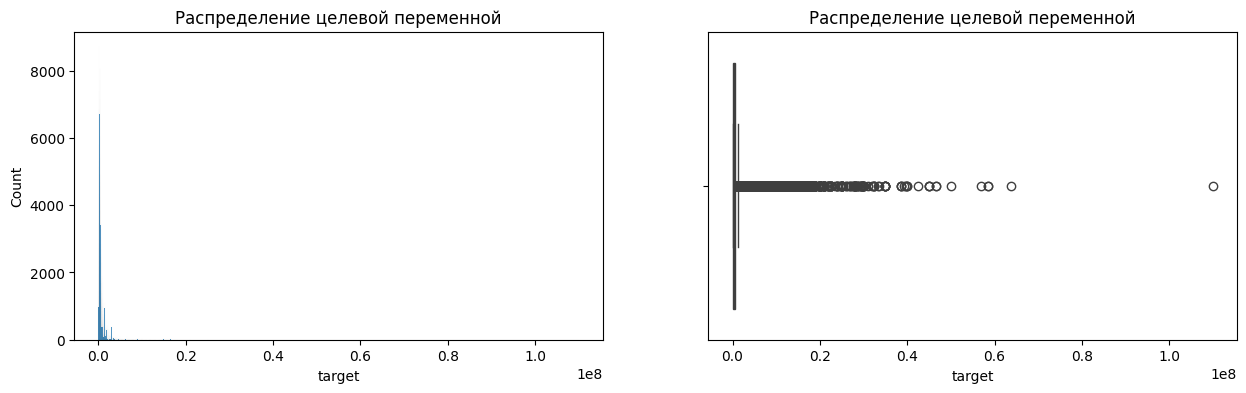

In [441]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=data_cleaned, x='target', ax=axes[0]);
histplot.set_title('Распределение целевой переменной');
boxplot = sns.boxplot(data=data_cleaned, x='target', ax=axes[1]);
boxplot.set_title('Распределение целевой переменной');

Некоторые записи имеют значение меньше 1000 USD, удалим их

In [442]:
data_cleaned = data_cleaned[data_cleaned.target>1000]

Проверим целевой признак на нормальность, используя тест Шапиро-Уилка.

In [443]:
alpha = 0.05
# проводим тест Шапиро — Уилка
_, p = stats.shapiro(data_cleaned['target']);
print('p-value = %.3f' % (p))
# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

p-value = 0.000
Распределение не нормальное


c:\Users\Анечка\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 291776.
  res = hypotest_fun_out(*samples, **kwds)


Найдем и удалим выбросы

In [444]:
def outliers_iqr_mod(data, feature, left=1.5, right=1.5, log_scale=False):
    if log_scale:
        x = np.log(data[feature]+1)
    else:
        x = data[feature]
    x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75),
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * left)
    upper_bound = quartile_3 + (iqr * right)
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

In [445]:
iqr_outliers, iqr_cleaned = outliers_iqr_mod(data_cleaned, 'target', right=1.5, left=1.5, log_scale=True)
print(f'Число выбросов по методу z-отклонения: {outliers.shape[0]}')
print(f'Результирующее число записей: {iqr_cleaned.shape[0]}')

Число выбросов по методу z-отклонения: 17182
Результирующее число записей: 263205


In [446]:
iqr_cleaned['target'].describe()

count    2.632050e+05
mean     3.700869e+05
std      2.322175e+05
min      1.100000e+03
25%      2.049000e+05
50%      3.100000e+05
75%      4.850000e+05
max      1.149500e+06
Name: target, dtype: float64

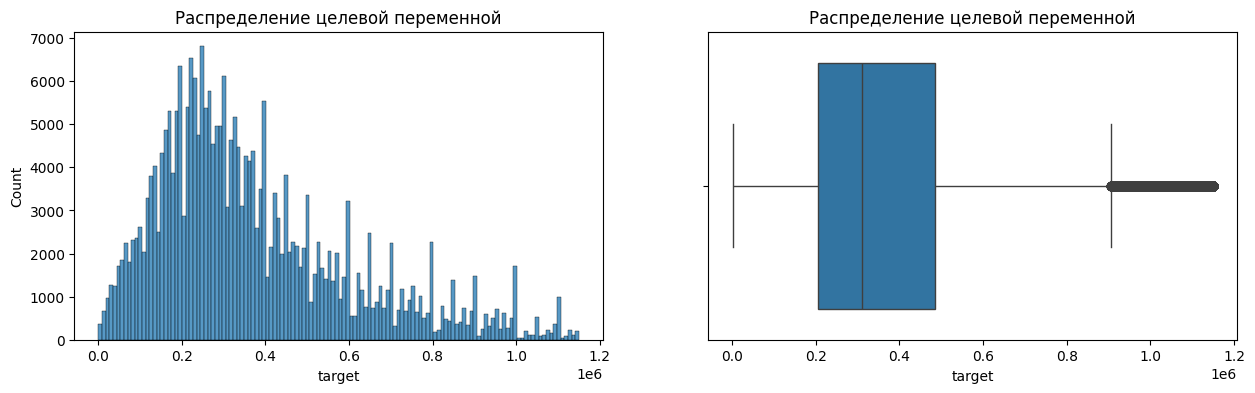

In [447]:
#Визуализируем гистограмму целевой переменной после удаления выбросов
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=iqr_cleaned, x='target', ax=axes[0]);
histplot.set_title('Распределение целевой переменной');
boxplot = sns.boxplot(data=iqr_cleaned, x='target', ax=axes[1]);
boxplot.set_title('Распределение целевой переменной');

In [448]:
iqr_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263205 entries, 0 to 377011
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   status                263205 non-null  object 
 1   street                263205 non-null  object 
 2   baths                 263205 non-null  object 
 3   city                  263205 non-null  object 
 4   sqft                  263205 non-null  float64
 5   state                 263205 non-null  object 
 6   target                263205 non-null  int32  
 7   pool_encoded          263205 non-null  bool   
 8   Type                  263205 non-null  object 
 9   bedsCleaned           263205 non-null  object 
 10  Year built            263205 non-null  float64
 11  Remodeled year        263205 non-null  object 
 12  Heating               263205 non-null  object 
 13  Parking               263205 non-null  object 
 14  cooling_info_cleaned  263205 non-null  object 
dtypes: bo

In [449]:
iqr_cleaned['bedsCleaned'].value_counts()

bedsCleaned
3.0        87833
no data    55086
4.0        54558
2.0        41639
5.0        13583
1.0         4936
6.0         3156
0.0          740
7.0          732
8.0          514
9.0          197
10.0         104
12.0          48
11.0          37
14.0          11
16.0           9
13.0           9
20.0           3
28.0           2
15.0           2
34.0           1
17.0           1
22.0           1
18.0           1
44.0           1
24.0           1
Name: count, dtype: int64

Проверим данные на дубликаты

In [450]:
iqr_cleaned.duplicated().any()

True

In [451]:
iqr_cleaned[iqr_cleaned.duplicated()]

,status,street,baths,city,sqft,state,target,pool_encoded,Type,bedsCleaned,Year built,Remodeled year,Heating,Parking,cooling_info_cleaned
15130,For Sale,306 Knightwood Dr,3.0,Durham,2385.0,NC,239900,False,single_family_home,3.0,2005.0,no,other,garage,no data
22551,For Sale,16170 Ohio St,2.0,Detroit,1480.0,MI,59900,False,single_family_home,3.0,1951.0,no,other,garage,no data
28649,For Sale,2716 E 2nd St,2.0,Austin,1116.0,TX,495000,False,single_family_home,3.0,1945.0,no,other,on,central
30363,For Sale,3191 Robwood Dr,2.0,Nashville,1450.0,TN,269900,False,single_family_home,4.0,1962.0,yes,other,other,central
33737,For Sale,3345 W 29th Ave,3.0,Denver,2005.0,CO,900000,False,single_family_home,3.0,1900.0,no,other,other,central
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376334,For Sale,2131 W Cypress St,2.0,Tampa,1368.0,FL,225000,False,single_family_home,2.0,1926.0,yes,other,other,other
376445,For Sale,604 E Mesa Ave,2.0,Fresno,1911.0,CA,340000,False,single_family_home,4.0,1980.0,yes,other,garage,central
376608,For Sale,7402 SW 54th Ave,2.0,Miami,2126.0,FL,850000,True,single_family_home,3.0,1941.0,yes,other,other,no data
376746,For Sale,16215 9th Ave NE,2.0,Shoreline,1010.0,WA,490000,False,single_family_home,3.0,1947.0,no,other,off,no data


In [452]:
df4 = iqr_cleaned.copy()

In [453]:
# сохраняем количество строк до удаления дубликатов
rows_before = df4.shape[0]
#удалим дубликаты
df4 = df4.drop_duplicates(ignore_index=True)
# сохраняем количество строк после удаления дубликатов
rows_after = df4.shape[0]
# считаем количество удаленных дубликатов
duplicates_removed = rows_before - rows_after
print(f'Удалено {duplicates_removed} дубликатов')

Удалено 1194 дубликатов


In [454]:
# Сохраним данные в CSV-файл
df4.to_csv("data/cleaned_data.csv", index=False)

In [455]:
# Составим список булевых признаков:
bin_features = ['pool_encoded']

# Составим список категориальных признаков:
cat_features = ['status','city','state','Type','baths','bedsCleaned','Year built','Remodeled year']
 
# Составим список числовых признаков:
num_features = ['sqft', 'target', 'Year built']

In [456]:
df5 = pd.read_csv('data/cleaned_data.csv')
display(df5.head())
df5.info()

,status,street,baths,city,sqft,state,target,pool_encoded,Type,bedsCleaned,Year built,Remodeled year,Heating,Parking,cooling_info_cleaned
0,Active,240 Heather Ln,4.0,Southern Pines,2900.0,NC,418000,False,single_family_home,4.0,2019.0,no,other,other,no data
1,For Sale,12911 E Heroy Ave,3.0,Spokane Valley,1947.0,WA,310000,False,single_family_home,3.0,2019.0,no,other,other,no data
2,For Sale,1624 S Newkirk St,no data,Philadelphia,897.0,PA,209000,False,townhouse,2.0,1920.0,no,other,other,central
3,Active,552 Casanova Ct,no data,Poinciana,1507.0,FL,181500,False,other,no data,2006.0,yes,other,other,air
4,Active,11182 Owl Ave,2.0,Mason City,3588.0,IA,244900,False,single_family_home,3.0,1970.0,no,other,other,central


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262011 entries, 0 to 262010
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   status                262011 non-null  object 
 1   street                262011 non-null  object 
 2   baths                 262011 non-null  object 
 3   city                  262011 non-null  object 
 4   sqft                  262011 non-null  float64
 5   state                 262011 non-null  object 
 6   target                262011 non-null  int64  
 7   pool_encoded          262011 non-null  bool   
 8   Type                  262011 non-null  object 
 9   bedsCleaned           262011 non-null  object 
 10  Year built            262011 non-null  float64
 11  Remodeled year        262011 non-null  object 
 12  Heating               262011 non-null  object 
 13  Parking               262011 non-null  object 
 14  cooling_info_cleaned  262011 non-null  object 
dtype

## Проверка числовых признаков на выбросы

In [457]:
# Составим список числовых признаков:
num_features = [ 'sqft', 'target', 'Year built']

In [458]:
# Метод межквартильного размаха (IQR):
for feature in num_features:
    Q1 = df5[feature].quantile(0.25)
    Q3 = df5[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df5[(df5[feature] < lower_bound) | (df5[feature] > upper_bound)]
    percentage = (len(outliers) / len(df5)) * 100
    print(f"Процент выбросов для {feature} (IQR): {percentage:.2f}%")

Процент выбросов для sqft (IQR): 2.80%
Процент выбросов для target (IQR): 3.58%
Процент выбросов для Year built (IQR): 0.39%


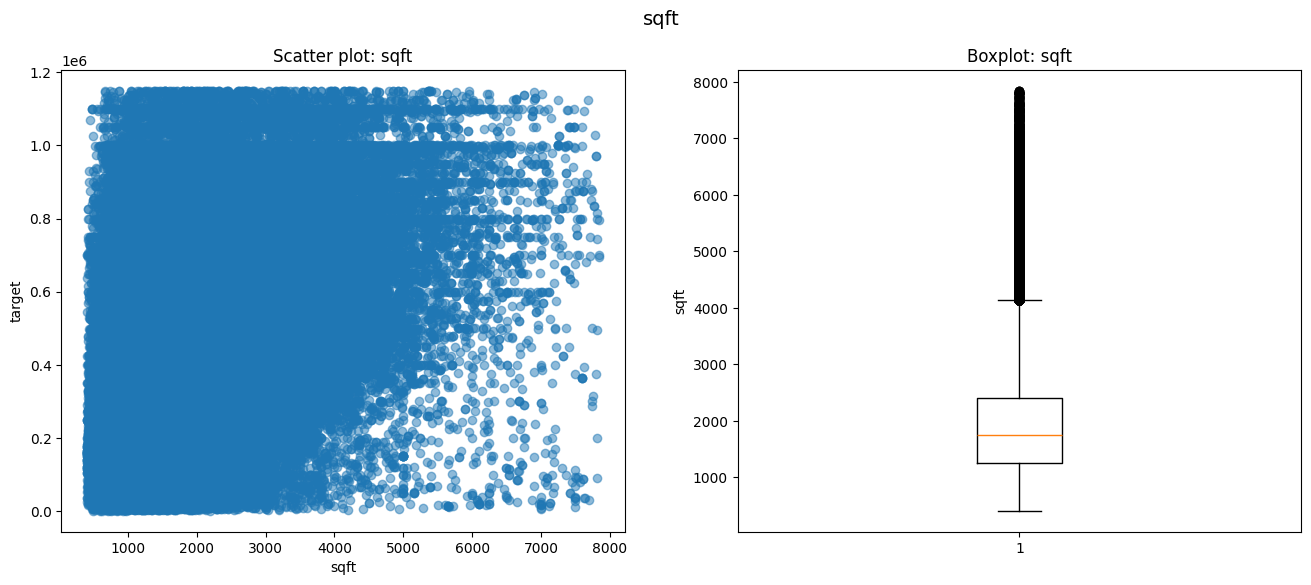

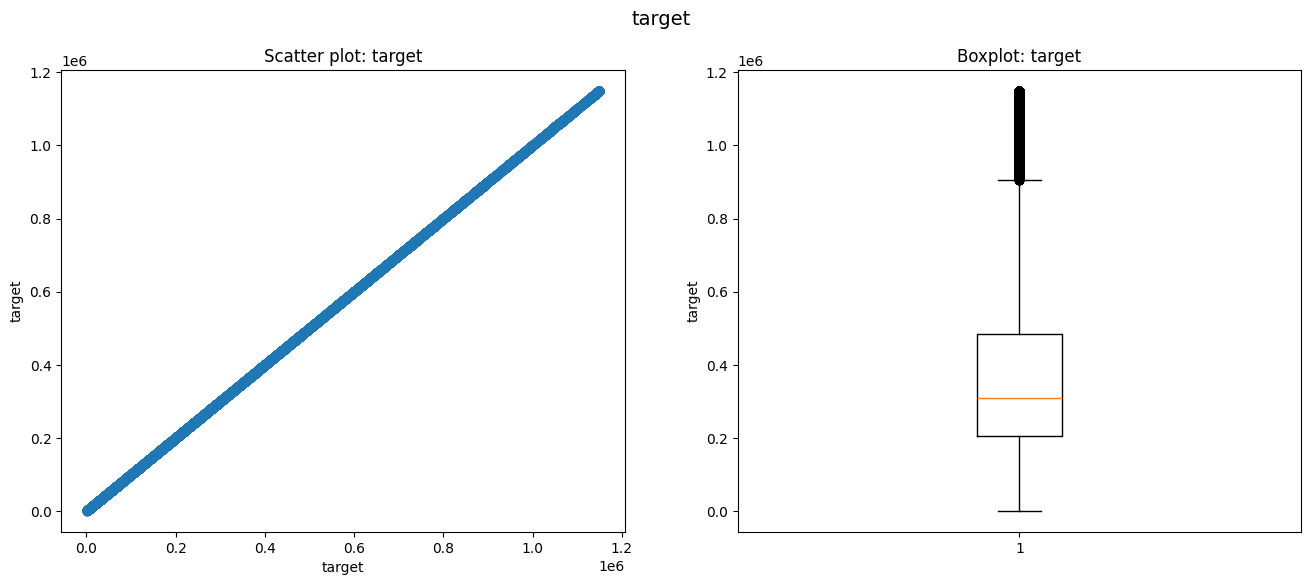

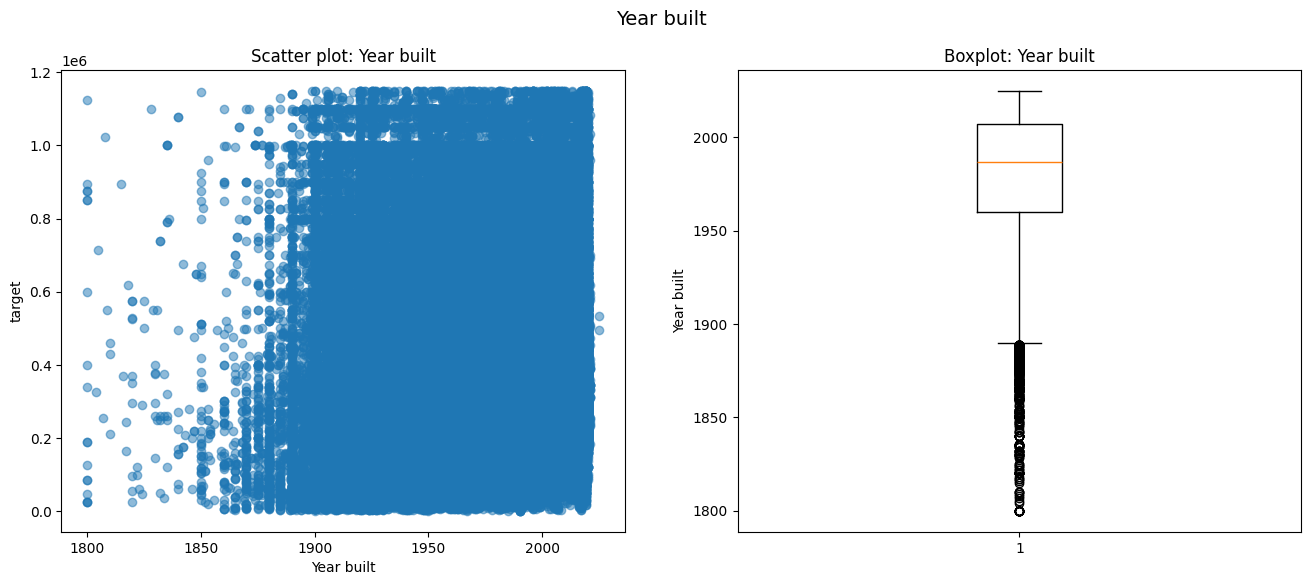

In [459]:
for feature in num_features:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{feature}', fontsize=14)

    # График рассеивания
    ax1.scatter(df5[feature], df5['target'], alpha=0.5)
    ax1.set_title(f'Scatter plot: {feature}')
    ax1.set_xlabel(feature)
    ax1.set_ylabel('target')

    # Ящик с усами
    ax2.boxplot(df5[feature])
    ax2.set_title(f'Boxplot: {feature}')
    ax2.set_ylabel(feature)

    plt.show()

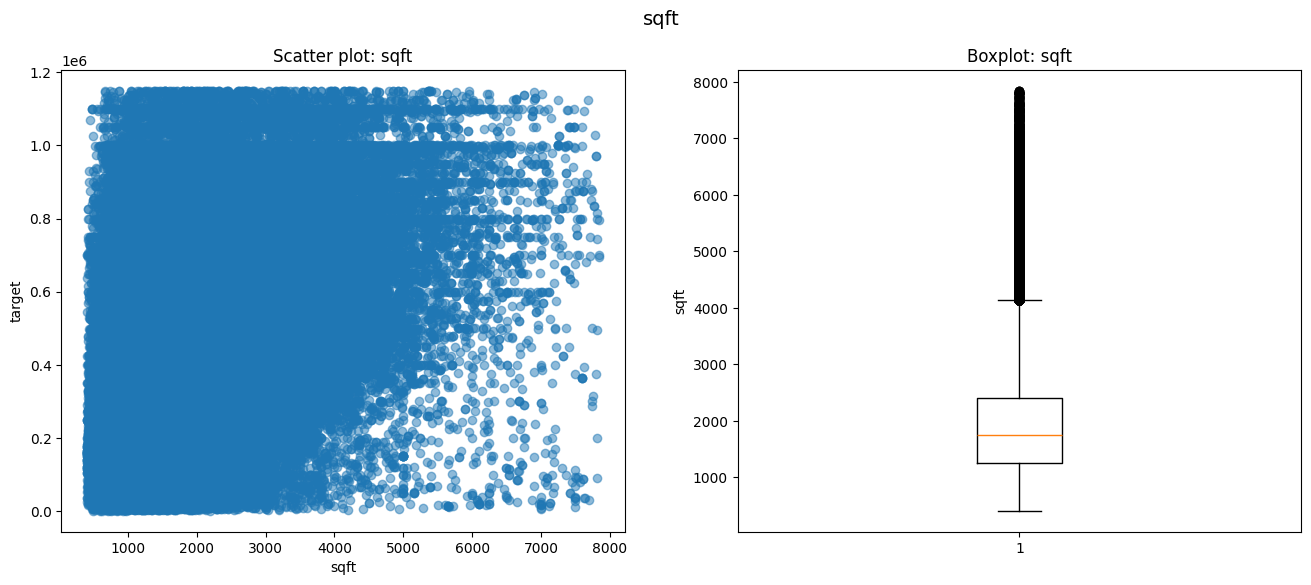

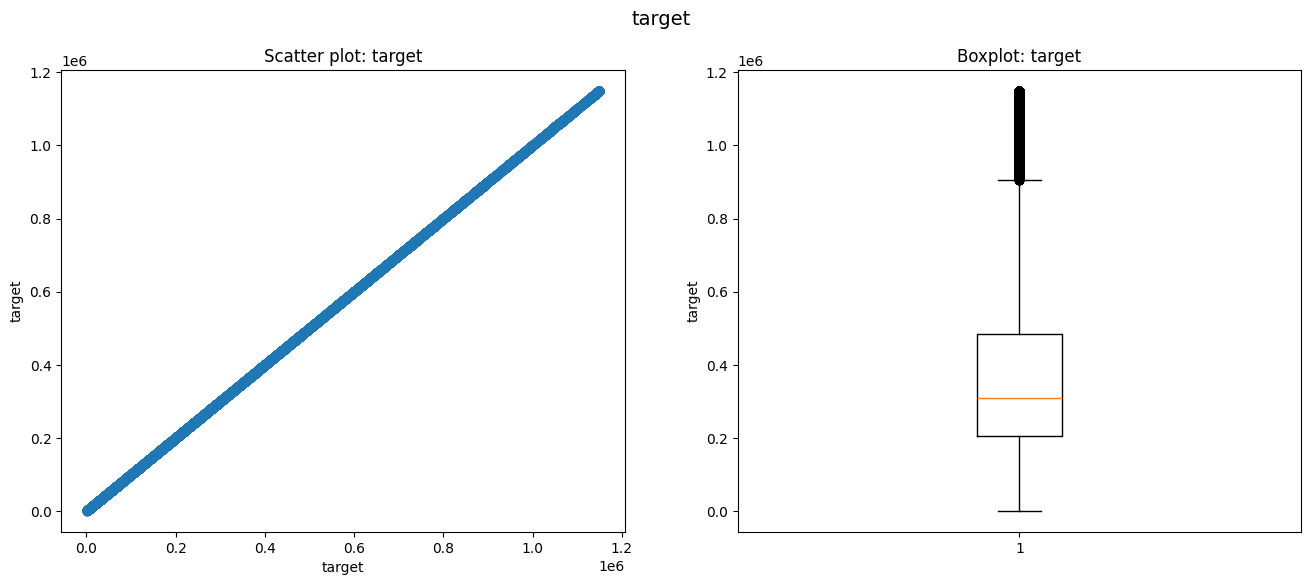

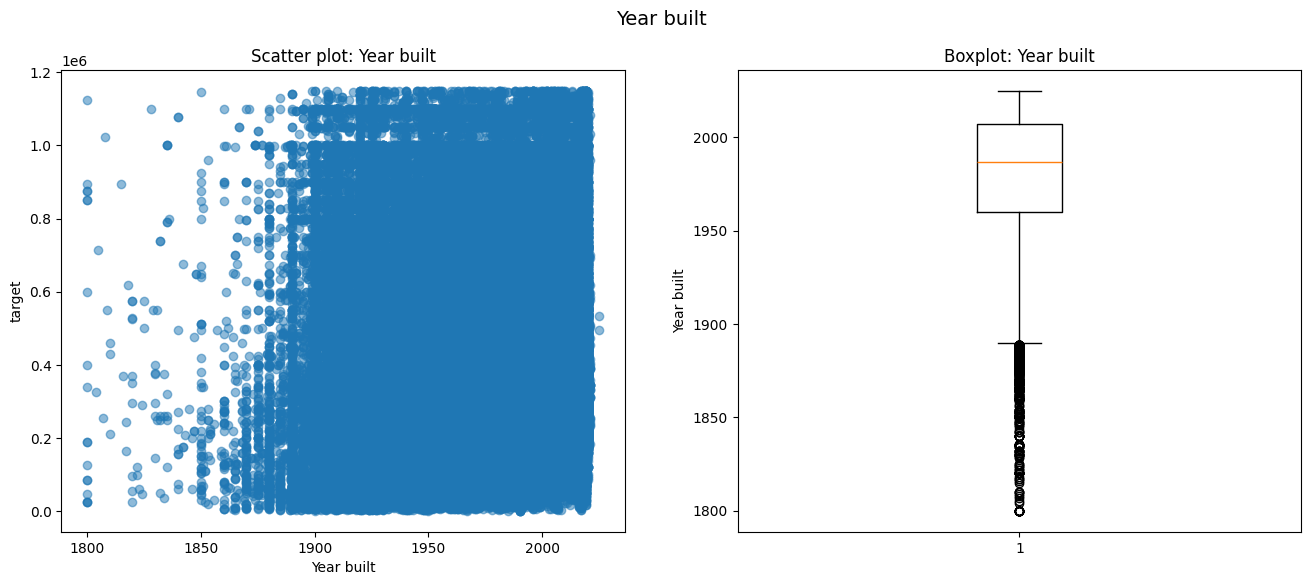

In [460]:
for feature in num_features:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{feature}', fontsize=14)

    # График рассеивания
    ax1.scatter(df5[feature], df5['target'], alpha=0.5)
    ax1.set_title(f'Scatter plot: {feature}')
    ax1.set_xlabel(feature)
    ax1.set_ylabel('target')

    # Ящик с усами
    ax2.boxplot(df5[feature])
    ax2.set_title(f'Boxplot: {feature}')
    ax2.set_ylabel(feature)

    plt.show()

In [461]:
condition3 = df5['Year built'] < 1880
filtered3_df = df5[condition3]
# Вывести отфильтрованные строки
print(len(filtered3_df))
display(filtered3_df.head(5))

514


,status,street,baths,city,sqft,state,target,pool_encoded,Type,bedsCleaned,Year built,Remodeled year,Heating,Parking,cooling_info_cleaned
495,For Sale,547 E Ridgewood Dr,4.0,Seven Hills,3030.0,OH,429988,False,single_family_home,4.0,1879.0,no,other,other,no data
705,For Sale,400 E Evergreen Ave,4.0,Philadelphia,4018.0,PA,998700,False,single_family_home,5.0,1860.0,no,other,garage,other
1246,For Sale,1036 Dayton St,no data,Cincinnati,2850.0,OH,110000,False,multi_family_home,0.0,1865.0,no,other,on,other
2645,Active,1620 Corcoran St NW Apt A1,1.0,Washington,753.0,DC,399900,False,condo,2.0,1875.0,no,other,other,central
3769,Active,160 N Main St Apt 4,1.0,Saint Albans City,728.0,VT,105000,False,condo,1.0,1850.0,no,other,parking,no data


Удалим эти записи

In [462]:
df5.drop(df5[condition3].index, inplace=True)

In [463]:
condition5 = df5['target'] > 750000
filtered5_df = df5[condition5]
# Вывести отфильтрованные строки
print(len(filtered5_df))
display(filtered5_df.head(5))

21881


,status,street,baths,city,sqft,state,target,pool_encoded,Type,bedsCleaned,Year built,Remodeled year,Heating,Parking,cooling_info_cleaned
19,For Sale,430 Sterling Pl #1A,2.0,Brooklyn,935.0,NY,830000,False,condo,2.0,1910.0,no,other,on,no data
35,For Sale,4146 Diaz Ct,4.0,Hernando Beach,3756.0,FL,799000,False,single_family_home,4.0,1997.0,yes,other,garage,central
49,For Sale,340 W 2nd St #4,2.0,Boston,1060.0,MA,916900,False,condo,2.0,2019.0,no,other,other,central
65,Active,10550 SW 97th Ave,no data,Miami,3685.0,FL,800000,False,single_family_home,no data,1952.0,yes,other,other,other
76,For Sale,29191 Weybridge Dr,6.0,Westlake,7362.0,OH,924900,False,single_family_home,6.0,1997.0,yes,other,garage,central


In [464]:
df5.drop(df5[condition5].index, inplace=True)

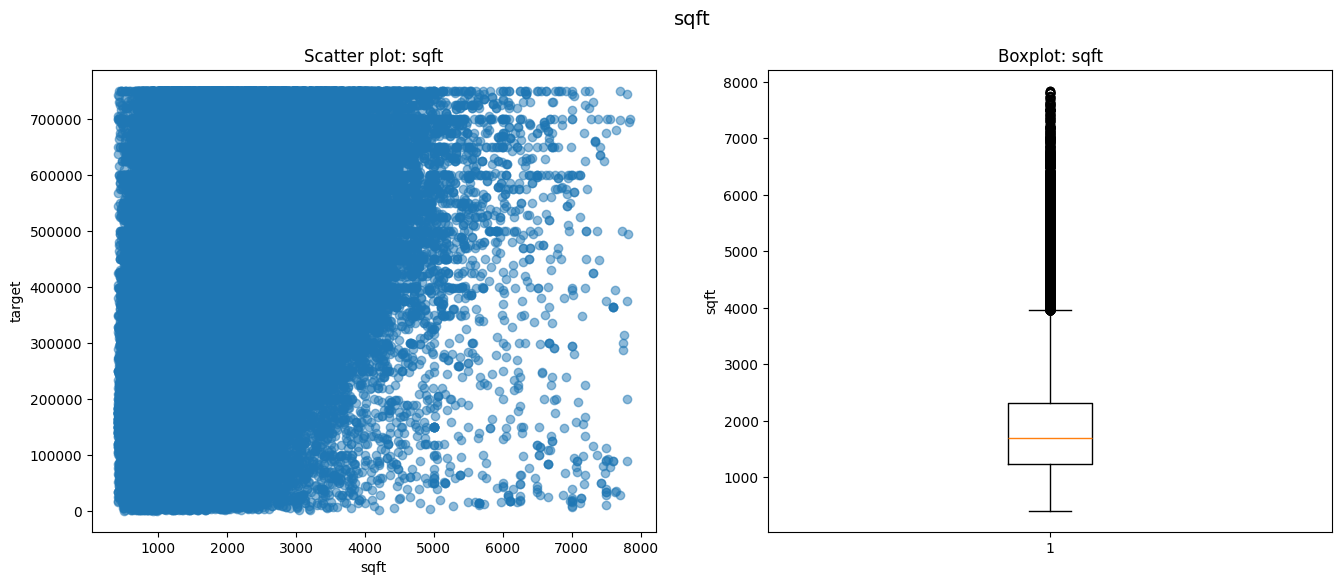

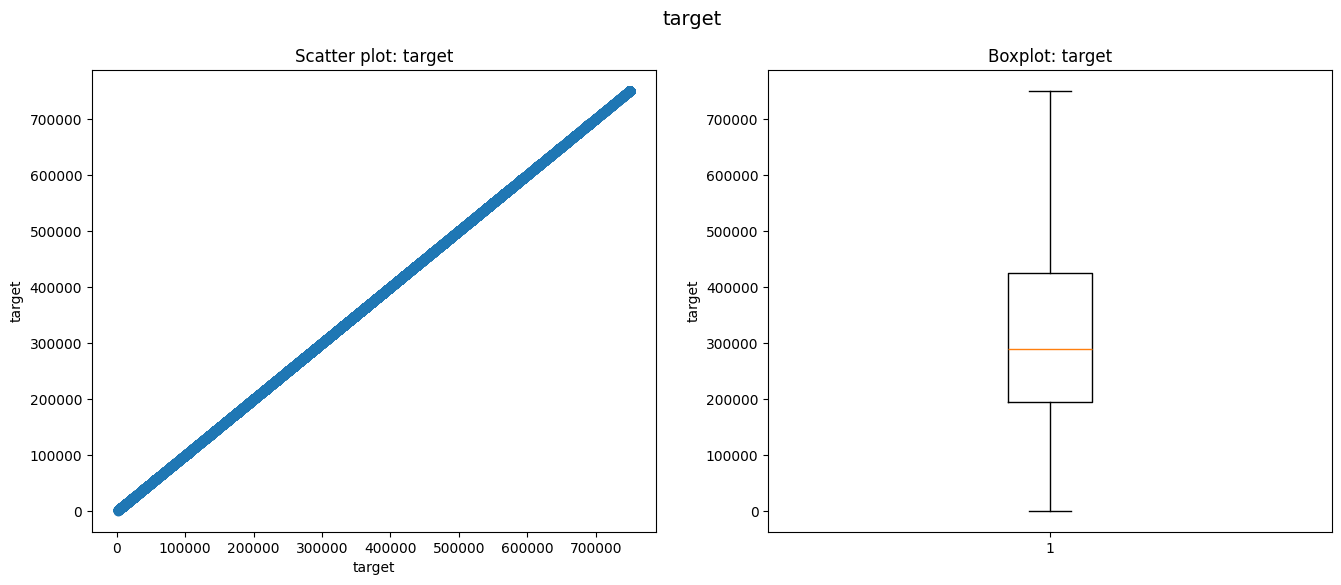

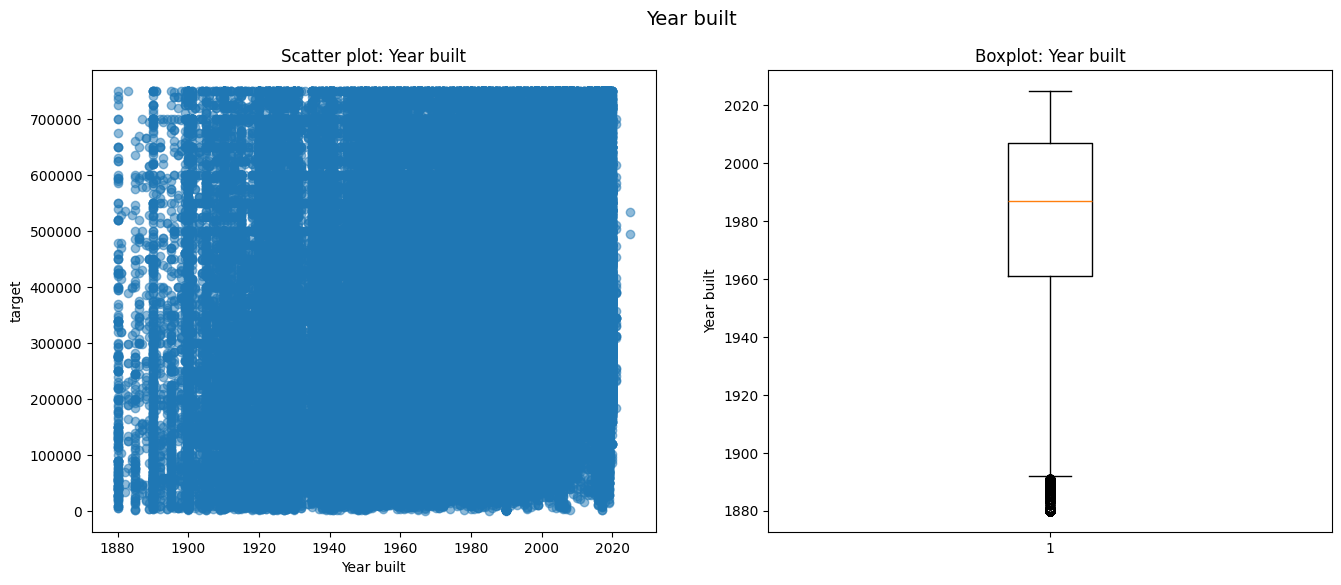

In [465]:
for feature in num_features:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{feature}', fontsize=14)

    # График рассеивания
    ax1.scatter(df5[feature], df5['target'], alpha=0.5)
    ax1.set_title(f'Scatter plot: {feature}')
    ax1.set_xlabel(feature)
    ax1.set_ylabel('target')

    # Ящик с усами
    ax2.boxplot(df5[feature])
    ax2.set_title(f'Boxplot: {feature}')
    ax2.set_ylabel(feature)

    plt.show()

Посмотрим влияет ли признак наличия бассейна на целевой признак. Для этого визуализируем boxplot целевого признака в разрезе признака pool.

Text(0.5, 1.0, 'Распределение target в разрезе pool')

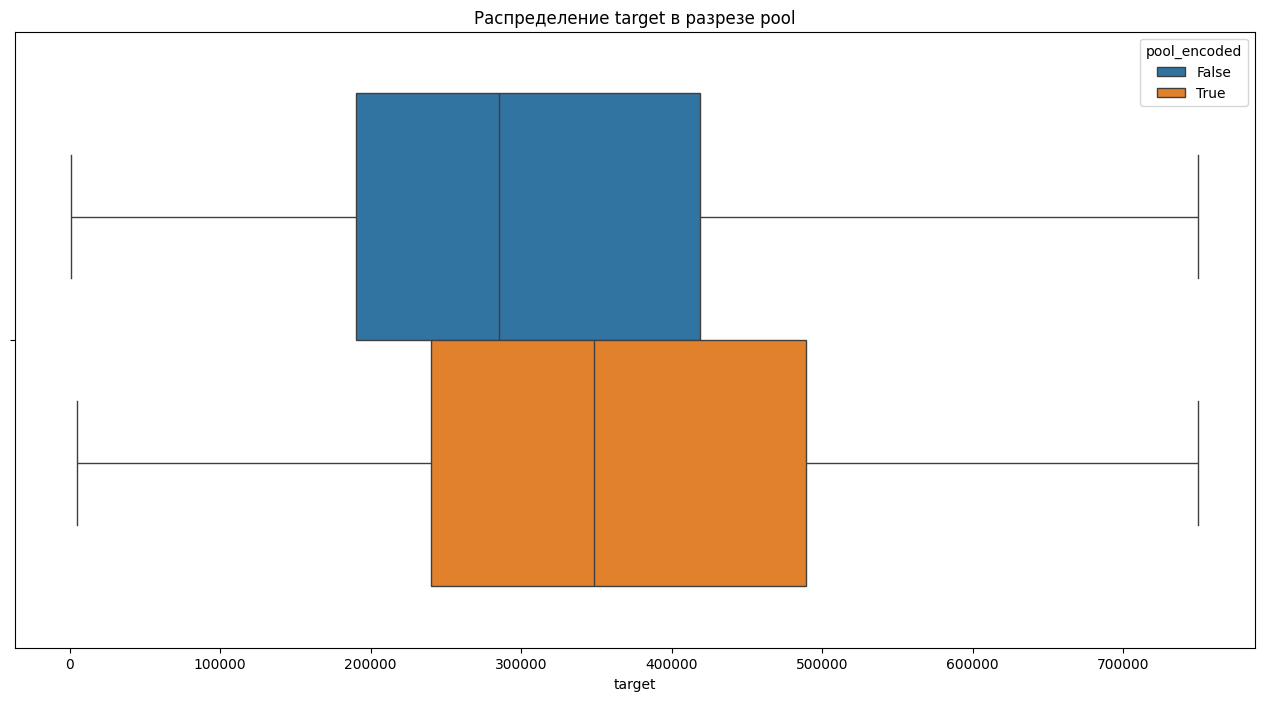

In [466]:
#Строим визуализацию.
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
sns.boxplot(df5, x='target', hue='pool_encoded', ax=ax)
ax.set_title('Распределение target в разрезе pool')

Из визуализации можно сделать вывод, что недвижимость с бассейном имеет большую стоимость, чем без него, так как коробка и медианное значение данных с бассейном находится в стороне больших значений. В целом это логично, потому что бассейн и оборудование для него - дорогое удовольствие. Давайте проверим то, насколько эта разница в распределениях статистически значима, для этого проведем статистический тест.

Для начала проверим распределения на нормальность. Будем делать это с помощью теста Шапиро-Уилка.

Гипотезы в основе теста:

Нулевая: данные распределены нормально.
Альтернативная: данные не распределены нормально.
Сейчас и в других тестах за уровень значимости возьмем $\alpha$

In [467]:
#Уровень значимости
alpha = 0.05
#Определяем наши выборки
data_with_pool = df5[df5['pool_encoded'] == True]['target']
data_without_pool = df5[df5['pool_encoded'] == False]['target']

print(f'Тест для выборки с бассейном')
# проводим тест Шапиро — Уилка
_, p = stats.shapiro(data_with_pool);
print('p-value = %.3f' % (p))
# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')
    
print(f'Тест для выборки без бассейна')
# проводим тест Шапиро — Уилка
_, p = stats.shapiro(data_without_pool);
print('p-value = %.3f' % (p))
# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

Тест для выборки с бассейном
p-value = 0.000
Распределение не нормальное
Тест для выборки без бассейна
p-value = 0.000
Распределение не нормальное


c:\Users\Анечка\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 26593.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Анечка\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 213023.
  res = hypotest_fun_out(*samples, **kwds)


Так как данные распределены не нормально, будем использовать непараметрический тест - критерий Манна-Уинтни.

- Нулевая гипотеза $H_0$: наличие бассейна не влияет на ценообразование недвижимости.
- Альтернативная гипотеза $H_1$: наличие бассейна влияет на ценообразование недвижимости.

In [468]:
# проводим тест
_, p = stats.mannwhitneyu(data_with_pool, data_without_pool)

print('p-value = {:.3f}'.format(p))

# интерпретируем результат
if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


По результатам теста считаем, что бассейн влияет на цену, что соответствует выводам по визуализации. Не зря мы не удалили этот признак из-за большого числа пропусков, возможно, он будет иметь ценность для модели.

### Теперь посмотрим на целевую переменную в разрезе признака количества ванных комнат.

Text(0.5, 1.0, 'Распределение target в разрезе baths')

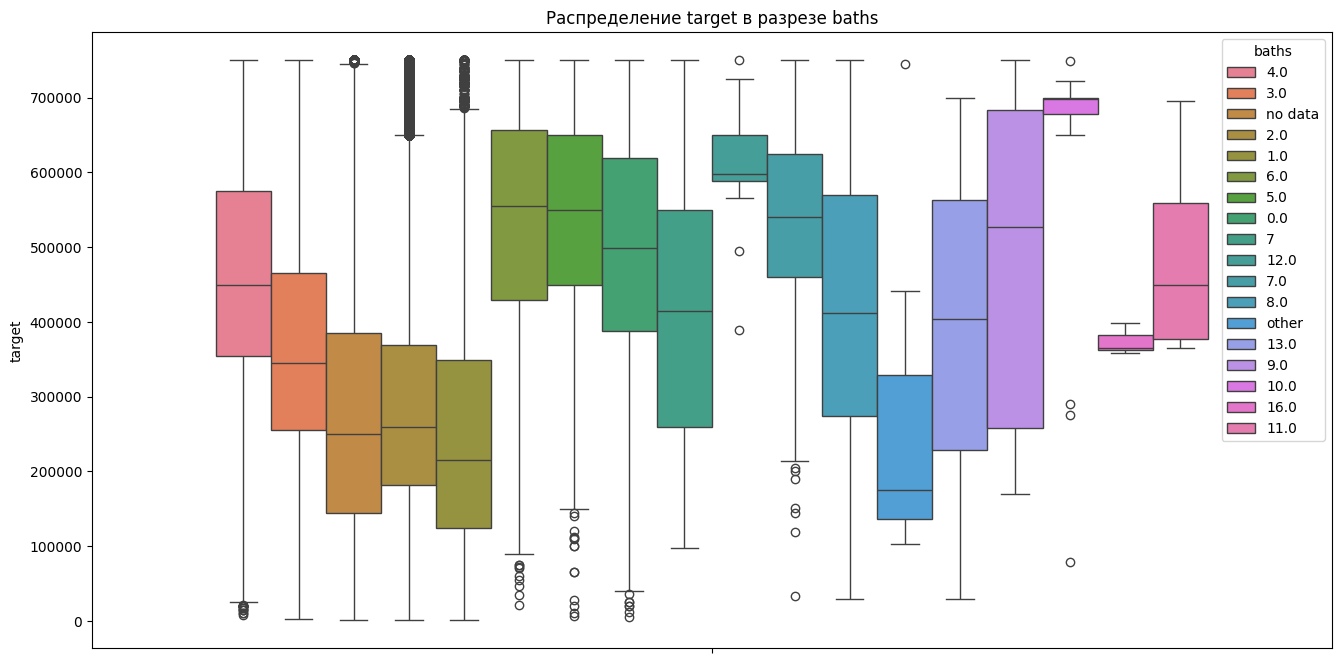

In [469]:
#Строим визуализацию.
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
sns.boxplot(df5, y='target', hue='baths', ax=ax )
ax.set_title('Распределение target в разрезе baths')

Из графика в целом прослеживается тенденция, что, чем больше ванных комнат (а, следовательно тем больше спален), тем больше цена недвижимости. Однако явно выделя.тся записи, где число ванн большое, а цена  - низкаяю удалим эти записи.

In [470]:
# condition4 = df5['baths'] > 12
# filtered4_df = df5[condition4]
# # Вывести отфильтрованные строки
# print(len(filtered4_df))
# display(filtered4_df.head(5))

In [471]:
#df5.drop(df5[condition4].index, inplace=True)

Text(0.5, 1.0, 'Распределение target в разрезе baths')

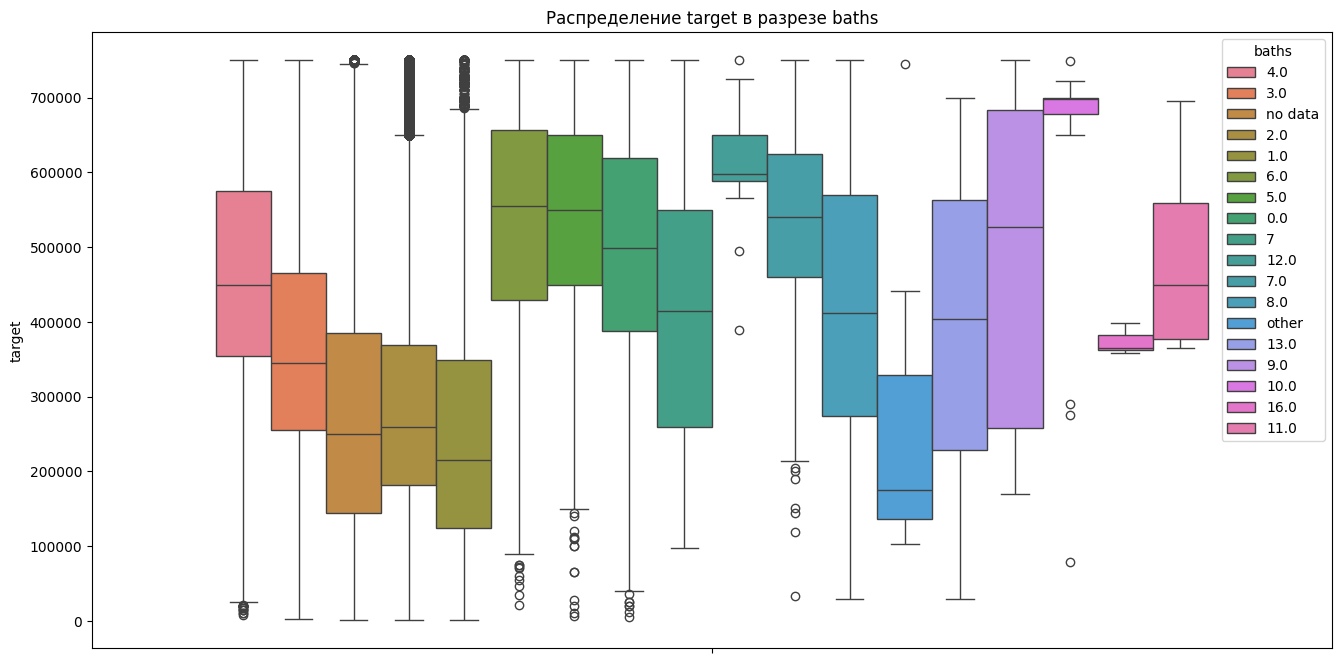

In [472]:
#Строим визуализацию.
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
sns.boxplot(df5, y='target', hue='baths', ax=ax )
ax.set_title('Распределение target в разрезе baths')

Также проведем статистические тесты. Для начала проверяем на нормальность.

In [473]:
df5['baths'].value_counts()

baths
2.0        102504
no data     50229
3.0         49124
4.0         19918
1.0         13600
5.0          2603
6.0           672
0.0           466
7             182
7.0           163
8.0            82
10.0           17
12.0           17
other          11
9.0            10
13.0            8
11.0            7
16.0            3
Name: count, dtype: int64

In [474]:
#Уровень значимости
alpha = 0.05
#Определяем наши выборки
data_baths_0 = df5[df5['baths'] == 0]['target']
data_baths_1 = df5[df5['baths'] == 1]['target']
data_baths_2 = df5[df5['baths'] == 2]['target']
data_baths_3 = df5[df5['baths'] == 3]['target']
data_baths_4 = df5[df5['baths'] == 4]['target']
data_baths_5 = df5[df5['baths'] == 5]['target']
data_baths_6 = df5[df5['baths'] == 6]['target']
data_baths_7 = df5[df5['baths'] == 7]['target']
data_baths_8 = df5[df5['baths'] == 8]['target']
data_baths_9 = df5[df5['baths'] == 9]['target']
data_baths_10 = df5[df5['baths'] == 10]['target']
data_baths_11 = df5[df5['baths'] == 11]['target']
data_baths_12 = df5[df5['baths'] == 12]['target']

# проводим тест Шапиро — Уилка
_, p = stats.shapiro(data_baths_0);
print('p-value = %.3f' % (p))
# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

p-value = nan
Распределение нормальное


C:\Users\Анечка\AppData\Local\Temp\ipykernel_31136\3991366909.py:19: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p = stats.shapiro(data_baths_0);


Так как распределение не нормальное, используем непараметрический тест критерий Краскела-Уоллиса.

Гипотезы:

Нулевая гипотеза: кол-во ванных не влияет на ценообразование недвижимости.
Альтернативная гипотеза: кол-во ванных влияет на ценообразование недвижимости.

In [475]:
_, p = stats.kruskal(data_baths_0, data_baths_1, data_baths_2, data_baths_3, data_baths_4, data_baths_5, data_baths_6, data_baths_7, data_baths_8, data_baths_9,
                     data_baths_10, data_baths_11, data_baths_12)

print('p-value = {:.3f}'.format(p))

# интерпретируем результат
if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = nan
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


C:\Users\Анечка\AppData\Local\Temp\ipykernel_31136\1090825433.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p = stats.kruskal(data_baths_0, data_baths_1, data_baths_2, data_baths_3, data_baths_4, data_baths_5, data_baths_6, data_baths_7, data_baths_8, data_baths_9,


Итак, результат соответствует нашей визуализации - кол-во ванных комнат влияет на цену дома

Text(0.5, 1.0, 'Распределение target в разрезе Remodeled year')

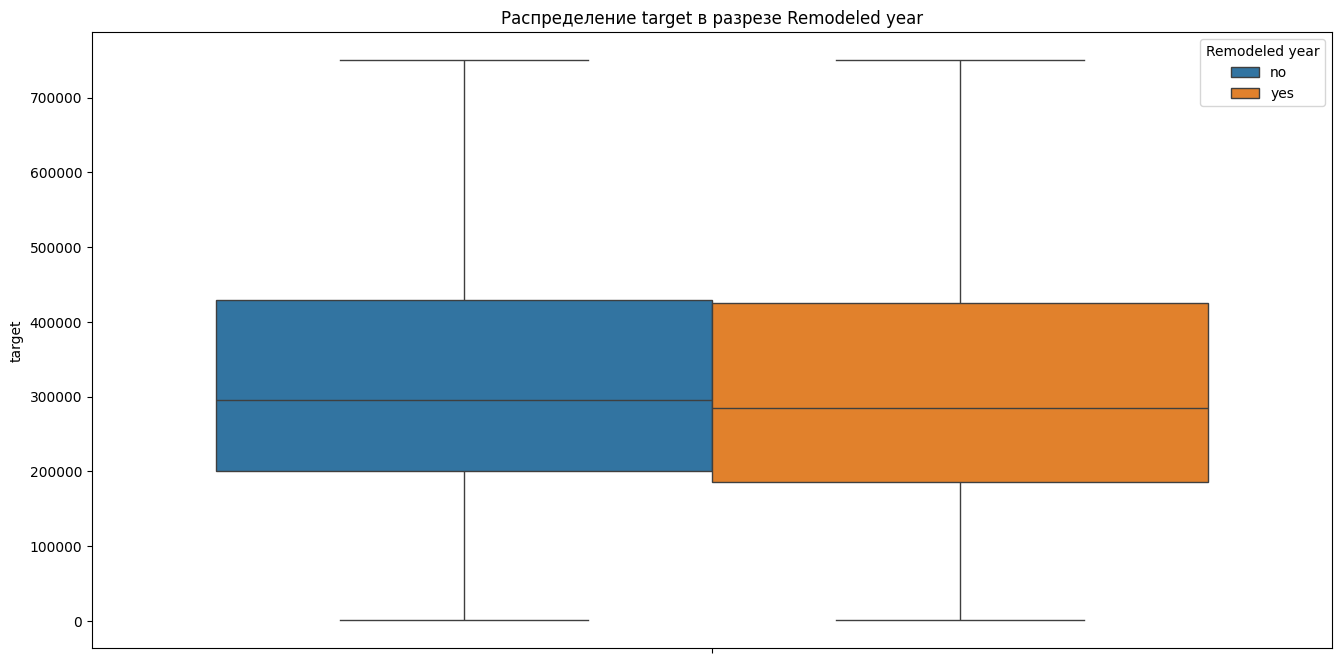

In [476]:
#Строим визуализацию.
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
sns.boxplot(df5, y='target', hue='Remodeled year', ax=ax )
ax.set_title('Распределение target в разрезе Remodeled year')

In [477]:
#Уровень значимости
alpha = 0.05
#Определяем наши выборки
data_0 = df5[df5['Remodeled year'] == 'no']['target']
data_1 = df5[df5['Remodeled year'] == 'yes']['target']

# проводим тест Шапиро — Уилка
_, p = stats.shapiro(data_baths_0);
print('p-value = %.3f' % (p))
# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

p-value = nan
Распределение нормальное


C:\Users\Анечка\AppData\Local\Temp\ipykernel_31136\996645377.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p = stats.shapiro(data_baths_0);


Так как данные распределены не нормально, будем использовать непараметрический тест - критерий Манна-Уинтни.

- Нулевая гипотеза $H_0$: ренновация дома не влияет на ценообразование недвижимости.
- Альтернативная гипотеза $H_1$: ренновация дома влияет на ценообразование недвижимости.

In [478]:
# проводим тест
_, p = stats.mannwhitneyu(data_0, data_1)

print('p-value = {:.3f}'.format(p))

# интерпретируем результат
if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Несмотря на то, что визуально кажется, что ренновация дома не влияет на стоимость жилья, статистические тесты говорят об обратном.

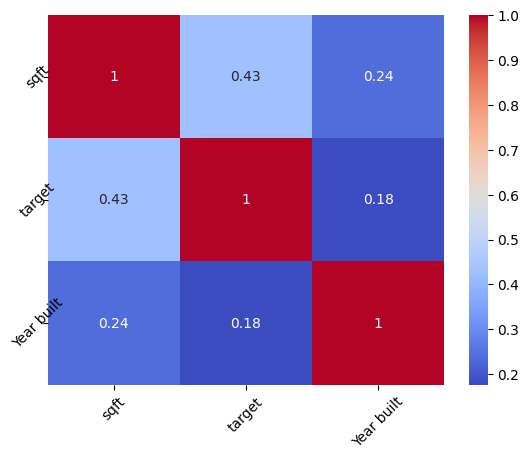

In [479]:
# Проверим на мультиколлинеарность и корреляцию числовых признаков между собой и с главным признаком "target":
# строим матрицу корреляций
corr_matrix = np.corrcoef(df5[num_features], rowvar=False)


# строим тепловую карту
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.xticks(np.arange(len(df5[num_features].columns))+0.5, df5[num_features].columns, rotation=45, ha='center', fontsize=10)
plt.yticks(np.arange(len(df5[num_features].columns))+0.5, df5[num_features].columns, ha='center', fontsize=10, va='center', rotation=45)
# отображаем график
plt.show();

Мультиколлинеарность отсутствует

Посмотрим на распределение целевово признака в зависимости от других категориальных признаков.

In [480]:
#Предобрабатываем признак city
top_city = df5['city'].value_counts().head(30).index
df5['city'] = df5['city'].apply(lambda x: x if x in top_city else 'other')

#Предобрабатываем признак state
top_states = df5['state'].value_counts().head(30).index
df5['state'] = data_cleaned['state'].apply(lambda x: x if x in top_states else 'other')

Text(0.5, 1.0, 'Распределение target в разрезе Parking')

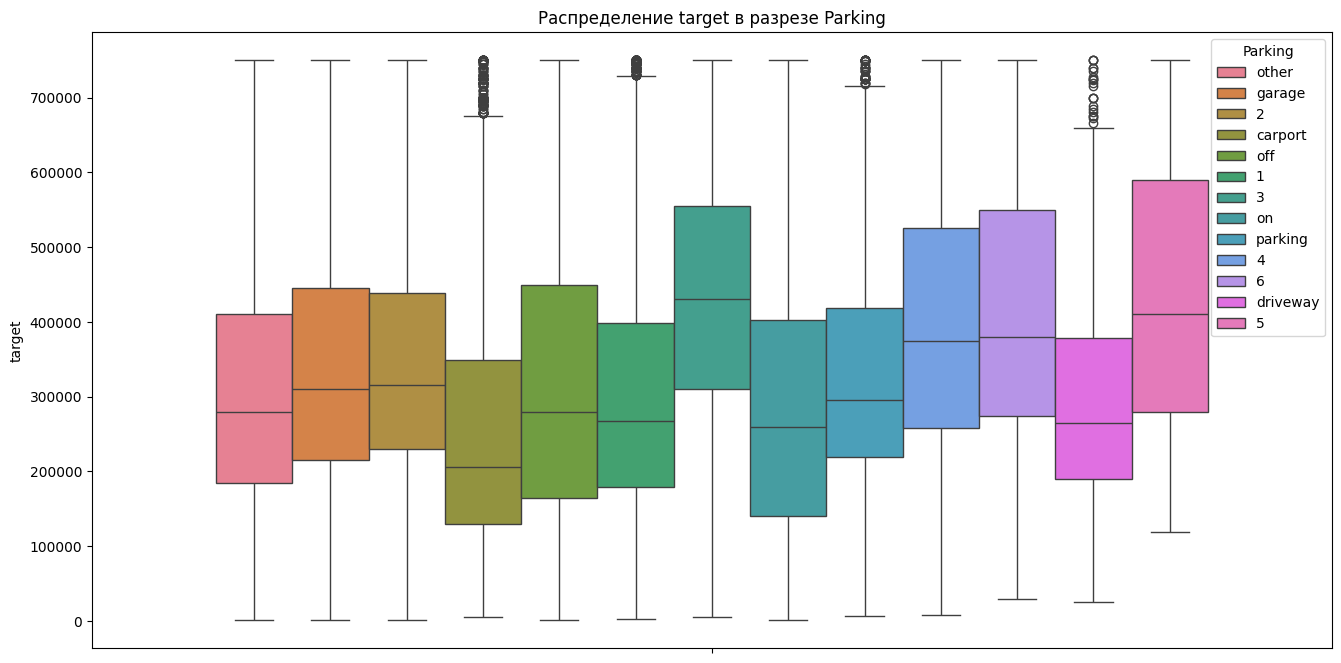

In [481]:
fig, axes = plt.subplots(1, 1, figsize = (16, 8))
sns.boxplot(df5, y='target', hue='Parking')
axes.set_title('Распределение target в разрезе Parking')

Text(0.5, 1.0, 'Распределение target в разрезе cooling_info_cleaned')

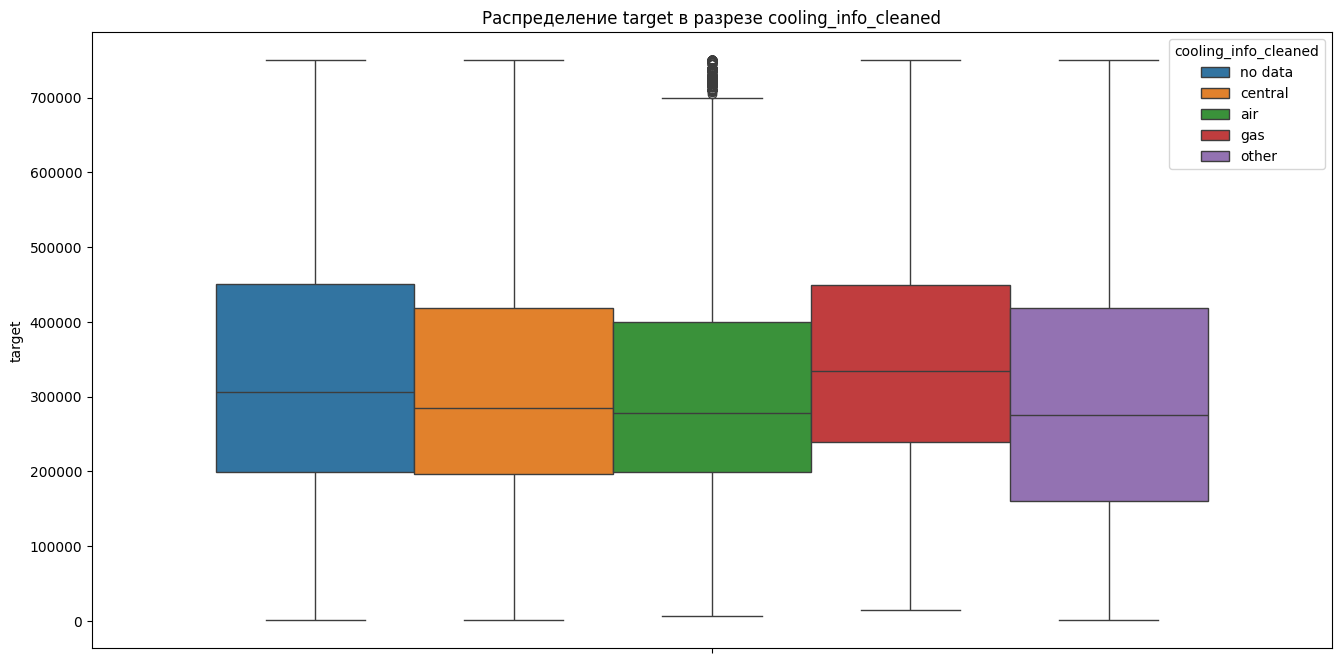

In [482]:
fig, axes = plt.subplots(1, 1, figsize = (16, 8))
sns.boxplot(df5, y='target', hue='cooling_info_cleaned')
axes.set_title('Распределение target в разрезе cooling_info_cleaned')

Text(0.5, 1.0, 'Распределение target в разрезе Heating')

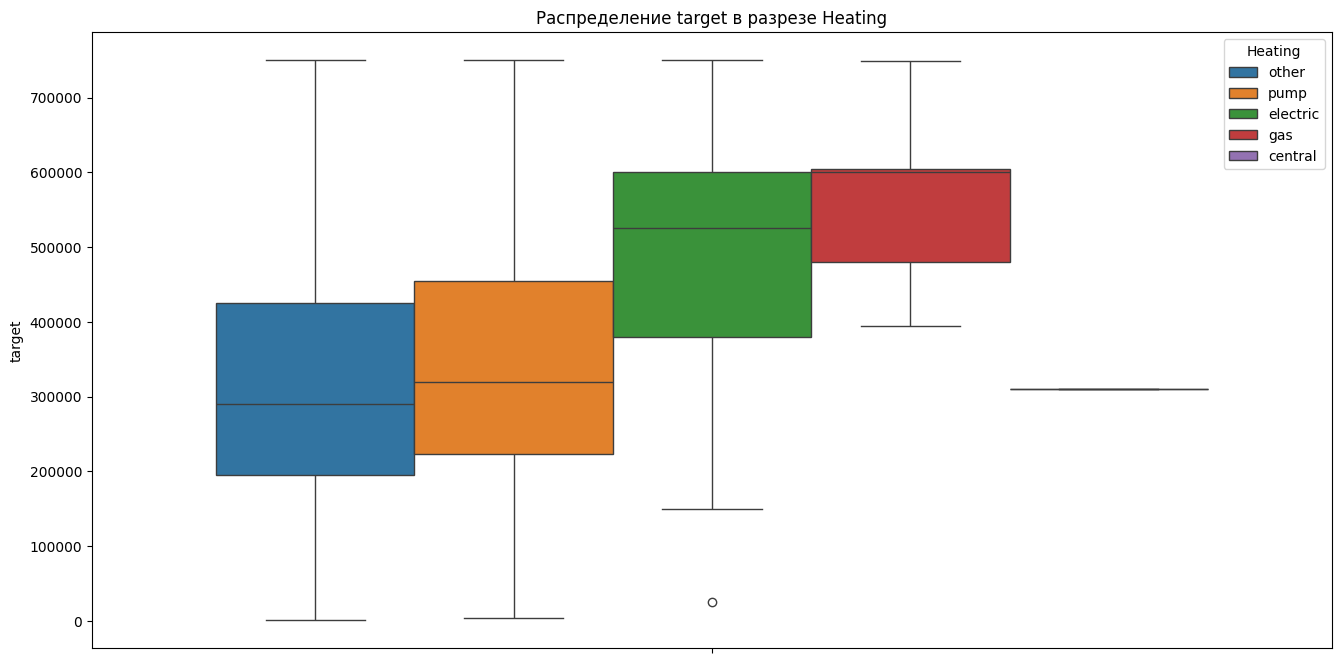

In [483]:
fig, axes = plt.subplots(1, 1, figsize = (16, 8))
sns.boxplot(df5, y='target', hue='Heating')
axes.set_title('Распределение target в разрезе Heating')

Text(0.5, 1.0, 'Распределение target в разрезе city')

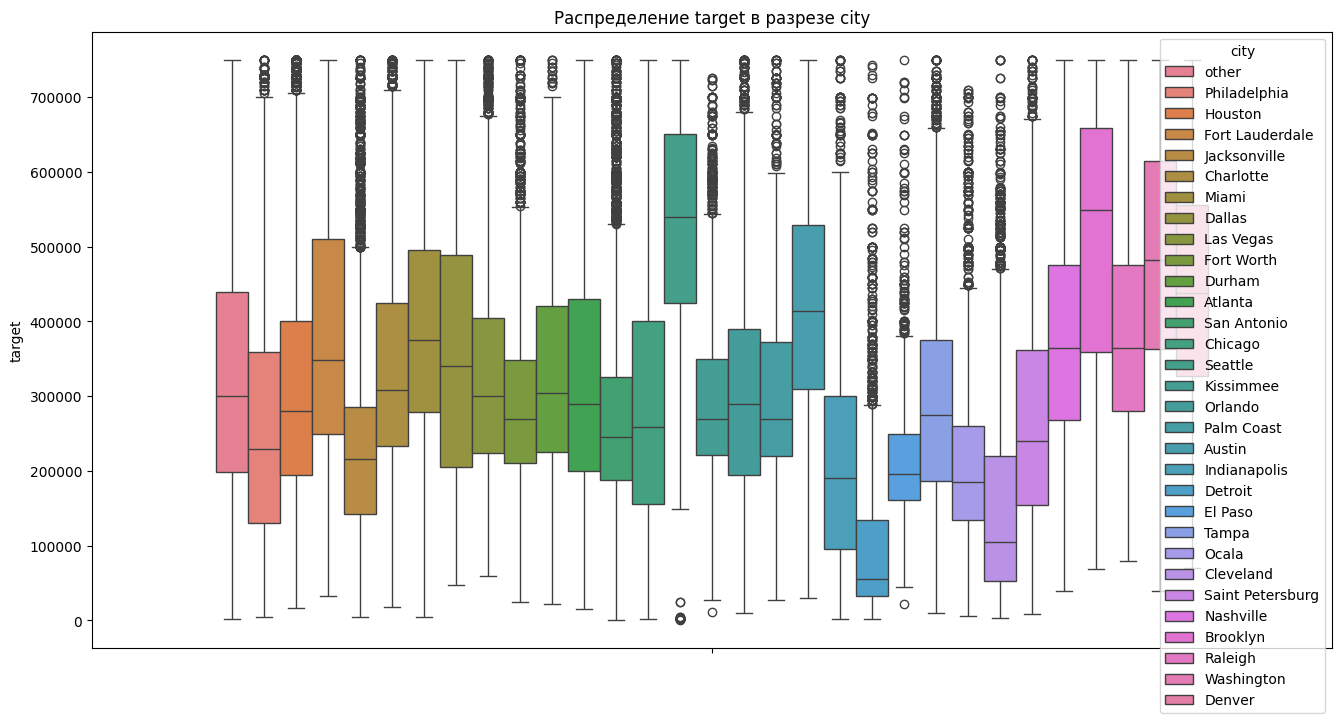

In [484]:
fig, axes = plt.subplots(1, 1, figsize = (16, 8))
sns.boxplot(df5, y='target', hue='city')
axes.set_title('Распределение target в разрезе city')

Text(0.5, 1.0, 'Распределение target в разрезе state')

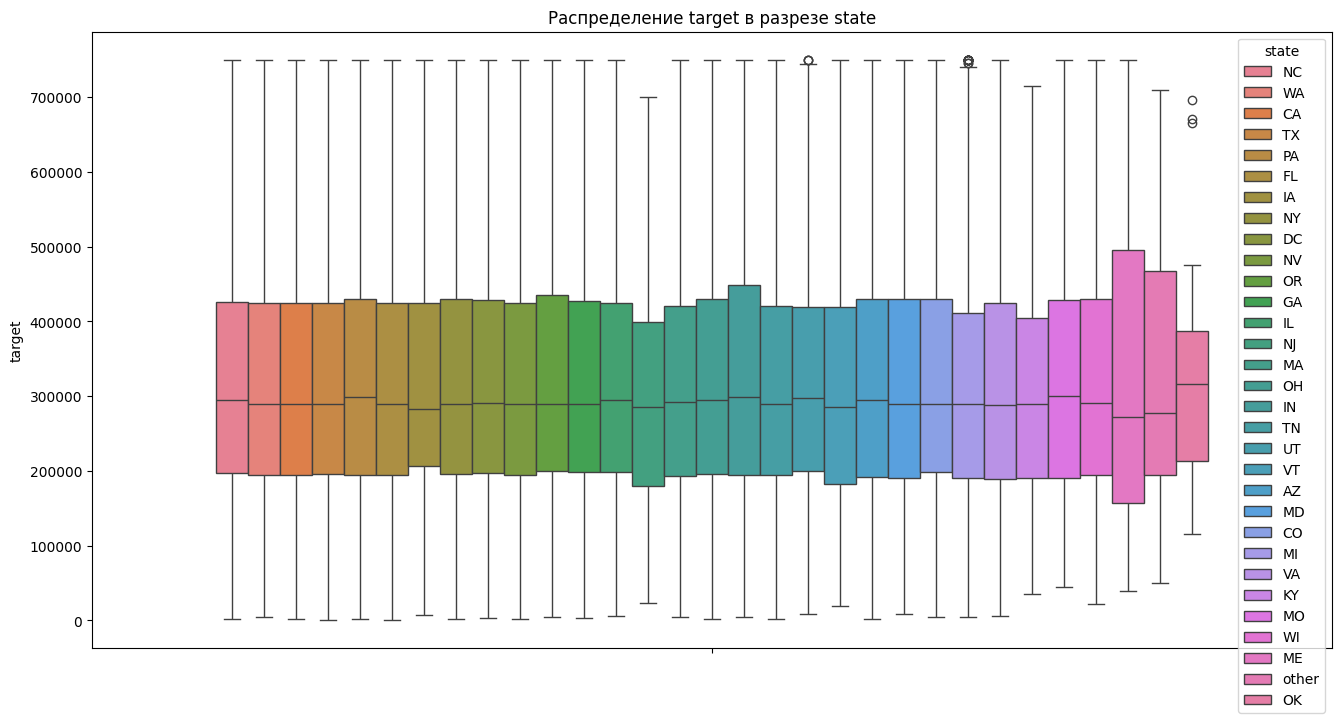

In [485]:
fig, axes = plt.subplots(1, 1, figsize = (16, 8))
sns.boxplot(df5, y='target', hue='state')
axes.set_title('Распределение target в разрезе state')

Text(0.5, 1.0, 'Распределение target в разрезе Type')

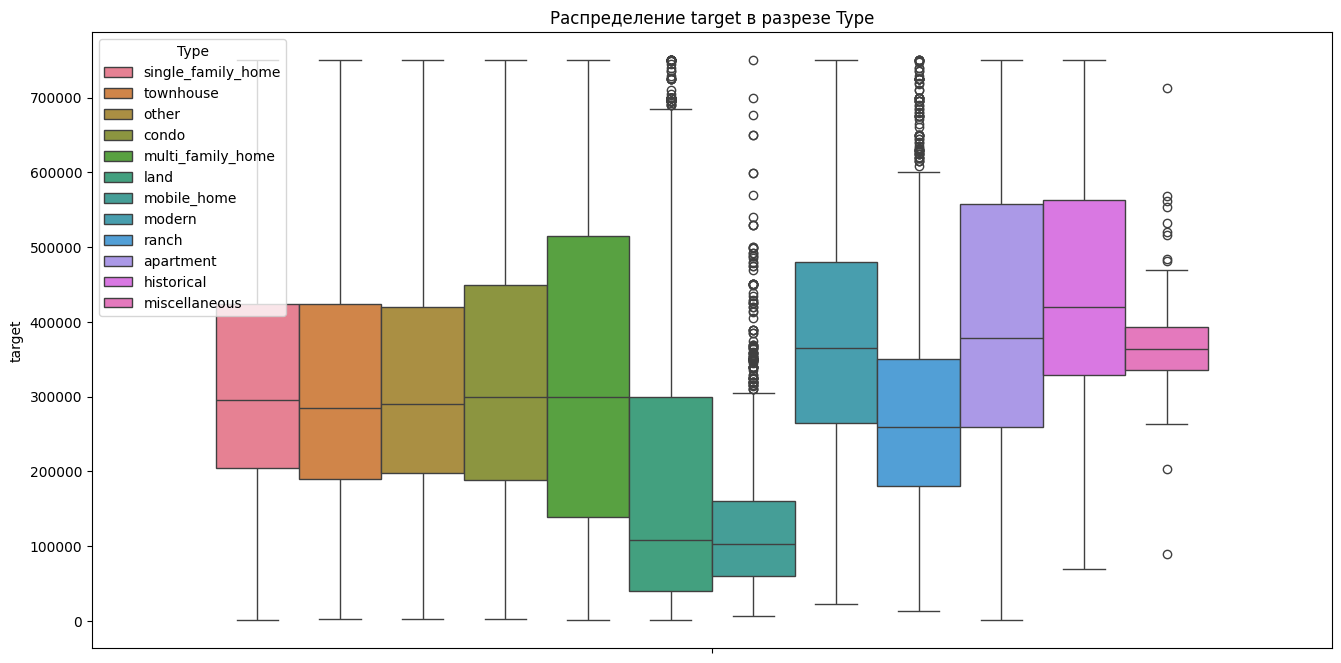

In [486]:
fig, axes = plt.subplots(1, 1, figsize = (16, 8))
sns.boxplot(df5, y='target', hue='Type')
axes.set_title('Распределение target в разрезе Type')

Text(0.5, 1.0, 'Распределение target в разрезе status')

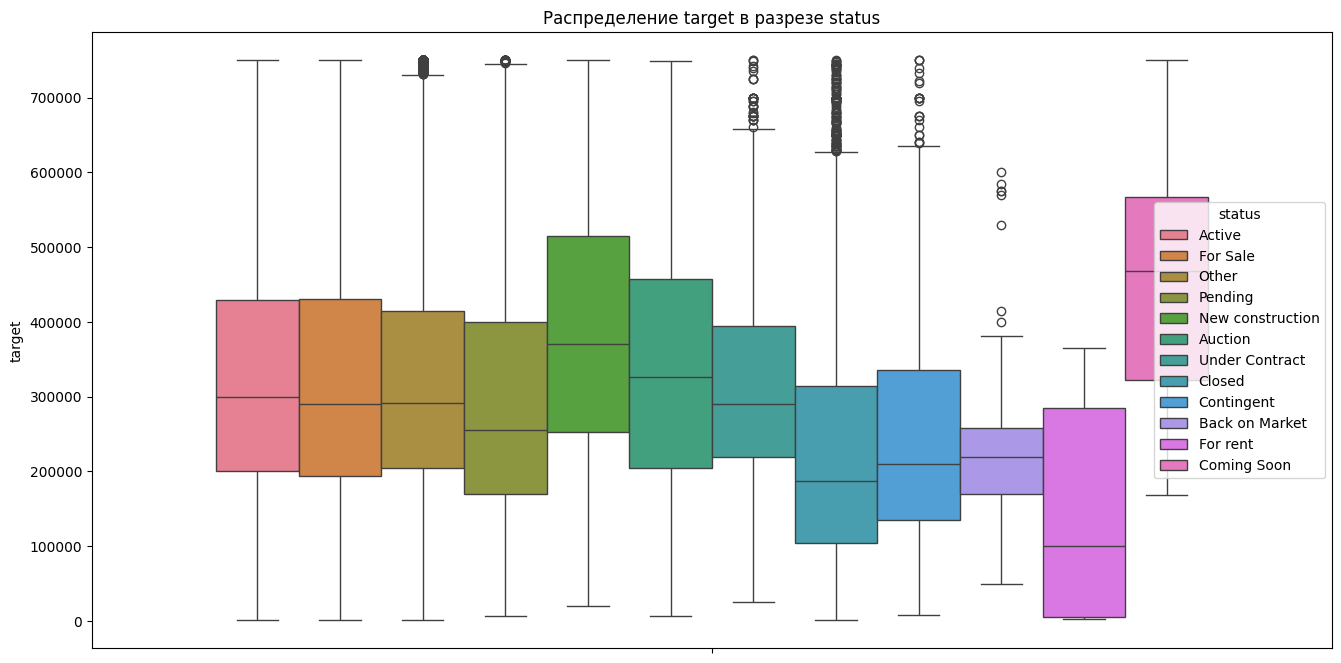

In [487]:
fig, axes = plt.subplots(1, 1, figsize = (16, 8))
sns.boxplot(df5, y='target', hue='status')
axes.set_title('Распределение target в разрезе status')

По графикам похоже, что все параметры, могут влиять на стоимость.

## Кодирование категориальных признаков

* status: Это бинарный признак (например, "продано"/"не продано"). Используем One-Hot Encoding, так как значений больше двух.
* Type: Здесь несколько категорий (например, "дом", "квартира", "таунхаус"). Так как нет явной иерархии между категориями, используем One-Hot Encoding.
* Heating, Cooling, Parking: Здесь ограниченное количество категорий. One-Hot Encoding подойдет, так как категорий немного, т.е. меньше 15.
* street, city, state, Year built: Эти признаки содержат много уникальных значений. LabelEncoder будет хорошими вариантами для уменьшения размерности.

In [488]:
# преобразуем признак Remodeled year в бинарный

df5['Remodeled year'] = df5['Remodeled year'].apply(lambda x: 1 if x == 'yes' else 0)


In [489]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 239616 entries, 0 to 262010
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   status                239616 non-null  object 
 1   street                239616 non-null  object 
 2   baths                 239616 non-null  object 
 3   city                  239616 non-null  object 
 4   sqft                  239616 non-null  float64
 5   state                 185402 non-null  object 
 6   target                239616 non-null  int64  
 7   pool_encoded          239616 non-null  bool   
 8   Type                  239616 non-null  object 
 9   bedsCleaned           239616 non-null  object 
 10  Year built            239616 non-null  float64
 11  Remodeled year        239616 non-null  int64  
 12  Heating               239616 non-null  object 
 13  Parking               239616 non-null  object 
 14  cooling_info_cleaned  239616 non-null  object 
dtypes: bo

In [490]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

# Преобразуем признак Year built в категориальный
df5['Year built'] = df5['Year built'].astype(str)

# Label Encoding
le = LabelEncoder()
for col in ['city', 'state', 'street', 'Year built','baths', 'bedsCleaned']:
     df5[col] = le.fit_transform(df5[col])
     
ohe_features = ['status', 'Type', 'Heating', 'cooling_info_cleaned', 'Parking']
df5 = pd.get_dummies(df5, columns=ohe_features, drop_first=False) 

## Масштабирование числовых признаков

In [491]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

#Выбираем числовые признаки для масштабирования
numerical_features = ['sqft']

# # MinMaxScaler (масштабирование от 0 до 1)
#scaler_minmax = MinMaxScaler()
#df5[numerical_features] = scaler_minmax.fit_transform(df5[numerical_features])
df5[numerical_features] = RobustScaler().fit_transform(df5[numerical_features])

## Отбор наиболее значимых признаков на основе анализа мультиколлинеарности.

Будем считать такими признаки, у которых корреляция больше 0.8

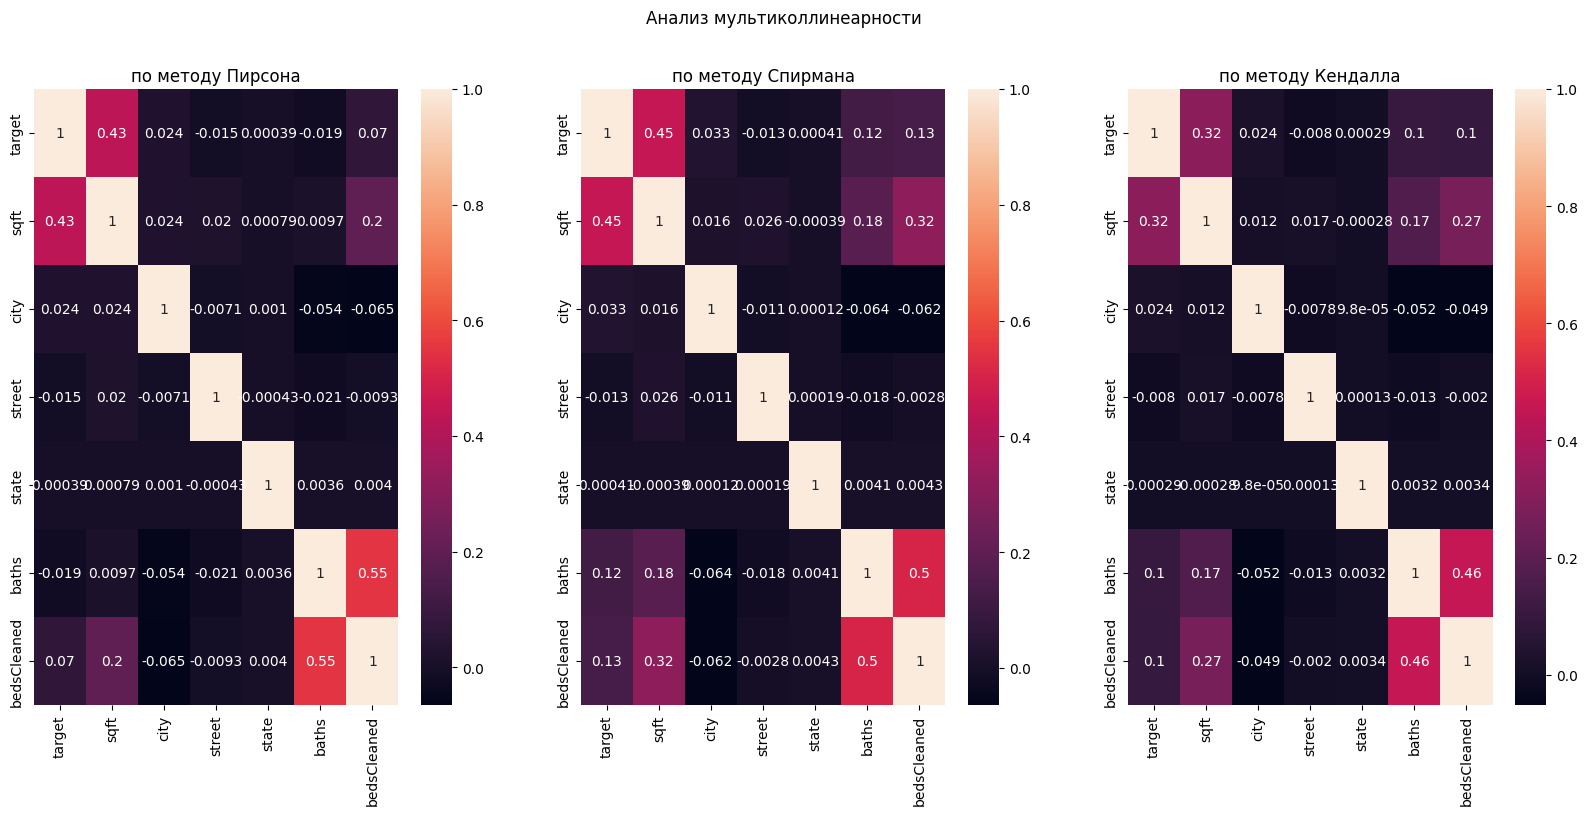

In [492]:
import matplotlib.pyplot as plt
import seaborn as sns

# Список признаков для анализа
selected_features = ['target', 'sqft', 'city', 'street', 'state', 'baths', 'bedsCleaned']

# Создаем подвыборку DataFrame, содержащую только выбранные признаки
data_subset = df5[selected_features]


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 8))
fig.suptitle('Анализ мультиколлинеарности')

# Вычисляем корреляцию только для выбранных признаков
cor_1 = sns.heatmap(data_subset.corr(method='pearson'), annot=True, ax=axes[0])
cor_1.set_title('по методу Пирсона')

cor_2 = sns.heatmap(data_subset.corr(method='spearman'), annot=True, ax=axes[1])
cor_2.set_title('по методу Спирмана')

cor_3 = sns.heatmap(data_subset.corr(method='kendall'), annot=True, ax=axes[2])
cor_3.set_title('по методу Кендалла')

plt.show()

Признаков, вызывающих мультиколлинеарность нет

## Подготовка данных

In [493]:
X = df5.drop(['target'], axis=1) #Матрица наблюдений
y = df5['target'] #Вектор правильных ответов

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=52)
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (191692, 56)
Test shape: (47924, 56)


Отберем 50 лучших признаков с помощью SelectKBest

In [495]:
#Отбор признаков с помощью SelectKBest
selector = feature_selection.SelectKBest(
    score_func = feature_selection.f_regression,
    k = 50
)
selector.fit(X_train, y_train)

# Получение индексов выбранных признаков
best_features = selector.get_feature_names_out()
X_train = X_train[best_features]
X_test = X_test[best_features]

print('Признаки, которые вошли в список отобранных:', best_features)

Признаки, которые вошли в список отобранных: ['street' 'baths' 'city' 'sqft' 'pool_encoded' 'bedsCleaned' 'Year built'
 'Remodeled year' 'status_Active' 'status_Auction' 'status_Back on Market'
 'status_Closed' 'status_Coming Soon' 'status_Contingent'
 'status_For Sale' 'status_For rent' 'status_New construction'
 'status_Pending' 'Type_apartment' 'Type_condo' 'Type_historical'
 'Type_land' 'Type_miscellaneous' 'Type_mobile_home' 'Type_modern'
 'Type_multi_family_home' 'Type_other' 'Type_ranch'
 'Type_single_family_home' 'Heating_electric' 'Heating_gas'
 'Heating_other' 'Heating_pump' 'cooling_info_cleaned_air'
 'cooling_info_cleaned_central' 'cooling_info_cleaned_gas'
 'cooling_info_cleaned_no data' 'cooling_info_cleaned_other' 'Parking_1'
 'Parking_2' 'Parking_3' 'Parking_4' 'Parking_5' 'Parking_6'
 'Parking_carport' 'Parking_driveway' 'Parking_garage' 'Parking_on'
 'Parking_other' 'Parking_parking']


In [496]:

scaler = preprocessing.StandardScaler()
scaler.fit(X_train)
#Нормализуем данные
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Построение модели

## Построение модели регрессии

Модели регрессии являются одним из основных типов задач машинного обучения. Они используются для предсказания числовых значений на основе входных данных. Например, в нашем случае, модель регрессии будет использоваться для предсказания цены дома на основе его характеристик (размер, количество спален, расположение и т.д.).

Существует несколько видов моделей регрессии:
    1. Линейная регрессия: это наиболее простой и распространенный вид регрессии. Он используется для предсказания значения на основе линейной зависимости между входными данными и результатом.
    2. Логистическая регрессия: используется для предсказания вероятности принадлежности к определенному классу. Она обычно используется для классификации двоичных или многоклассовых данных.
    3. Деревья решений: деревья решений используются для прогнозирования значений путем разделения данных на подмножества на основе входных признаков.


In [497]:
# Функция для вычисления метрик задач регрессии
def regression_metrics(y_train, y_train_predict, y_test, y_test_predict):

    print('train r2_score: {:.3f}'.format(metrics.r2_score(y_train, y_train_predict)))
    print('train mean_absolute_error: {:.3f}'.format(metrics.mean_absolute_error(y_train, y_train_predict)))

    print('test r2_score: {:.3f}'.format(metrics.r2_score(y_test, y_test_predict)))
    print('test mean_absolute_error: {:.3f}'.format(metrics.mean_absolute_error(y_test, y_test_predict)))
   

In [498]:
# Модель линейной регрессии
y_train_log = np.log1p(y_train)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train_log)

y_train_predict = np.expm1(lr.predict(X_train_scaled))
y_test_predict = np.expm1(lr.predict(X_test_scaled))

# Вывод метрик на экран
regression_metrics(y_train, y_train_predict, y_test, y_test_predict)

train r2_score: 0.161
train mean_absolute_error: 113636.291
test r2_score: 0.165
test mean_absolute_error: 113887.126


Линейная регрессия показала очень плохие результаты. Попробуем модели регрессии Lasso и Ridge.

Ridge

In [499]:
ridge = Ridge(alpha=1.0)  # Параметр alpha контролирует степень регуляризации
ridge.fit(X_train_scaled, y_train_log)

y_train_predict = np.expm1(ridge.predict(X_train_scaled))
y_test_predict = np.expm1(ridge.predict(X_test_scaled))

regression_metrics(y_train, y_train_predict, y_test, y_test_predict)

train r2_score: 0.161
train mean_absolute_error: 113636.279
test r2_score: 0.166
test mean_absolute_error: 113878.125


Lasso

In [500]:
lasso = Lasso()
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0]}
lasso_cv = GridSearchCV(lasso, param_grid, cv=5)
lasso_cv.fit(X_train_scaled, y_train_log)

# Лучшее значение alpha
print("Best alpha for Lasso:", lasso_cv.best_params_)

# Предсказания с использованием наилучшей модели
y_train_predict = np.expm1(lasso_cv.predict(X_train_scaled))
y_test_predict = np.expm1(lasso_cv.predict(X_test_scaled))

regression_metrics(y_train, y_train_predict, y_test, y_test_predict)

Best alpha for Lasso: {'alpha': 0.01}
train r2_score: 0.161
train mean_absolute_error: 114085.497
test r2_score: 0.165
test mean_absolute_error: 114311.588


Ни Lasso, ни Ridge существенно не улучшили ситуацию. Поэтому перейдём к другим моделям моделям.

Вернемся к предыдущим данным, не используя StandardScaler. Для регрессионных моделей это не требуется.

 ## RandomForestRegressor

In [501]:
# Создаем экземпляр модели RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=100, max_depth=10,random_state=52)

# Обучаем модель на обучающих данных
rf_regressor.fit(X_train, y_train)

# Предсказания на обучающих и тестовых данных
y_train_predict = rf_regressor.predict(X_train)
y_test_predict = rf_regressor.predict(X_test)

regression_metrics(y_train, y_train_predict, y_test, y_test_predict)

train r2_score: 0.461
train mean_absolute_error: 95696.852
test r2_score: 0.439
test mean_absolute_error: 97763.663


In [502]:
# Модель дерева решений

dt = DecisionTreeRegressor(random_state=52)
dt.fit(X_train, y_train)

y_train_predict = dt.predict(X_train)
y_test_predict = dt.predict(X_test)

# Вывод метрик на экран
regression_metrics(y_train, y_train_predict, y_test, y_test_predict)

train r2_score: 1.000
train mean_absolute_error: 12.593
test r2_score: 0.229
test mean_absolute_error: 97120.699


Вывод: Такие метрики указывают на явное переобучение. Модель практически идеально предсказывает значения на обучающей выборке (r2_score = 1.000), но ее качество значительно снижается на тестовой выборке (r2_score = 0.220). Это значит, что модель "запомнила" обучающие данные и не может обобщать на новые, невидимые ранее данные.

Посмотрим на то, как с этой задачей справится дерево решений, параметры подберем с помощью RandomizedSearchCV

In [503]:
#Модель
dt_model = DecisionTreeRegressor(random_state=52)
#Сетка параметров
param_grid = {
    'max_depth': np.arange(1, 100, 10),
    'min_samples_leaf': np.arange(1, 20, 4),
}
#Подбор гиперпараметров
grid_dt = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=param_grid,
    cv=5,
    n_iter=10,
    verbose=2,
    n_jobs=-1
)
#Обучаем модель
grid_dt.fit(X_train, y_train)
print(f'best params: {grid_dt.best_params_}')
dt_model = grid_dt.best_estimator_

y_train_predict = dt_model.predict(X_train)
y_test_predict = dt_model.predict(X_test)

# Вывод метрик на экран
regression_metrics(y_train, y_train_predict, y_test, y_test_predict)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
best params: {'min_samples_leaf': 17, 'max_depth': 81}
train r2_score: 0.610
train mean_absolute_error: 76562.047
test r2_score: 0.462
test mean_absolute_error: 90091.539


Дерево решений после подбора гиперпараметров справляется явно лучше, чем линейная регрессия

In [504]:
#Модель
rf_model = RandomForestRegressor(random_state=52)
#Сетка параметров
param_grid = {
    'n_estimators': np.arange(100, 501, 100),
    'max_depth': np.arange(1, 100, 10),
    'min_samples_leaf': np.arange(1, 20, 4)
}
#Подбор гиперпараметров
grid_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    cv=2,
    n_iter=3,
    verbose=2,
    n_jobs=-1
)
#Обучаем модель
grid_rf.fit(X_train, y_train)
print(f'best params: {grid_rf.best_params_}')
rf_model = grid_rf.best_estimator_

y_train_predict = rf_model.predict(X_train)
y_test_predict = rf_model.predict(X_test)
# Вывод метрик на экран
regression_metrics(y_train, y_train_predict, y_test, y_test_predict)

Fitting 2 folds for each of 3 candidates, totalling 6 fits
best params: {'n_estimators': 400, 'min_samples_leaf': 17, 'max_depth': 31}
train r2_score: 0.631
train mean_absolute_error: 75409.347
test r2_score: 0.546
test mean_absolute_error: 84049.307


Еще немного улучшились показатели

In [505]:
def optuna_rf(trial):
  # задаем пространства поиска гиперпараметров
  n_estimators = trial.suggest_int('n_estimators', 50, 500)
  max_depth = trial.suggest_int('max_depth', 3, 100)
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 20,1)
  max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

  # создаем модель
  model = RandomForestRegressor(n_estimators=n_estimators,
                                          max_depth=max_depth,
                                          min_samples_leaf=min_samples_leaf,
                                          max_features = max_features,
                                          n_jobs=-1,
                                          random_state=52)
  # обучаем модель
  model.fit(X_train, y_train)
  
  score = metrics.mean_absolute_error(y_train, model.predict(X_train))
  

  return score
  


In [506]:
study = optuna.create_study(study_name="RandomForestRegressor")
# ищем лучшую комбинацию гиперпараметров n_trials раз
study.optimize(optuna_rf, n_trials=30)

[I 2026-06-30 12:05:01,487] A new study created in memory with name: RandomForestRegressor
C:\Users\Анечка\AppData\Local\Temp\ipykernel_31136\2112780792.py:5: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 20,1)
[I 2026-06-30 12:07:04,163] Trial 0 finished with value: 72950.59145337358 and parameters: {'n_estimators': 220, 'max_depth': 52, 'min_samples_leaf': 14, 'max_features': None}. Best is trial 0 with value: 72950.59145337358.
C:\Users\Анечка\AppData\Local\Temp\ipykernel_31136\2112780792.py:5: FutureWarning: suggest_int() got {'step'} as 

In [507]:
#рассчитаем точность для тестовой выборки
best_model = RandomForestRegressor(**study.best_params,random_state=52 )
best_model.fit(X_train, y_train)
y_train_predict = best_model.predict(X_train)

y_test_predict = best_model.predict(X_test)
regression_metrics(y_train, y_train_predict, y_test, y_test_predict)

train r2_score: 0.902
train mean_absolute_error: 36372.957
test r2_score: 0.601
test mean_absolute_error: 75562.866


In [508]:

gb = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42
)
gb.fit(X_train, y_train)

y_train_predict = gb.predict(X_train)
y_test_predict = gb.predict(X_test)

# Вывод метрик на экран
regression_metrics(y_train, y_train_predict, y_test, y_test_predict)

train r2_score: 0.554
train mean_absolute_error: 84941.688
test r2_score: 0.537
test mean_absolute_error: 86628.045


In [509]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100,400],
    'learning_rate': [0.01],
    'max_depth': [3,4,5,10],
}

model = GradientBoostingRegressor(random_state=52)

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, scoring='r2')

grid_search.fit(X_train, y_train)

best_grboostingmodel = grid_search.best_estimator_

y_train_predict = best_grboostingmodel.predict(X_train)
y_test_predict = best_grboostingmodel.predict(X_test)
regression_metrics(y_train, y_train_predict, y_test, y_test_predict)

train r2_score: 0.594
train mean_absolute_error: 81338.931
test r2_score: 0.541
test mean_absolute_error: 86339.342


In [510]:
from xgboost import XGBRegressor
model_xgb = XGBRegressor(random_state=52,n_estimators=300, max_depth=5)
model_xgb.fit(X_train_scaled,y_train)
y_test_predict = model_xgb.predict(X_test)
y_train_predict = model_xgb.predict(X_train)
regression_metrics(y_train, y_train_predict, y_test, y_test_predict)

train r2_score: 0.161
train mean_absolute_error: 123376.329
test r2_score: 0.165
test mean_absolute_error: 123546.343


In [511]:
xgb_model  = XGBRegressor(
    learning_rate=0.21, # темп обучения
    max_depth=10, # Максимальная глубина каждого дерева
    min_child_weight=3, # Минимальное количество объектов в листовой вершине
    gamma=0.0021, # Минимальное уменьшение функции потерь, необходимое для разделения дерева
    colsample_bytree=0.68, # Доля признаков, используемых при построении каждого дерева
    subsample=0.704, # Доля обучающих данных, используемых для обучения каждого дерева
    random_state=52 # генератор случайных чисел
)
#Обучаем модель
xgb_model.fit(X_train, y_train)
y_test_predict = xgb_model.predict(X_test)
y_train_predict = xgb_model.predict(X_train)
regression_metrics(y_train, y_train_predict, y_test, y_test_predict)

train r2_score: 0.707
train mean_absolute_error: 66988.541
test r2_score: 0.588
test mean_absolute_error: 79393.719


In [512]:
from sklearn.model_selection import cross_val_score, RepeatedKFold
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 500, 1500)
    max_depth = trial.suggest_int('max_depth', 3, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 5)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 3)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    
    # Определяем модель
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=52,
        n_jobs=-1
    )
    
    # Испоьзуем кросс валидацию
    cv = RepeatedKFold(n_splits=3, n_repeats=2, random_state=52)
    
    score = cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

# Получаем лучшие параметры
best_params = study.best_params
print("Best parameters:", best_params)


best_model = RandomForestRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    random_state=52,
    n_jobs=-1
)
best_model.fit(X_train, y_train)

#
y_train_predict = best_model.predict(X_train)
y_test_predict = best_model.predict(X_test)

regression_metrics(y_train, y_train_predict, y_test, y_test_predict)

[I 2026-06-30 17:05:18,556] A new study created in memory with name: no-name-e8d3e1f0-2927-4674-b5fb-985f9acef710


[I 2026-06-30 17:11:17,268] Trial 0 finished with value: -87335.57170997035 and parameters: {'n_estimators': 607, 'max_depth': 28, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: -87335.57170997035.
[I 2026-06-30 17:12:35,114] Trial 1 finished with value: -118491.34155892592 and parameters: {'n_estimators': 648, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: -87335.57170997035.
[I 2026-06-30 18:22:42,222] Trial 2 finished with value: -101260.63371915357 and parameters: {'n_estimators': 792, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: -87335.57170997035.
[I 2026-06-30 18:24:41,827] Trial 3 finished with value: -104683.51281244383 and parameters: {'n_estimators': 501, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: -87335.5717099

Best parameters: {'n_estimators': 1353, 'max_depth': 33, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
train r2_score: 0.727
train mean_absolute_error: 66259.699
test r2_score: 0.548
test mean_absolute_error: 85327.959


In [3]:
data = {'Metric': ['Train R2', 'Test R2', 'Train MAE', 'Test MAE'],
        'LinearRegression': [0.161, 0.165, 113636, 113887],
        'RandomForestRegressor': [0.727, 0.548, 66260, 85328],
        'GradientBoostingRegressor': [0.554, 0.537, 84941, 86628],
        'XGBRegressor':[0.707, 0.588, 66988, 79393 ]}

df_metric = pd.DataFrame(data)
df_metric.head(6)

,Metric,LinearRegression,RandomForestRegressor,GradientBoostingRegressor,XGBRegressor
0,Train R2,0.161,0.727,0.554,0.707
1,Test R2,0.165,0.548,0.537,0.588
2,Train MAE,113636.000,66260.000,84941.000,66988.000
3,Test MAE,113887.000,85328.000,86628.000,79393.000


## Выводы
Были выбраны несколько моделей регрессии для сравнения их производительности: Линейная регрессия, Регрессия дерева решений, Регрессия случайного леса и Градиентный бустинг. Гиперпараметры моделей были оптимизированы с помощью библиотеки Optuna и GridSearchCV для достижения наилучших результатов.

На основе этих результатов, RandomForestRegressor кажется наилучшей моделью, так как она имеет наименьший показатель ошибок MAE, вместе с высоким коэффициентом детерминации R2 (0.7) на тестовых данных. Однако, стоит учесть переобучение случайного леса, так как разрыв между показателями на тренировочных и тестовых наборах является существенным.